In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#  Environment Setup & Dependencies

Run the cell below to install all the necessary packages for this analysis. These packages cover:
- **Network & Graph Analysis:** `igraph`, `cairocffi`, and `pycairo` (includes a pre-built Windows wheel if applicable).
- **Image Processing:** `pillow` and `Image`.
- **Statistical Modeling & Curve Fitting:** `distfit`, `powerlaw`, `fitter`, `scipy`, and `mpmath`.
- **Data Visualization:** `seaborn`.


In [32]:
# If running for the first time:
# %pip install -r requirements.txt

In [33]:
from pandas.tseries.offsets import QuarterBegin
import igraph
import pandas as pd
import numpy as np
from numpy import median, inf
from datetime import datetime
import time
from pytz import timezone
import pytz
from distfit import distfit
import matplotlib.pyplot as plt
import itertools
from pandas.core.frame import dict_to_mgr
import statistics
import powerlaw
import seaborn as sns
from fitter import Fitter, get_common_distributions, get_distributions

In [34]:
# Import all the custom functions from utils.py
from utils import (
    csv_to_df, load_class_contacts, 
    normalize_class_notes, process_grade_contacts, 
    reindex, get_student_class_counts, plot_grade_pies,
    find_inactive_tags, known_class_contacts,
    build_contact_graph, georgian_to_unix
)

### Load and Merge Class Contact Data
In the cell below, we load the raw RFID card mapping data (`df_rfid`). We then use the custom [load_class_contacts]function from our [utils.py] module to automate the data pipeline for the 5th, 6th, and 7th graders. 

This helper function automatically:
1. Loads the class-specific CSV files into dataframes.
2. Renames the `'Tag ID'` column to `'Mifare ID'` to prepare for a relational join.
3. Automatically drops any empty tracking columns (like `Unnamed: 4`) if they exist in the raw file.
4. Left-merges the class data against our main RFID catalog to attach specific Tag IDs and Types to every student record.
5. Fills any missing or corrupted Class/Note rows with `'unknown'` to prevent NaN errors in downstream analysis.

In [35]:
# 1. Load the main RFID mapping dataframe
df_rfid = csv_to_df('data/tagid-mifareid.csv')

# 2. Use your load_class_contacts function to automatically load, rename, merge, and clean!
df_class7 = load_class_contacts(
    'data/7tagid.csv', 
    df_rfid=df_rfid, 
    drop_unnamed=False
)

df_class6 = load_class_contacts(
    'data/6tagid.csv', 
    df_rfid=df_rfid, 
    drop_unnamed=True  # Automatically drops 'Unnamed: 4'
)

df_class5 = load_class_contacts(
    'data/5tagid.csv', 
    df_rfid=df_rfid, 
    drop_unnamed=True  # Automatically drops 'Unnamed: 4'
)

# Display the 5th graders dataframe as an example
df_class5


,Mifare ID,Student ID,Class,Notes,Tag ID,Type
0,3924627766,908,5-C,Student,308462,Card
1,3926890310,317,5-A,Student,286318,Card
2,2085149494,512,5-B,Student,309402,Card
3,2089797334,449,5-C,Student,289036,Card
4,3929522966,NaN,unknown,Student,309672,Card
...,...,...,...,...,...,...
191,3917101894,440,5-E,Student,307791,Card
192,2082994454,415,5-E,Student,287228,Card
193,3919165222,511,5-A,Student,309668,Card
194,3914721222,862,5-F,Student,307870,Card


### Data Cleaning & Normalization
In this step, we filter and normalize the classification categories (`Notes`) to ensure our labeling is consistent before conducting network analysis. We use efficient, vectorized boolean masking instead of row-by-row iteration for significantly faster execution.

- **5th Graders:** Because of a mapping error in the source files, some students were accidentally recorded as `Stationary` or `unknown`. We run a custom algorithm ([normalize_class_notes] to detect valid Student IDs in these rows and forcibly correct their labels back to `Student`.
- **7th Graders:** A logistical anomaly caused several 7th-grade students to be marked as `Nöbetçi` (on-duty tracking). We manually mask and overwrite these specific rows back to a standard `Student` label.
- **Deduplication:** Finally, we drop any duplicate readings and reset the DataFrame indexes to maintain a clean, unbroken tabular structure for further processing. 


In [36]:
# Clean the grade data using the utility function (which already drops duplicates and reindexes!)
df_class5 = normalize_class_notes(df_class5)
df_class6 = normalize_class_notes(df_class6)
df_class7 = normalize_class_notes(df_class7)


# Clean the 7th grade data (handling 'Nöbetçi' -> 'Student')
mask_nobetci = df_class7['Notes'] == 'Nöbetçi'
df_class7.loc[mask_nobetci, 'Notes'] = 'Student'
df_class7.drop_duplicates(keep='first', inplace=True)
df_class7.reset_index(drop=True, inplace=True)

# Preview
df_class5

,Mifare ID,Student ID,Class,Notes,Tag ID,Type
0,3924627766,908,5-C,Student,308462,Card
1,3926890310,317,5-A,Student,286318,Card
2,2085149494,512,5-B,Student,309402,Card
3,2089797334,449,5-C,Student,289036,Card
4,3929522966,NaN,unknown,Student,309672,Card
...,...,...,...,...,...,...
188,3928461158,Stat. 5-A,unknown,Stationary,308428,Card
189,3913024358,Stat 5-E,unknown,Stationary,309530,Card
190,2081823686,Stat. 5-F,unknown,Stationary,310079,Card
191,3919165222,511,5-A,Student,309668,Card


### Tag & Role Breakdown per Grade
Below, we print a summary of the total number of unique RFID tags deployed in each grade, along with the frequency distribution of role labels (`Notes` column). This gives us a quick overview of how many students, stationary sensors, and other tag types were active in each deployment.


In [37]:
# Build a compact summary table across all grades
summary_rows = []
grades = {'5th': df_class5, '6th': df_class6, '7th': df_class7}

for grade_name, df in grades.items():
    role_counts = df['Notes'].value_counts().to_dict()
    role_counts['Grade'] = grade_name
    role_counts['Total Tags'] = df['Tag ID'].nunique()
    summary_rows.append(role_counts)

tag_summary = pd.DataFrame(summary_rows).fillna(0).astype({'Total Tags': int})
tag_summary = tag_summary.set_index('Grade')

# Reorder so Total Tags comes first
cols = ['Total Tags'] + [c for c in tag_summary.columns if c != 'Total Tags']
tag_summary = tag_summary[cols]

tag_summary

,Total Tags,Student,Stationary,Employee,Teacher
Grade,,,,,
5th,193,185,8,0.00000,0.00000
6th,169,162,7,0.00000,0.00000
7th,183,169,8,4.00000,2.00000


### Aggregate Student Class Counts
In the following cell, we calculate the total student population per class for the 5th, 6th, and 7th graders. 

In [38]:
# Apply our efficient function to all three grades
grade5_populations = get_student_class_counts(df_class5)
grade6_populations = get_student_class_counts(df_class6)
grade7_populations = get_student_class_counts(df_class7)

# Preview the results for 7th graders
grade7_populations

,Class,Count
0,7-A,29
1,7-D,28
2,7-B,27
3,7-C,27
4,7-E,27
5,7-F,18
6,unknown,13


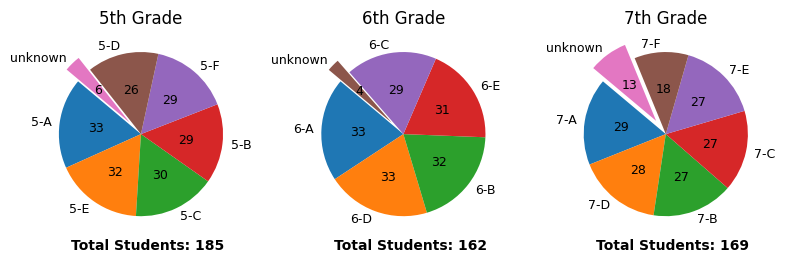

In [39]:
plot_grade_pies(
    populations=[grade5_populations, grade6_populations, grade7_populations],
    titles=['5th Grade', '6th Grade', '7th Grade'],
    save_path='figures/gradepiestatistics.png',
)

### Load & Preprocess Contact Data
We load two raw contact log CSV files (`all1.csv`, `all2.csv`), drop any incomplete rows, and concatenate them into a single unified DataFrame.

Timestamps arrive in milliseconds from the hardware logger; we convert them to **seconds** and store them in new columns (`begin_time_s`, `end_time_s`). Columns that provide no analytical value (`baseid`, `begin_time`, `end_time`, `upload_time`) are removed in a single call to keep the DataFrame lean. Finally, the index is reset to produce a clean, contiguous row numbering.


In [40]:
# Load both contact files and drop incomplete rows on read
contacts_raw = pd.concat(
    [csv_to_df('data/all1.csv').dropna(),
     csv_to_df('data/all2.csv').dropna()],
    ignore_index=True
)

# Convert millisecond timestamps to seconds
contacts_raw['begin_time_s'] = contacts_raw['begin_time'] / 1000
contacts_raw['end_time_s']   = contacts_raw['end_time']   / 1000

# Drop columns not needed for analysis
df_contacts = contacts_raw.drop(
    columns=['baseid', 'begin_time', 'end_time', 'upload_time']
)
df_contacts = reindex(df_contacts)

df_contacts

,tagid,touched_tagid,min_distance,duration,begin_time_s,end_time_s
0,311761,284975,1.10000,31,1678876472.00000,1678876503.00000
1,311761,284975,0.10000,129,1678876739.00000,1678876868.00000
2,311761,285928,0.30000,9,1678876592.00000,1678876601.00000
3,311761,289041,1.10000,3,1678876501.00000,1678876504.00000
4,311761,289041,0.20000,130,1678876739.00000,1678876869.00000
...,...,...,...,...,...,...
633122,310331,309781,1.30000,11,1678876936.00000,1678876947.00000
633123,310331,309781,0.30000,14,1678876965.00000,1678876979.00000
633124,310331,311861,0.80000,7,1678876936.00000,1678876943.00000
633125,310331,322929,0.20000,11,1678876965.00000,1678876976.00000


### Raw Data Contains Residual Contacts from Previous Deployments

The RFID cards are **not wiped between deployments** — contacts recorded on earlier school days remain stored on the cards and are uploaded alongside the current day's data. As a result, the raw CSV files (`all1.csv`, `all2.csv`) contain contacts spanning **19 different dates** from November 2022 to April 2023.

The table below shows exactly how many contacts belong to each date, making it clear which rows are "residual history" and which are the target measurement days.


In [41]:
# Convert begin timestamps to calendar dates
contacts_raw['date'] = pd.to_datetime(
    contacts_raw['begin_time_s'], unit='s'
).dt.date

# Deployment dates we actually analyse, with their school-hour windows
TARGET_DATES = {
    '2023-03-15': ('7th Grade deployment', '09:00:00', '15:00:00'),
    '2023-03-20': ('6th Grade deployment', '09:00:00', '15:00:00'),
    '2023-03-22': ('5th Grade deployment', '09:00:00', '15:00:00'),
}

# Build per-date counts
date_summary = (
    contacts_raw.groupby('date')
    .size()
    .reset_index(name='Raw Contacts')
)
date_summary['date'] = date_summary['date'].astype(str)

total = len(contacts_raw)

print(f"\n{'Date':<14} {'All Contacts':>13}  {'% Total':>8}  {'In-Window':>10}  {'Pre-Window':>10}  {'Post-Window':>12}  Label")
print("-" * 100)

total_target   = 0
total_residual = 0

for _, row in date_summary.iterrows():
    d    = row['date']
    n    = row['Raw Contacts']
    pct  = n / total * 100

    if d in TARGET_DATES:
        label, t_start, t_end = TARGET_DATES[d]
        day_start = georgian_to_unix(f"{d} {t_start}")
        day_end   = georgian_to_unix(f"{d} {t_end}")

        day_df   = contacts_raw[contacts_raw['date'].astype(str) == d]
        in_win   = day_df[day_df['begin_time_s'].between(day_start, day_end)]
        pre_win  = day_df[day_df['begin_time_s'] < day_start]
        post_win = day_df[day_df['begin_time_s'] > day_end]

        print(f"{d:<14} {n:>13,}  {pct:>7.1f}%  {len(in_win):>10,}  {len(pre_win):>10,}  {len(post_win):>12,}  {label} ◄")
        total_target += n
    else:
        label = 'Residual (previous deployment)'
        print(f"{d:<14} {n:>13,}  {pct:>7.1f}%  {'—':>10}  {'—':>10}  {'—':>12}  {label}")
        total_residual += n

print("-" * 100)
print(f"{'TARGET dates':<14} {total_target:>13,}  {100*total_target/total:>7.1f}%")
print(f"{'Residual':<14} {total_residual:>13,}  {100*total_residual/total:>7.1f}%")
print(f"{'TOTAL':<14} {total:>13,}  {'100.0%':>8}")
print(f"\n  Note: Pre-Window contacts are real social interactions recorded while students")
print(f"  arrived and gathered before school hours (typically 06:00–08:59).")



Date            All Contacts   % Total   In-Window  Pre-Window   Post-Window  Label
----------------------------------------------------------------------------------------------------
2022-11-14            15,222      2.4%           —           —             —  Residual (previous deployment)
2022-11-29                 2      0.0%           —           —             —  Residual (previous deployment)
2022-12-18             7,613      1.2%           —           —             —  Residual (previous deployment)
2022-12-19            89,233     14.1%           —           —             —  Residual (previous deployment)
2022-12-20            27,393      4.3%           —           —             —  Residual (previous deployment)
2022-12-21             1,181      0.2%           —           —             —  Residual (previous deployment)
2022-12-30                 4      0.0%           —           —             —  Residual (previous deployment)
2023-01-10             6,688      1.1%           — 

### Process & Deduplicate Contact Events per Grade
Using the [process_grade_contacts()] pipeline from [utils.py], we load, filter, enrich, and deduplicate all RFID contact events for each grade in a single function call. The pipeline performs the following steps internally:

1. **Load class data** — reads the grade-specific tag CSV and merges it with the RFID mapping.
2. **Time-window filter** — keeps only contacts recorded during school hours (09:00–15:00) on each grade's deployment day.
3. **Quality filter** — removes zero-duration contacts, zero-distance readings, and sensor noise above 3600 cm.
4. **Class enrichment** — attaches class and role metadata to both the initiating (`tagid`) and receiving (`touched_tagid`) tag.
5. **Exact deduplication** — eliminates fully identical rows using a direction-agnostic tag pair key.
6. **Near-duplicate removal** — applies a 4-pass, 3-second tolerance window to remove sensor double-counts. 4-pass here means the data is scanned four times (checking different combinations of start and end times) to catch all duplicate variations, while the 3-second tolerance groups redundant sensor pings that occur within 3 seconds of each other into a single continuous interaction.

| Grade | Deployment Date | Special Handling |
|-------|----------------|------------------|
| 7th   | 2023-03-15     | `Nöbetçi` → `Student` |
| 6th   | 2023-03-20     | Drop extra unnamed column |
| 5th   | 2023-03-22     | Drop unnamed + normalize mislabeled notes |

Because RFID contacts are reported independently by both participating tags, single physical interactions are frequently logged as two distinct database rows with slightly offset timestamps. To resolve this, after performing exact deduplication, the 4-pass near-duplicate removal systematically merges records involving the same student pair where start times, end times, and contact durations differ by ≤3 seconds (the nominal hardware beacon cycle):

| Pass | Strategy | Catches |
|------|----------|---------|
| 1 | Similar begin_time + similar duration | Bulk of double-counts |
| 2 | Same duration, similar begin_time | Safety net (rare edge cases) |
| 3 | Similar end_time + similar duration | Pairs where begin_times drifted >3s but end_times stayed close |
| 4 | Re-sorted by end_time, check begin_time | Final sweep for sort-order edge cases |

This pipeline consistently eliminated 21–23% of the raw contact rows across all three deployments, ensuring each physical interaction is counted only once.

**Near-Duplicate Removal Summary**

| Stage | 5th Grade | 6th Grade | 7th Grade |
|-------|-----------|-----------|-----------|
| After quality filters + exact dedup | 152,276 | 106,220 | 123,921 |
| Pass 1 Removed | 34,662 | 24,426 | 26,703 |
| Pass 2 Removed | 0 | 0 | 0 |
| Pass 3 Removed | 468 | 268 | 319 |
| Pass 4 Removed | 0 | 0 | 0 |
| **Total near-duplicates removed** | **35,130 (23.1%)** | **24,694 (23.2%)** | **27,022 (21.8%)** |


In [42]:
df7 = process_grade_contacts(
    df_contacts, 'data/7tagid.csv', df_rfid,
    date='2023-03-15',
    extra_note_fixes={'Nöbetçi': 'Student'},
)

df6 = process_grade_contacts(
    df_contacts, 'data/6tagid.csv', df_rfid,
    date='2023-03-20',      
    drop_unnamed=True,
)

df5 = process_grade_contacts(
    df_contacts, 'data/5tagid.csv', df_rfid,
    date='2023-03-22',      
    drop_unnamed=True,
    normalize=True,
)

# example
df7

,tagid,touched_tagid,min_distance,duration,begin_time_s,end_time_s,Class_x,Notes_x,Class_y,Notes_y,tag_min,tag_max
0,289355,323839,1.10000,2,1678860927.00000,1678860929.00000,7-E,Student,7-D,Student,289355,323839
1,309498,286966,0.80000,9,1678860920.00000,1678860929.00000,7-D,Student,7-D,Student,286966,309498
2,307788,309498,0.80000,18,1678860913.00000,1678860931.00000,7-D,Student,7-D,Student,307788,309498
3,287589,308428,1.20000,2,1678860938.00000,1678860940.00000,7-D,Student,7-D,Student,287589,308428
4,307233,289059,1.20000,2,1678860941.00000,1678860943.00000,7-D,Student,7-D,Student,289059,307233
...,...,...,...,...,...,...,...,...,...,...,...,...
96894,311022,307961,0.40000,12,1678881585.00000,1678881597.00000,7-A,Student,7-A,Student,307961,311022
96895,311684,311022,0.60000,12,1678881585.00000,1678881597.00000,7-A,Student,7-A,Student,311022,311684
96896,311684,286177,0.90000,13,1678881584.00000,1678881597.00000,7-A,Student,7-A,Student,286177,311684
96897,307961,311022,0.20000,1445,1678880152.00000,1678881597.00000,7-A,Student,7-A,Student,307961,311022


### Student-Only Contact Events
We filter the contact DataFrames to retain only student-to-student interactions by excluding any row where either participant is a non-student tag (stationary sensor, teacher, or staff). The `min_distance` column is also dropped as it is not required for network analysis.


In [43]:
# Labels to exclude from both sides of a contact
NON_STUDENT = ['Stationary', 'Teacher', 'Employee']

def student_only_contacts(df):
    """Keep only rows where both tagid and touched_tagid belong to students."""
    mask = (
        df['Notes_x'].isin(NON_STUDENT) |
        df['Notes_y'].isin(NON_STUDENT)
    )
    return df[~mask].drop(columns=['min_distance'], errors='ignore')

student_contacts5 = student_only_contacts(df5)
student_contacts6 = student_only_contacts(df6)
student_contacts7 = student_only_contacts(df7)

# example 
student_contacts7

,tagid,touched_tagid,duration,begin_time_s,end_time_s,Class_x,Notes_x,Class_y,Notes_y,tag_min,tag_max
0,289355,323839,2,1678860927.00000,1678860929.00000,7-E,Student,7-D,Student,289355,323839
1,309498,286966,9,1678860920.00000,1678860929.00000,7-D,Student,7-D,Student,286966,309498
2,307788,309498,18,1678860913.00000,1678860931.00000,7-D,Student,7-D,Student,307788,309498
3,287589,308428,2,1678860938.00000,1678860940.00000,7-D,Student,7-D,Student,287589,308428
4,307233,289059,2,1678860941.00000,1678860943.00000,7-D,Student,7-D,Student,289059,307233
...,...,...,...,...,...,...,...,...,...,...,...
96894,311022,307961,12,1678881585.00000,1678881597.00000,7-A,Student,7-A,Student,307961,311022
96895,311684,311022,12,1678881585.00000,1678881597.00000,7-A,Student,7-A,Student,311022,311684
96896,311684,286177,13,1678881584.00000,1678881597.00000,7-A,Student,7-A,Student,286177,311684
96897,307961,311022,1445,1678880152.00000,1678881597.00000,7-A,Student,7-A,Student,307961,311022


### Filter to Known-Class Contacts Only
We exclude any contact where either participant's class is unidentified (`'unknown'`), retaining only interactions where both sides are traceable to a specific class room. This ensures that class-level network analysis is not skewed by unclassified tags.


In [44]:
known_contacts5 = known_class_contacts(student_contacts5)
known_contacts6 = known_class_contacts(student_contacts6)
known_contacts7 = known_class_contacts(student_contacts7)

known_contacts7

,tagid,touched_tagid,duration,begin_time_s,end_time_s,Class_x,Notes_x,Class_y,Notes_y,tag_min,tag_max
0,289355,323839,2,1678860927.00000,1678860929.00000,7-E,Student,7-D,Student,289355,323839
1,309498,286966,9,1678860920.00000,1678860929.00000,7-D,Student,7-D,Student,286966,309498
2,307788,309498,18,1678860913.00000,1678860931.00000,7-D,Student,7-D,Student,307788,309498
3,287589,308428,2,1678860938.00000,1678860940.00000,7-D,Student,7-D,Student,287589,308428
4,307233,289059,2,1678860941.00000,1678860943.00000,7-D,Student,7-D,Student,289059,307233
...,...,...,...,...,...,...,...,...,...,...,...
96894,311022,307961,12,1678881585.00000,1678881597.00000,7-A,Student,7-A,Student,307961,311022
96895,311684,311022,12,1678881585.00000,1678881597.00000,7-A,Student,7-A,Student,311022,311684
96896,311684,286177,13,1678881584.00000,1678881597.00000,7-A,Student,7-A,Student,286177,311684
96897,307961,311022,1445,1678880152.00000,1678881597.00000,7-A,Student,7-A,Student,307961,311022


### **Contact Composition and Filtering Analysis**

To quantify the structure of the data and understand the impact of filtering, we partition the total contact logs for each grade into three mutually exclusive categories:

1.  **Known class Student-Student:** Interactions between registered students whose classroom mappings are known.
2.  **Student-Student (with Unknown):** Peer-to-peer student interactions where at least one student's classroom roster mapping is unrecorded or unknown.
3.  **Non-Student:** Interactions involving at least one non-student entity (Teachers, Employees, or Stationary Sensors).

This analysis quantifies the exact volume of contacts preserved versus filtered out during the construction of our known-class baseline networks.


In [45]:
# Define the grade datasets to iterate over
grades_data = {
    '5th Grade': (df5, student_contacts5, known_contacts5),
    '6th Grade': (df6, student_contacts6, known_contacts6),
    '7th Grade': (df7, student_contacts7, known_contacts7)
}

print("=== Detailed Contact Composition by Grade ===")
for grade, (df_all, df_student, df_known) in grades_data.items():
    total = len(df_all)
    student_only = len(df_student)
    known_student = len(df_known)
    
    # Non-student contacts (at least one participant is a Teacher, Stationary Sensor, etc.)
    non_student = total - student_only
    
    # Student contacts involving unmapped/unknown class students
    unknown_student = student_only - known_student
    
    # Percentages out of total contacts
    pct_known = (known_student / total) * 100 if total > 0 else 0
    pct_unknown = (unknown_student / total) * 100 if total > 0 else 0
    pct_non_student = (non_student / total) * 100 if total > 0 else 0
    
    print(f"\n--- {grade} ---")
    print(f"  Total Contacts: {total:,}")
    print(f"  1. Known class Student-Student:       {known_student:,} ({pct_known:.3f}%)")
    print(f"  2. Student-Student (w/ Unknown): {unknown_student:,} ({pct_unknown:.3f}%)")
    print(f"  3. Non-Student:                  {non_student:,} ({pct_non_student:.3f}%)")


=== Detailed Contact Composition by Grade ===

--- 5th Grade ---
  Total Contacts: 117,146
  1. Known class Student-Student:       105,680 (90.212%)
  2. Student-Student (w/ Unknown): 7,072 (6.037%)
  3. Non-Student:                  4,394 (3.751%)

--- 6th Grade ---
  Total Contacts: 81,526
  1. Known class Student-Student:       76,155 (93.412%)
  2. Student-Student (w/ Unknown): 2,588 (3.174%)
  3. Non-Student:                  2,783 (3.414%)

--- 7th Grade ---
  Total Contacts: 96,899
  1. Known class Student-Student:       77,704 (80.191%)
  2. Student-Student (w/ Unknown): 12,422 (12.820%)
  3. Non-Student:                  6,773 (6.990%)


## Data Quality & Deployment Summary
With all filtering stages complete — from raw contact ingestion through to the known-class student subset — we now step back to inspect the data at each level. This section serves as a quality checkpoint, answering:

1. **Inactive cards** — Which registered RFID tags recorded zero contact events?
2. **Hardware deployment** — How many students, stationary sensors, and staff tags were active per grade?
3. **Contact duration profile** — What fraction of contacts are brief and incidental?
4. **Pipeline filtering impact** — How many rows survive each filtering stage?


### Inactive Card Detection
We identify any registered RFID cards that recorded **zero contact events** during the deployment day — appearing neither as the initiating (`tagid`) nor the receiving (`touched_tagid`) participant in any contact. A card that is absent from both roles is considered truly inactive (e.g. a student who was absent that day, or a malfunctioning sensor).


In [46]:
grades = {
    '5th': (df_class5, df5),
    '6th': (df_class6, df6),
    '7th': (df_class7, df7),
}
results = [find_inactive_tags(cls, contacts, label)
           for label, (cls, contacts) in grades.items()]
inactive_summary = pd.DataFrame(results).set_index('Grade')
inactive_summary


,Registered Tags,Inactive Tags,Inactive Tag IDs
Grade,,,
5th,193,0,—
6th,169,0,—
7th,183,1,[308462]


### Inactive Card Details
For the 7th grade, one inactive tag (`308462`) belongs to a student from class 7-B who was likely absent on the deployment day. Below we retrieve their full class record to confirm.


In [47]:
pd.concat([
    df_class7[df_class7['Tag ID'].isin([308462])]
], ignore_index=True)

,Mifare ID,Student ID,Class,Notes,Tag ID,Type
0,3924627766,1103,7-B,Student,308462,Card


### Deployment Summary per Grade
The table below provides a high-level overview of the RFID hardware deployment for each grade. All counts are computed directly from the class reference DataFrames (`df_class5/6/7`), ensuring the table stays accurate if the underlying data changes.

| Column | Description |
|--------|-------------|
| **Total Motes** | All unique RFID tags registered for the grade |
| **Total Students** | Tags assigned to students (after normalization) |
| **Students with Unknown Classes** | Students whose classroom could not be determined |
| **Inactive Student Motes** | Tags that recorded zero contact events on the deployment day |
| **Stationary Motes** | Fixed sensors placed at specific locations (e.g. doorways) |
| **Staff** | Tags assigned to teachers or other school personnel |


In [48]:
grade_refs = {'5th Grade': df_class5, '6th Grade': df_class6, '7th Grade': df_class7}
grade_contacts = {'5th Grade': df5, '6th Grade': df6, '7th Grade': df7}

rows = {}
for label, cls in grade_refs.items():
    contacts = grade_contacts[label]
    registered = set(cls['Tag ID'].unique())
    seen = set(contacts['tagid'].unique()) | set(contacts['touched_tagid'].unique())

    rows[label] = {
        'Total Motes':                    cls['Tag ID'].nunique(),
        'Total Students':                 (cls['Notes'] == 'Student').sum(),
        'Students with Unknown Classes':  ((cls['Notes'] == 'Student') & (cls['Class'] == 'unknown')).sum(),
        'Inactive Student Motes':                 len(registered - seen),
        'Stationary Motes':               (cls['Notes'] == 'Stationary').sum(),
        'Staff':                          (~cls['Notes'].isin(['Student', 'Stationary', 'unknown'])).sum(),
    }

df_cards = pd.DataFrame(rows).T
df_cards.index.name = 'Grade'
df_cards

,Total Motes,Total Students,Students with Unknown Classes,Inactive Student Motes,Stationary Motes,Staff
Grade,,,,,,
5th Grade,193,185,6,0,8,0
6th Grade,169,162,4,0,7,0
7th Grade,183,169,13,1,8,6


### Short Contact Ratio & Duration Variability
Before proceeding to network construction, we characterise the distribution of contact durations across grades using two metrics:

- **Short contact ratio** — the proportion of student-to-student contacts lasting under 60 seconds. High values indicate that the majority of recorded interactions are brief, incidental encounters (e.g. passing in the hallway).


In [49]:
grades = {
    '5th': student_contacts5,
    '6th': student_contacts6,
    '7th': student_contacts7,
}

for label, df in grades.items():
    short_ratio = (df['duration'] < 60).sum() / len(df)
    print(f'{label} grade — Short contact ratio: {short_ratio:.3f}')


5th grade — Short contact ratio: 0.817
6th grade — Short contact ratio: 0.787
7th grade — Short contact ratio: 0.808


### Master Filtering Summary
The table below provides a bird's-eye view of how the dataset size changes at each stage of the filtering pipeline. Starting from the full pool of raw contact events shared across all deployments, we trace the progressive reduction through grade-specific processing, student-only filtering, and finally the known-class restriction.

| Column | Description |
|--------|-------------|
| **Raw Contacts** | Total events in `df_contacts` (shared across all grades) |
| **After Processing** | Events surviving the time-window, quality, and deduplication filters for each grade |
| **Student-Only** | Rows remaining after removing stationary, teacher, and staff interactions |
| **Known-Class Only** | Final subset where both participants have an identified classroom |


In [50]:
filter_summary = pd.DataFrame({
    'Raw Contacts (df_contacts)':     [len(df_contacts)] * 3,
    'After Processing (dfX)':         [len(df5), len(df6), len(df7)],
    'Student-Only':                   [len(student_contacts5), len(student_contacts6), len(student_contacts7)],
    'Known-Class Only':               [len(known_contacts5), len(known_contacts6), len(known_contacts7)],
}, index=['5th Grade', '6th Grade', '7th Grade'])
filter_summary.index.name = 'Grade'
filter_summary


,Raw Contacts (df_contacts),After Processing (dfX),Student-Only,Known-Class Only
Grade,,,,
5th Grade,633127,117146,112752,105680
6th Grade,633127,81526,78743,76155
7th Grade,633127,96899,90126,77704


### Build Student Contact Networks
We construct undirected weighted contact networks for each grade using `build_contact_graph()` from `utils.py`. Each **node** represents a student's RFID tag, labelled with their role and classroom. Each **edge** represents a single recorded proximity event, weighted by its duration in seconds.

Three network variants are built to support different analytical needs:

| Variant | Description | Use Case |
|---------|-------------|----------|
| **All Students** | Includes every student, even those with an unidentified class | Structural metrics (density, degree) where excluding students would fracture real connections |
| **Known-Class** | Restricted to students with an identified classroom | Class-level analysis (heatmaps, modularity) where classroom labels are required |
| **Simplified** | Known-class with all parallel edges between the same student pair collapsed into a single edge (weight = total contact duration) | Threshold sweeps and baseline graph construction where each unique social tie should count once |



In [51]:
from utils import build_contact_graph

# --- All students (including unknown classes) ---
contact_net5 = build_contact_graph(student_contacts5, df_class5)
contact_net6 = build_contact_graph(student_contacts6, df_class6)
contact_net7 = build_contact_graph(student_contacts7, df_class7)

# --- Known-class students only ---
known_net5 = build_contact_graph(known_contacts5, df_class5)
known_net6 = build_contact_graph(known_contacts6, df_class6)
known_net7 = build_contact_graph(known_contacts7, df_class7)

# --- Simplified known-class (multi-edges → one edge per pair) ---
base_net5 = known_net5.copy(); base_net5.simplify(combine_edges=sum)
base_net6 = known_net6.copy(); base_net6.simplify(combine_edges=sum)
base_net7 = known_net7.copy(); base_net7.simplify(combine_edges=sum)

# --- Simplified all-students (multi-edges → one edge per pair) ---
base_net5_all = contact_net5.copy(); base_net5_all.simplify(combine_edges=sum)
base_net6_all = contact_net6.copy(); base_net6_all.simplify(combine_edges=sum)
base_net7_all = contact_net7.copy(); base_net7_all.simplify(combine_edges=sum)

# Bird's-eye comparison
net_summary = pd.DataFrame({
    'All — Nodes':              [contact_net5.vcount(), contact_net6.vcount(), contact_net7.vcount()],
    'All — Edges':              [contact_net5.ecount(), contact_net6.ecount(), contact_net7.ecount()],
    'All Simplified — Edges':   [base_net5_all.ecount(), base_net6_all.ecount(), base_net7_all.ecount()],
    'Known — Nodes':            [known_net5.vcount(),   known_net6.vcount(),   known_net7.vcount()],
    'Known — Edges':            [known_net5.ecount(),   known_net6.ecount(),   known_net7.ecount()],
    'Known Simplified — Edges': [base_net5.ecount(),    base_net6.ecount(),    base_net7.ecount()],
}, index=['5th Grade', '6th Grade', '7th Grade'])
net_summary.index.name = 'Grade'
net_summary


,All — Nodes,All — Edges,All Simplified — Edges,Known — Nodes,Known — Edges,Known Simplified — Edges
Grade,,,,,,
5th Grade,185,7389,7389,179,6901,6901
6th Grade,162,4716,4716,158,4462,4462
7th Grade,168,5989,5989,155,5117,5117


### Pre-Processing and Degree Summation
Before simplifying the network structure, we calculate the total contacts (degree) that each class has. We then create a `VertexClustering` object for each grade, grouping nodes by their 'class' attribute, so that all nodes belonging to the same classroom are queued to be merged together.


In [52]:
from igraph import VertexClustering
import pandas as pd
import numpy as np

graphs = {'5': known_net5.copy(), '6': known_net6.copy(), '7': known_net7.copy()}

# 1. Simplify before clustering
for g in graphs.values():
    g.simplify(combine_edges=sum)

# 2. Cluster nodes based on the 'class' attribute
clusterings = {grade: VertexClustering.FromAttribute(g, 'class')
               for grade, g in graphs.items()}

# 3. Calculate sum of degrees per class BEFORE contraction
def get_class_degree_sums(g):
    df = pd.DataFrame(
        [[g.vs[i]['class'], g.degree(i)] for i in range(g.vcount())],
        columns=['class', 'degree']
    )
    return df.groupby('class')['degree'].sum().to_dict()

degree_sums = {grade: get_class_degree_sums(g) for grade, g in graphs.items()}


### Graph Contraction and Permutation
We use `contract_vertices` to collapse all students of the same class into a single node per class. We pass a lambda function to `combine_attrs` to instruct `igraph` to keep the 'class' attribute during this merge. Finally, we sort the new graph's vertices alphabetically (e.g., 5-A, 5-B...) so that matrices and visual plots will be perfectly ordered.


In [53]:
# Create a new dictionary to store our collapsed classroom graphs
class_graphs = {}

for grade, g in graphs.items():
    # 1. Make a strict COPY of the student graph so the original remains untouched!
    g_collapsed = g.copy()
    
    # 2. Contract vertices on the COPY 
    g_collapsed.contract_vertices(
        clusterings[grade].membership, 
        combine_attrs={'class': lambda classes: classes[0], 'name': 'ignore', 'id': 'ignore'}
    )
    g_collapsed.simplify(combine_edges=sum)

    # 3. Permute alphabetically 
    order = sorted(range(g_collapsed.vcount()), key=lambda i: g_collapsed.vs['class'][i] or '')
    
    # 4. Apply permutation to the new collapsed graph
    new_g = g_collapsed.permute_vertices(order)
    new_g.vs['class'] = [g_collapsed.vs['class'][i] for i in order]
    
    # 5. Save it to our new dictionary
    class_graphs[grade] = new_g

# Assign the Collapsed graphs to new variables so they don't overwrite your student graphs!
class_net5, class_net6, class_net7 = class_graphs['5'], class_graphs['6'], class_graphs['7']


### Inter-Class Interaction Heatmaps
In this step, we analyze and visualize the pairwise contact dynamics between different classrooms across all three grades. 

First, we generate symmetric matrices representing three distinct levels of interaction using the fast, vectorized [build_matrix](cci:1://file:///Users/tanyaniazi/Desktop/codes/utils.py:531:0-572:14) utility:
1. **Raw Contact Events**: The sheer volume of proximity events triggered between classrooms.
2. **Unique Interacting Pairs**: The number of distinct student-to-student dyads that formed across classes, deduplicating multiple recorded events between the same two individuals.
3. **Total Contact Duration**: The cumulative duration (in seconds) of all interactions linking the classrooms.

Finally, we visualize these matrices as a publication-ready 3×3 grid of heatmaps. The subplots are styled using Tufte's data-ink principles, minimizing redundant axis labels, applying a uniform *Times New Roman* font, and rendering at 300 DPI for high-resolution print compatibility.


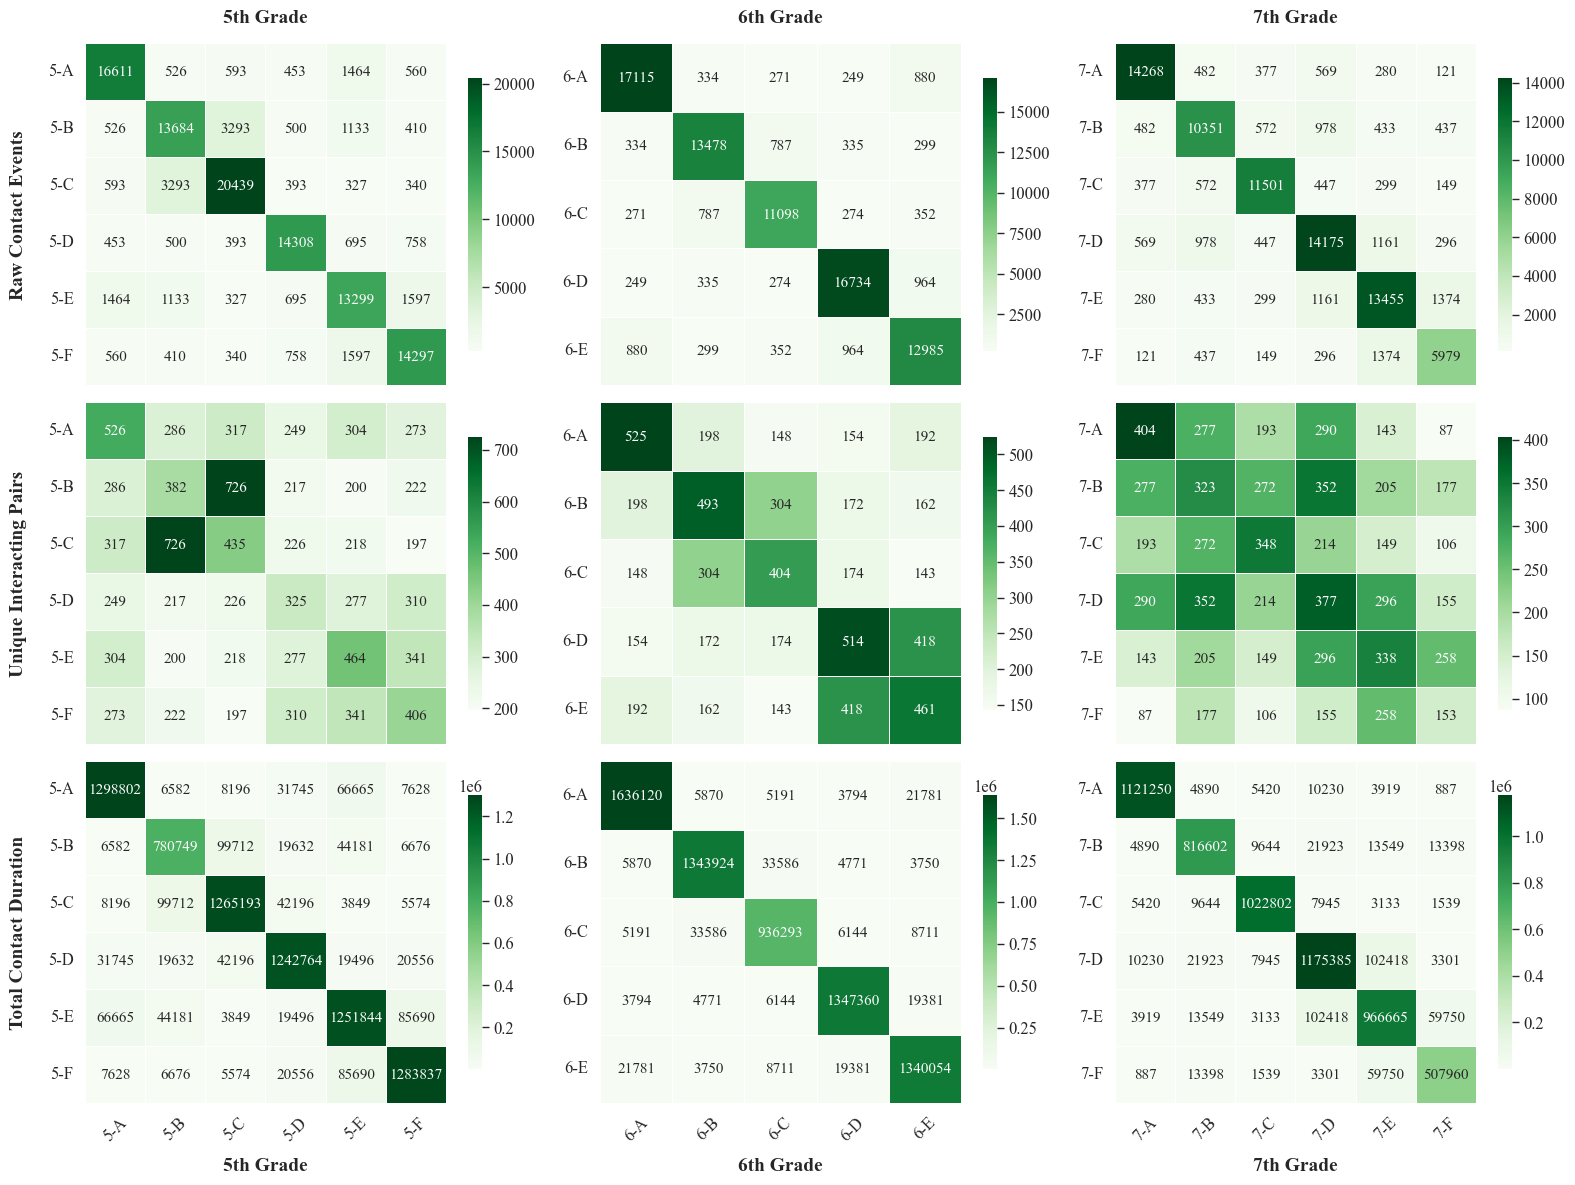

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from utils import build_matrix

# Get only the UNIQUE, sorted class names (e.g., ['5-A', '5-B', '5-C'...])
classes5 = sorted(list(set(known_net5.vs['class'])))
classes6 = sorted(list(set(known_net6.vs['class'])))
classes7 = sorted(list(set(known_net7.vs['class'])))

# Calculate the 9 matrices using the fast function from utils.py
matrix_weights5 = build_matrix(known_contacts5, classes5, mode='duration')
matrix_weights6 = build_matrix(known_contacts6, classes6, mode='duration')
matrix_weights7 = build_matrix(known_contacts7, classes7, mode='duration')

matrix_counts5 = build_matrix(known_contacts5, classes5, mode='count')
matrix_counts6 = build_matrix(known_contacts6, classes6, mode='count')
matrix_counts7 = build_matrix(known_contacts7, classes7, mode='count')

matrix_unique5 = build_matrix(known_contacts5, classes5, mode='unique_pairs')
matrix_unique6 = build_matrix(known_contacts6, classes6, mode='unique_pairs')
matrix_unique7 = build_matrix(known_contacts7, classes7, mode='unique_pairs')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

grade_configs = [
    {'grade': '5th', 'labels': classes5, 'counts': matrix_counts5, 'unique': matrix_unique5, 'weight': matrix_weights5},
    {'grade': '6th', 'labels': classes6, 'counts': matrix_counts6, 'unique': matrix_unique6, 'weight': matrix_weights6},
    {'grade': '7th', 'labels': classes7, 'counts': matrix_counts7, 'unique': matrix_unique7, 'weight': matrix_weights7},
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
row_titles = ['Raw Contact Events', 'Unique Interacting Pairs', 'Total Contact Duration']

for col, cfg in enumerate(grade_configs):
    labels = cfg['labels']
    
    for row, (matrix, title) in enumerate(zip([cfg['counts'], cfg['unique'], cfg['weight']], row_titles)):
        ax = axes[row, col]
        
        sns.heatmap(matrix, annot=True, linewidth=0.5, cmap='Greens',
                    annot_kws={'size': 11, 'fontname': 'Times New Roman'}, 
                    fmt='.0f', ax=ax, cbar_kws={"shrink": .8})
        
        ax.set_xticks(np.arange(len(labels)) + 0.5)
        ax.set_yticks(np.arange(len(labels)) + 0.5)
        
        # Always print the y-axis class labels for every grade
        ax.set_yticklabels(labels, rotation=0)
        
        if row == 2:
            ax.set_xticklabels(labels, ha='center', rotation=45)
            ax.set_xlabel(f"{cfg['grade']} Grade", labelpad=10, fontweight='bold')
        else:
            ax.set_xticklabels([])
            ax.set_xlabel('')
            
        # Only print the row title on the far-left column
        if col == 0:
            ax.set_ylabel(title, labelpad=15, fontweight='bold')
        else:
            ax.set_ylabel('')

        if row == 0:
            ax.set_title(f"{cfg['grade']} Grade", fontweight='bold', pad=15)
        else:
            ax.set_title('')

plt.tight_layout()
plt.savefig('figures/amongclassinteractions_3metrics.png', dpi=300, bbox_inches='tight')
plt.show()


### Classroom Modularity Analysis
In network science, **modularity** measures the strength of division of a network into communities (in this case, classrooms). A positive score indicates that students interact more frequently within their own assigned classroom than they do with students from other rooms, while a negative score indicates the opposite.

To fully understand the structural dynamics of the contact data, we evaluate modularity using two approaches simultaneously:
1. **Unweighted Modularity**: Evaluates structural community formation by treating all recorded interactions equally, regardless of duration. 
2. **Weighted Modularity**: Evaluates the true strength of social ties by factoring in the accumulated contact duration (`weight`) between each pair of students. 

By comparing these metrics, we determine whether classrooms form strong communities based purely on the *number* of interactions, the total *duration* of interactions, or both.


In [55]:
from igraph import VertexClustering
import pandas as pd

modularity_results = []

for grade, g in graphs.items():
    # 1. Group the network nodes by their 'class' attribute
    clustering = VertexClustering.FromAttribute(g, 'class')
    
    # 2. Calculate Unweighted Modularity (treats all contacts equally)
    unweighted_mod = g.modularity(clustering.membership)
    
    # 3. Calculate Weighted Modularity (factors in contact duration)
    weighted_mod = g.modularity(clustering.membership, weights='weight')
    
    # Store the results
    modularity_results.append({
        'Grade': f"{grade}th Grade",
        'Unweighted Modularity': unweighted_mod,
        'Weighted Modularity': weighted_mod
    })

# Convert to a DataFrame for a clean, tabular presentation
df_modularity = pd.DataFrame(modularity_results)
df_modularity.set_index('Grade', inplace=True)

# Print the cleanly formatted table with an explanatory header
print("--- Classroom Modularity Analysis ---")
print("Unweighted: Evaluates community structure ignoring contact duration.")
print("Weighted:   Evaluates community structure factoring in contact duration.\n")

# Display rounded to 4 decimal places
df_modularity.round(4)


--- Classroom Modularity Analysis ---
Unweighted: Evaluates community structure ignoring contact duration.
Weighted:   Evaluates community structure factoring in contact duration.



,Unweighted Modularity,Weighted Modularity
Grade,,
5th Grade,0.19970,0.76830
6th Grade,0.33630,0.77780
7th Grade,0.20760,0.77980


### Skewness and Distribution of Inter-Class Mingling

To understand whether the drop in modularity across grades is driven by uniform mingling (everyone interacting with everyone) or by a few specific "heavy-hitter" pairwise relationships, we evaluate the networks using two formal topology metrics applied to the **Unique Interacting Pairs**:

1. **Coefficient of Variation (CV) of Inter-class Edges:** Measures the skewness of external mingling. We extract all off-diagonal values (interactions between different classrooms) and calculate the standard deviation divided by the mean. A **higher CV** indicates that mingling is heavily concentrated in just one or two specific class pairs. A **lower CV** indicates egalitarian, uniform mingling across all classes.
2. **Average Participation Coefficient ($P$):** Measures how evenly a class distributes its connections. A **higher $P$** means classes interact evenly with every other class in the grade. A **lower $P$** indicates "cliquey" behavior, where external interactions are monopolized by just one other specific classroom.

**Key Findings:**
* **7th Grade (Most Uniform Mingling):** Surprisingly, 7th grade has the **lowest CV (0.3519)**. This proves that their mingling is highly uniform; they interact with almost every other classroom equally, rather than isolating to specific pairs.
* **5th Grade (Massive Pairwise Outlier):** 5th grade has the **highest CV (0.4277)**, driven by a massive outlier. The relationship between **5-B and 5-C (726 unique pairs)** is more than double any other connection in the grade (the next highest is 341), heavily skewing the network's mingling statistics.
* **6th Grade (Most "Cliquey"):** 6th grade has the **lowest Participation Coefficient (0.6485)**. When 6th graders interact outside their classroom, they do not mingle evenly with the whole grade; they tend to exclusively interact with just one specific other class (e.g., 6-D sticking strictly to 6-E).


In [56]:
import numpy as np
import pandas as pd

def calc_network_metrics(matrix, labels):
    n = matrix.shape[0]
    
    # 1. Coefficient of Variation (CV) of Inter-class Pairs
    # Extract only the upper triangle (off-diagonal) since the matrix is symmetric
    off_diag = []
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            off_diag.append(matrix[i, j])
            pairs.append(f"{labels[i]} & {labels[j]}")
            
    off_diag = np.array(off_diag)
    mean_off = np.mean(off_diag)
    std_off = np.std(off_diag)
    cv = std_off / mean_off if mean_off > 0 else 0
    
    # Identify the #1 Heavy-Hitter pair
    top_idx = np.argmax(off_diag)
    top_pair = f"{pairs[top_idx]} ({int(off_diag[top_idx])} pairs)"
    
    # 2. Average Class Participation Coefficient
    # We must double the diagonal (intra-class) to accurately reflect full node degree
    A_block = matrix.copy()
    np.fill_diagonal(A_block, np.diag(matrix) * 2)
    
    row_sums = np.sum(A_block, axis=1)
    participation = []
    for i in range(n):
        if row_sums[i] > 0:
            p_i = 1.0 - np.sum((A_block[i, :] / row_sums[i])**2)
            participation.append(p_i)
            
    avg_participation = np.mean(participation)
    
    return cv, avg_participation, top_pair

# Calculate metrics for all three grades using the matrices generated earlier
metrics = []
for grade, matrix, labels in zip(['5th', '6th', '7th'], 
                                 [matrix_unique5, matrix_unique6, matrix_unique7], 
                                 [classes5, classes6, classes7]):
    
    cv, avg_p, top_pair = calc_network_metrics(matrix, labels)
    metrics.append({
        'Grade': f"{grade} Grade",
        'Inter-Class CV (Skewness)': cv,
        'Avg Participation (Distribution)': avg_p,
        'Top Heavy-Hitter Pair': top_pair
    })

# Display as a clean DataFrame
df_metrics = pd.DataFrame(metrics).set_index('Grade')
df_metrics.round(4)


,Inter-Class CV (Skewness),Avg Participation (Distribution),Top Heavy-Hitter Pair
Grade,,,
5th Grade,0.42770,0.77110,5-B & 5-C (726 pairs)
6th Grade,0.40210,0.64850,6-D & 6-E (418 pairs)
7th Grade,0.35190,0.76960,7-B & 7-D (352 pairs)


### Classroom Modularity and Network Density (0 to 60 Seconds)

To systematically identify the optimal contact duration threshold that filters out passing hallway encounters (noise) while preserving structural social ties, we conduct a second-by-second sensitivity analysis from **0 to 60 seconds**. 

For each 1-second interval, we evaluate:
1. **Classroom Modularity:** Measures the strength of the social division between classrooms. Higher modularity indicates that interactions are highly clustered *within* assigned classrooms with minimal cross-classroom mixing. Modularity is evaluated against predefined class attributes (e.g. 5-A, 5-B, 5-C).
2. **Network Density:** Measures the overall connectivity of the graph. It represents the proportion of actual edges present relative to the total possible edges.

We run this sweep in parallel across two distinct student populations to evaluate structural consistency:
* **Known-Class Students:** Only includes students with valid, verified classroom identifiers (excluding students with missing registry data).
* **All Students (Full Student Body):** Includes all recorded student contacts, providing a complete bird's-eye view of the school-wide network dynamics.

The results are unified into a single wide table for each sweep to easily track how modularity and density trade off as the duration threshold increases.


In [57]:
from utils import filter_graph_by_duration
from igraph import VertexClustering

# Sweep every second from 0 to 60 seconds
thresholds = list(range(0, 61, 1))

# --- Known-class threshold sweep ---
df_mod_combined = pd.DataFrame(columns=['Threshold_Sec', '7th_Grade', '6th_Grade', '5th_Grade'])
df_dens_combined = pd.DataFrame(columns=['Threshold_Sec', '7th_Grade', '6th_Grade', '5th_Grade'])

for t_sec in thresholds:
    g_thresh7 = filter_graph_by_duration(base_net7, t_sec)
    g_thresh6 = filter_graph_by_duration(base_net6, t_sec)
    g_thresh5 = filter_graph_by_duration(base_net5, t_sec)
    
    # Modularity
    mod_7 = g_thresh7.modularity(VertexClustering.FromAttribute(g_thresh7, 'class').membership)
    mod_6 = g_thresh6.modularity(VertexClustering.FromAttribute(g_thresh6, 'class').membership)
    mod_5 = g_thresh5.modularity(VertexClustering.FromAttribute(g_thresh5, 'class').membership)
    df_mod_combined.loc[t_sec] = [t_sec, mod_7, mod_6, mod_5]
    
    # Density
    dens_7 = g_thresh7.density()
    dens_6 = g_thresh6.density()
    dens_5 = g_thresh5.density()
    df_dens_combined.loc[t_sec] = [t_sec, dens_7, dens_6, dens_5]

df_mod_combined = df_mod_combined.reset_index(drop=True)
df_dens_combined = df_dens_combined.reset_index(drop=True)

# Create a unified table for Known-class sweep display
df_display_known = pd.DataFrame({
    'Threshold_Sec': df_mod_combined['Threshold_Sec'],
    '7th_Modularity': df_mod_combined['7th_Grade'],
    '7th_Density': df_dens_combined['7th_Grade'],
    '6th_Modularity': df_mod_combined['6th_Grade'],
    '6th_Density': df_dens_combined['6th_Grade'],
    '5th_Modularity': df_mod_combined['5th_Grade'],
    '5th_Density': df_dens_combined['5th_Grade']
})

# --- All-students threshold sweep ---
df_mod_combined_all = pd.DataFrame(columns=['Threshold_Sec', '7th_Grade', '6th_Grade', '5th_Grade'])
df_dens_combined_all = pd.DataFrame(columns=['Threshold_Sec', '7th_Grade', '6th_Grade', '5th_Grade'])

for t_sec in thresholds:
    g_thresh7 = filter_graph_by_duration(base_net7_all, t_sec)
    g_thresh6 = filter_graph_by_duration(base_net6_all, t_sec)
    g_thresh5 = filter_graph_by_duration(base_net5_all, t_sec)
    
    # Modularity
    mod_7 = g_thresh7.modularity(VertexClustering.FromAttribute(g_thresh7, 'class').membership)
    mod_6 = g_thresh6.modularity(VertexClustering.FromAttribute(g_thresh6, 'class').membership)
    mod_5 = g_thresh5.modularity(VertexClustering.FromAttribute(g_thresh5, 'class').membership)
    df_mod_combined_all.loc[t_sec] = [t_sec, mod_7, mod_6, mod_5]
    
    # Density
    dens_7 = g_thresh7.density()
    dens_6 = g_thresh6.density()
    dens_5 = g_thresh5.density()
    df_dens_combined_all.loc[t_sec] = [t_sec, dens_7, dens_6, dens_5]

df_mod_combined_all = df_mod_combined_all.reset_index(drop=True)
df_dens_combined_all = df_dens_combined_all.reset_index(drop=True)

# Create a unified table for All-students sweep display
df_display_all = pd.DataFrame({
    'Threshold_Sec': df_mod_combined_all['Threshold_Sec'],
    '7th_Modularity': df_mod_combined_all['7th_Grade'],
    '7th_Density': df_dens_combined_all['7th_Grade'],
    '6th_Modularity': df_mod_combined_all['6th_Grade'],
    '6th_Density': df_dens_combined_all['6th_Grade'],
    '5th_Modularity': df_mod_combined_all['5th_Grade'],
    '5th_Density': df_dens_combined_all['5th_Grade']
})

print('Known-class sensitivity analysis sweep:')
display(df_display_known)
print('\nAll-students sensitivity analysis sweep:')
display(df_display_all)


Known-class sensitivity analysis sweep:


,Threshold_Sec,7th_Modularity,7th_Density,6th_Modularity,6th_Density,5th_Modularity,5th_Density
0,0.00000,0.20759,0.42874,0.33626,0.35975,0.19969,0.43318
1,1.00000,0.20759,0.42874,0.33626,0.35975,0.19969,0.43318
2,2.00000,0.21749,0.41760,0.33675,0.35943,0.20060,0.43205
3,3.00000,0.23449,0.39950,0.33797,0.35862,0.20271,0.42948
4,4.00000,0.25409,0.37997,0.36319,0.34218,0.22042,0.40952
...,...,...,...,...,...,...,...
56,56.00000,0.64055,0.18911,0.68340,0.20350,0.52540,0.21694
57,57.00000,0.64262,0.18844,0.68533,0.20277,0.52808,0.21593
58,58.00000,0.64505,0.18777,0.68583,0.20221,0.53092,0.21486
59,59.00000,0.64580,0.18760,0.69028,0.20092,0.53261,0.21417



All-students sensitivity analysis sweep:


,Threshold_Sec,7th_Modularity,7th_Density,6th_Modularity,6th_Density,5th_Modularity,5th_Density
0,0.00000,0.17761,0.42693,0.31796,0.36163,0.18612,0.43414
1,1.00000,0.17761,0.42693,0.31796,0.36163,0.18612,0.43414
2,2.00000,0.18610,0.41581,0.31841,0.36132,0.18696,0.43302
3,3.00000,0.20129,0.39671,0.31960,0.36048,0.18899,0.43032
4,4.00000,0.21747,0.37774,0.34403,0.34346,0.20532,0.41069
...,...,...,...,...,...,...,...
56,56.00000,0.55033,0.18748,0.65374,0.20252,0.48832,0.21774
57,57.00000,0.55205,0.18684,0.65550,0.20183,0.49065,0.21680
58,58.00000,0.55411,0.18620,0.65589,0.20129,0.49311,0.21580
59,59.00000,0.55517,0.18591,0.66024,0.19998,0.49516,0.21492


### Visualizing Threshold Impact on Modularity and Density (Stacked View)

To visually interpret how filtering out brief contacts alters classroom structural divisions and overall network connectivity, we plot **Classroom Modularity** and **Network Density** as functions of the contact duration threshold ($0$ to $60$ seconds).

* **Top Panel (Classroom Modularity):** Illustrates modularity with respect to predefined classroom groupings. A higher modularity score represents stronger, more segregated classroom clusters with fewer cross-classroom interactions.
* **Bottom Panel (Network Density):** Shows the ratio of active edges relative to all possible connections. A higher density means a more densely interconnected cohort.
* **X-Axis (Shared):** The minimum contact duration threshold in seconds (granularly tracked with labeled major grid lines every 5 seconds and minor grid lines every 1 second).

**Key Interpretation Guidelines for the Paper:**
1. **Modularity Ascent:** As the threshold increases from 0 seconds, modularity climbs rapidly. This indicates that deleting extremely brief contacts successfully purges "social noise" (e.g., passing by students from other classes in hallways) and reveals the underlying classroom-centric social structure.
2. **Density Descent:** Simultaneously, density falls as edges are pruned. The rate of decline shows how quickly the network is losing edges.
3. **Elbow/Stabilization Point:** The region where the modularity curve starts to flatten out (gains in structural clarity slow down) while density continues to drop represents the optimal window for baseline threshold selection. It indicates we have successfully removed noisy casual links without over-fragmenting the network.


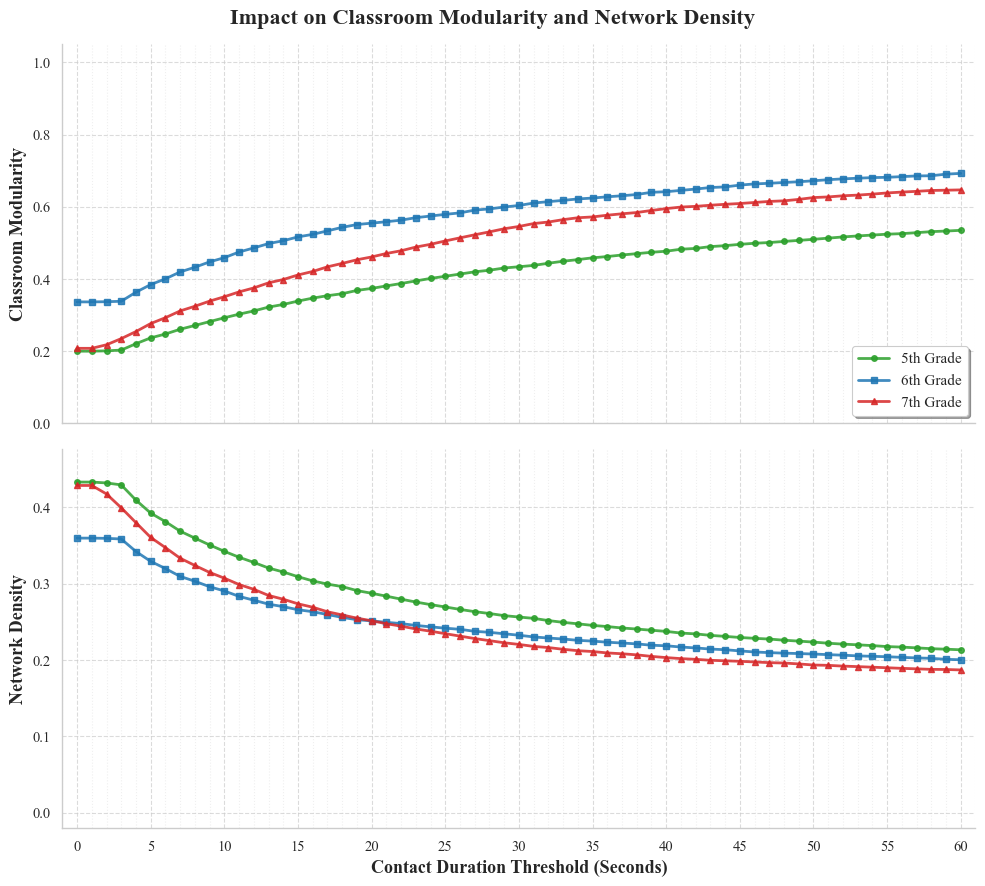

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# Set clean, academic style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams["font.family"] = "Times New Roman"

# Create a 2-panel figure stacked vertically with shared X-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9.5), sharex=True)

# Colors and marker shapes
colors = {'5th_Grade': '#2ca02c', '6th_Grade': '#1f77b4', '7th_Grade': '#d62728'}
markers = {'5th_Grade': 'o', '6th_Grade': 's', '7th_Grade': '^'}
labels = {'5th_Grade': '5th Grade', '6th_Grade': '6th Grade', '7th_Grade': '7th Grade'}

# --- Top Panel: Classroom Modularity ---
for grade in ['5th_Grade', '6th_Grade', '7th_Grade']:
    ax1.plot(df_mod_combined['Threshold_Sec'], df_mod_combined[grade],
             color=colors[grade],
             marker=markers[grade],
             linestyle='-',
             linewidth=2.0,
             markersize=4,
             label=labels[grade],
             alpha=0.85)

ax1.set_ylabel('Classroom Modularity', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.set_xlim(-1, 61)

# Major ticks every 5s, minor ticks every 1s
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_minor_locator(MultipleLocator(1))
ax1.grid(True, which='major', linestyle='--', alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', alpha=0.3)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Place the legend only once (on the top panel)
ax1.legend(loc='lower right', frameon=True, fontsize=11, shadow=True)

# --- Bottom Panel: Network Density ---
for grade in ['5th_Grade', '6th_Grade', '7th_Grade']:
    ax2.plot(df_dens_combined['Threshold_Sec'], df_dens_combined[grade],
             color=colors[grade],
             marker=markers[grade],
             linestyle='-',
             linewidth=2.0,
             markersize=4,
             label=labels[grade],
             alpha=0.85)

ax2.set_xlabel('Contact Duration Threshold (Seconds)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Network Density', fontsize=13, fontweight='bold')
max_dens = df_dens_combined[['5th_Grade', '6th_Grade', '7th_Grade']].max().max()
ax2.set_ylim(-0.02, max_dens * 1.1)

# Major ticks every 5s, minor ticks every 1s
ax2.xaxis.set_major_locator(MultipleLocator(5))
ax2.xaxis.set_minor_locator(MultipleLocator(1))
ax2.grid(True, which='major', linestyle='--', alpha=0.7)
ax2.grid(True, which='minor', linestyle=':', alpha=0.3)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Main figure title and layout adjustments to prevent suptitle overlap
fig.suptitle('Impact on Classroom Modularity and Network Density', fontsize=16, fontweight='bold', y=0.93)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('figures/modularity_density_thresholds.png', dpi=300, bbox_inches='tight')
plt.show()


### Optimal Baseline Threshold Selection and Network Pruning

To establish a mathematically justified baseline contact duration threshold for our subsequent network analyses, we locate the second of **maximum structural change**. 

For each consecutive second step, we calculate:
1. **Modularity Jump ($\Delta M$):** The first-order difference in modularity ($\text{Modularity}_{t} - \text{Modularity}_{t-1}$), representing the gain in structural clarity.
2. **Density Drop ($\Delta D$):** The first-order difference in network density ($\text{Density}_{t} - \text{Density}_{t-1}$), representing the loss of active social connections.

**Programmatic Optimization (Combined Change Score):**
Since modularity gains and density drops operate on different numerical ranges, we normalize the absolute values of both jumps to a standard $[0, 1]$ scale. We then sum these normalized values to calculate a **Combined Change Score**:

$$\text{Combined Change} = \text{Normalized } |\Delta M| + \text{Normalized } |\Delta D|$$

This score identifies the threshold (in seconds) that achieves the optimal trade-off: **maximizing the emergence of classroom divisions while minimizing the fragmentation of the interaction network**. 

Once identified, these optimal thresholds are applied to filter the raw networks, and a post-threshold summary table is compiled displaying the final counts of nodes (students) and edges (interactions) remaining in the baseline networks.


In [59]:
# --- 1. Known-class analysis (0-60 seconds) ---
df_mod_combined['Avg_Modularity'] = df_mod_combined[['7th_Grade', '6th_Grade', '5th_Grade']].mean(axis=1)
df_mod_combined['Modularity_Jump'] = df_mod_combined['Avg_Modularity'].diff()

df_dens_combined['Avg_Density'] = df_dens_combined[['7th_Grade', '6th_Grade', '5th_Grade']].mean(axis=1)
df_dens_combined['Density_Jump'] = df_dens_combined['Avg_Density'].diff()

# Normalize absolute changes to a 0-1 scale to combine them fairly
mod_jump_abs = df_mod_combined['Modularity_Jump'].abs()
mod_span = mod_jump_abs.max() - mod_jump_abs.min()
norm_mod_jump = (mod_jump_abs - mod_jump_abs.min()) / (mod_span if mod_span > 0 else 1.0)

dens_jump_abs = df_dens_combined['Density_Jump'].abs()
dens_span = dens_jump_abs.max() - dens_jump_abs.min()
norm_dens_jump = (dens_jump_abs - dens_jump_abs.min()) / (dens_span if dens_span > 0 else 1.0)

df_mod_combined['Combined_Change'] = norm_mod_jump + norm_dens_jump

# Find seconds of maximum changes
mod_jump_sec = int(df_mod_combined.loc[df_mod_combined['Modularity_Jump'].idxmax(), 'Threshold_Sec'])
dens_jump_sec = int(df_dens_combined.loc[df_dens_combined['Density_Jump'].abs().idxmax(), 'Threshold_Sec'])
combined_jump_sec = int(df_mod_combined.loc[df_mod_combined['Combined_Change'].idxmax(), 'Threshold_Sec'])

# --- 2. All-students analysis (0-60 seconds) ---
df_mod_combined_all['Avg_Modularity'] = df_mod_combined_all[['7th_Grade', '6th_Grade', '5th_Grade']].mean(axis=1)
df_mod_combined_all['Modularity_Jump'] = df_mod_combined_all['Avg_Modularity'].diff()

df_dens_combined_all['Avg_Density'] = df_dens_combined_all[['7th_Grade', '6th_Grade', '5th_Grade']].mean(axis=1)
df_dens_combined_all['Density_Jump'] = df_dens_combined_all['Avg_Density'].diff()

# Normalize absolute changes
mod_jump_abs_all = df_mod_combined_all['Modularity_Jump'].abs()
mod_span_all = mod_jump_abs_all.max() - mod_jump_abs_all.min()
norm_mod_jump_all = (mod_jump_abs_all - mod_jump_abs_all.min()) / (mod_span_all if mod_span_all > 0 else 1.0)

dens_jump_abs_all = df_dens_combined_all['Density_Jump'].abs()
dens_span_all = dens_jump_abs_all.max() - dens_jump_abs_all.min()
norm_dens_jump_all = (dens_jump_abs_all - dens_jump_abs_all.min()) / (dens_span_all if dens_span_all > 0 else 1.0)

df_mod_combined_all['Combined_Change'] = norm_mod_jump_all + norm_dens_jump_all

# Find seconds of maximum changes
mod_jump_sec_all = int(df_mod_combined_all.loc[df_mod_combined_all['Modularity_Jump'].idxmax(), 'Threshold_Sec'])
dens_jump_sec_all = int(df_dens_combined_all.loc[df_dens_combined_all['Density_Jump'].abs().idxmax(), 'Threshold_Sec'])
combined_jump_sec_all = int(df_mod_combined_all.loc[df_mod_combined_all['Combined_Change'].idxmax(), 'Threshold_Sec'])

# --- Print Sweep Results ---
print("--- Known-Class Metrics Sweep Analysis (0-60 seconds) ---")
print(f"Second with most Modularity Jump: {mod_jump_sec} seconds")
print(f"Second with most Density Change:   {dens_jump_sec} seconds")
print(f"Second with most COMBINED Change:  {combined_jump_sec} seconds (Normalized Mod + Density change)")

print("\n--- All-Students Metrics Sweep Analysis (0-60 seconds) ---")
print(f"Second with most Modularity Jump: {mod_jump_sec_all} seconds")
print(f"Second with most Density Change:   {dens_jump_sec_all} seconds")
print(f"Second with most COMBINED Change:  {combined_jump_sec_all} seconds (Normalized Mod + Density change)")

# --- Set and Apply Combined Optimal Thresholds ---
baseline_threshold_sec = combined_jump_sec
baseline_threshold_min = baseline_threshold_sec / 60

baseline_threshold_sec_all = combined_jump_sec_all
baseline_threshold_min_all = baseline_threshold_sec_all / 60

print(f'\n--- Applying Baseline Thresholds (Based on Combined Change) ---')
print(f'Known-Class Baseline Threshold: {baseline_threshold_min:.2f} min ({baseline_threshold_sec} sec)')
print(f'All-Students Baseline Threshold: {baseline_threshold_min_all:.2f} min ({baseline_threshold_sec_all} sec)')

# Apply thresholds to the graphs
g5_baseline     = filter_graph_by_duration(base_net5,     baseline_threshold_sec)
g6_baseline     = filter_graph_by_duration(base_net6,     baseline_threshold_sec)
g7_baseline     = filter_graph_by_duration(base_net7,     baseline_threshold_sec)
g5_baseline_all = filter_graph_by_duration(base_net5_all, baseline_threshold_sec_all)
g6_baseline_all = filter_graph_by_duration(base_net6_all, baseline_threshold_sec_all)
g7_baseline_all = filter_graph_by_duration(base_net7_all, baseline_threshold_sec_all)

# --- Final bird's-eye comparison ---
final_summary = pd.DataFrame({
    'Known — Nodes':  [g5_baseline.vcount(),     g6_baseline.vcount(),     g7_baseline.vcount()],
    'Known — Edges':  [g5_baseline.ecount(),     g6_baseline.ecount(),     g7_baseline.ecount()],
    'All — Nodes':    [g5_baseline_all.vcount(), g6_baseline_all.vcount(), g7_baseline_all.vcount()],
    'All — Edges':    [g5_baseline_all.ecount(), g6_baseline_all.ecount(), g7_baseline_all.ecount()],
}, index=['5th Grade', '6th Grade', '7th Grade'])
final_summary.index.name = 'Grade'
print('\n--- Final Post-Threshold Network Summary ---')
display(final_summary)


--- Known-Class Metrics Sweep Analysis (0-60 seconds) ---
Second with most Modularity Jump: 4 seconds
Second with most Density Change:   4 seconds
Second with most COMBINED Change:  4 seconds (Normalized Mod + Density change)

--- All-Students Metrics Sweep Analysis (0-60 seconds) ---
Second with most Modularity Jump: 4 seconds
Second with most Density Change:   4 seconds
Second with most COMBINED Change:  4 seconds (Normalized Mod + Density change)

--- Applying Baseline Thresholds (Based on Combined Change) ---
Known-Class Baseline Threshold: 0.07 min (4 sec)
All-Students Baseline Threshold: 0.07 min (4 sec)

--- Final Post-Threshold Network Summary ---


,Known — Nodes,Known — Edges,All — Nodes,All — Edges
Grade,,,,
5th Grade,179,6524,185,6990
6th Grade,158,4244,162,4479
7th Grade,155,4535,168,5299


### Baseline Network Architecture & Metrics (All Valid Students)
With our mathematical baseline threshold enforced across the complete student body, we can now compute fundamental network metrics for the 7th, 6th, and 5th grades. 

Because this analysis calculates pure structural factors (like the density of social links and absolute clique sizes), **it includes all valid students rather than just known classroom members**. Including students with an "Unknown" class code is critical here, as stripping them out would mathematically fracture valid friendships, artificially lowering the Average Degree and Network Density of the school.

**Key Metrics Captured:**
- **Network Density:** The percentage of actual peer connections relative to all theoretically possible connections.
- **Average Degree:** The average count of entirely unique students a single student closely interacted with.
- **Average Contact Duration:** The mean total time (in minutes) spent interacting across validated network edges.
- **Clustering Coefficient:** The propensity of students to form structurally closed, tightly-knit triad friendships.
- **Average Shortest Path:** The minimum number of "social hops" required to connect any two random students.
- **Max Clique Size:** The absolute largest, perfectly interconnected group of peers in the entire grade.


In [60]:
import numpy as np
import pandas as pd
import igraph

metrics_data_all = []

# Iterate through our final baseline graphs that include ALL students (known + unknown classes)
for grade, g in zip(['7th Grade', '6th Grade', '5th Grade'], [g7_baseline_all, g6_baseline_all, g5_baseline_all]):
    # Convert weights from seconds to minutes for the average calculation
    avg_duration_min = np.mean(g.es['weight']) / 60 if g.ecount() > 0 else 0
    
    # Calculate Normalized Weight/Degree using the old formula:
    # 1. Get degree and strength (weights) per node
    degrees = np.array(g.degree())
    strengths = np.array(g.strength(weights='weight'))
    
    # 2. Normalize both to [1, 100] scale
    min_deg, max_deg = degrees.min(), degrees.max()
    deg_span = max_deg - min_deg
    norm_deg = ((degrees - min_deg) / (deg_span if deg_span > 0 else 1.0)) * 99 + 1
    
    min_str, max_str = strengths.min(), strengths.max()
    str_span = max_str - min_str
    norm_str = ((strengths - min_str) / (str_span if str_span > 0 else 1.0)) * 99 + 1
    
    # 3. Calculate average of the ratio
    avg_weight_degree = np.mean(norm_str / norm_deg) if g.vcount() > 0 else 0
    
    metrics_data_all.append({
        'Grade': grade,
        'Total Students (Nodes)': g.vcount(),
        'Total Contacts (Edges)': g.ecount(),
        'Network Density': g.density(),
        'Avg Degree': np.mean(g.degree()),
        'Avg Contact Duration (min)': avg_duration_min,
        'Weight/Degree': avg_weight_degree,
        'Avg Clustering Coefficient': g.transitivity_undirected(),
        'Avg Shortest Path': g.average_path_length(directed=False),
        'Max Clique Size': len(g.largest_cliques()[0]) if g.vcount() > 0 else 0
    })

# Convert the array to a clean DataFrame
df_network_metrics_all = pd.DataFrame(metrics_data_all)
df_network_metrics_all.set_index('Grade', inplace=True)

# Clean up the display format for readability (3 decimal places)
pd.options.display.float_format = '{:.3f}'.format

# Output the final metrics table
df_network_metrics_all


,Total Students (Nodes),Total Contacts (Edges),Network Density,Avg Degree,Avg Contact Duration (min),Weight/Degree,Avg Clustering Coefficient,Avg Shortest Path,Max Clique Size
Grade,,,,,,,,,
7th Grade,168,5299,0.378,63.083,21.573,2.262,0.518,1.623,30
6th Grade,162,4479,0.343,55.296,25.742,2.356,0.539,1.660,32
5th Grade,185,6990,0.411,75.568,19.150,1.293,0.557,1.590,41


### Node-Level Metric Distributions Across Grades

Per-student metrics — **degree**, **local clustering coefficient**, and **total contact duration (weights)** — are extracted directly from `g5_baseline_all`, `g6_baseline_all`, and `g7_baseline_all` using `graph_to_metrics_df()` and consolidated into `all_metrics`. Violin plots show the full distribution shape and inner quartile lines for each grade, allowing direct comparison of how connectivity is distributed across individual students.


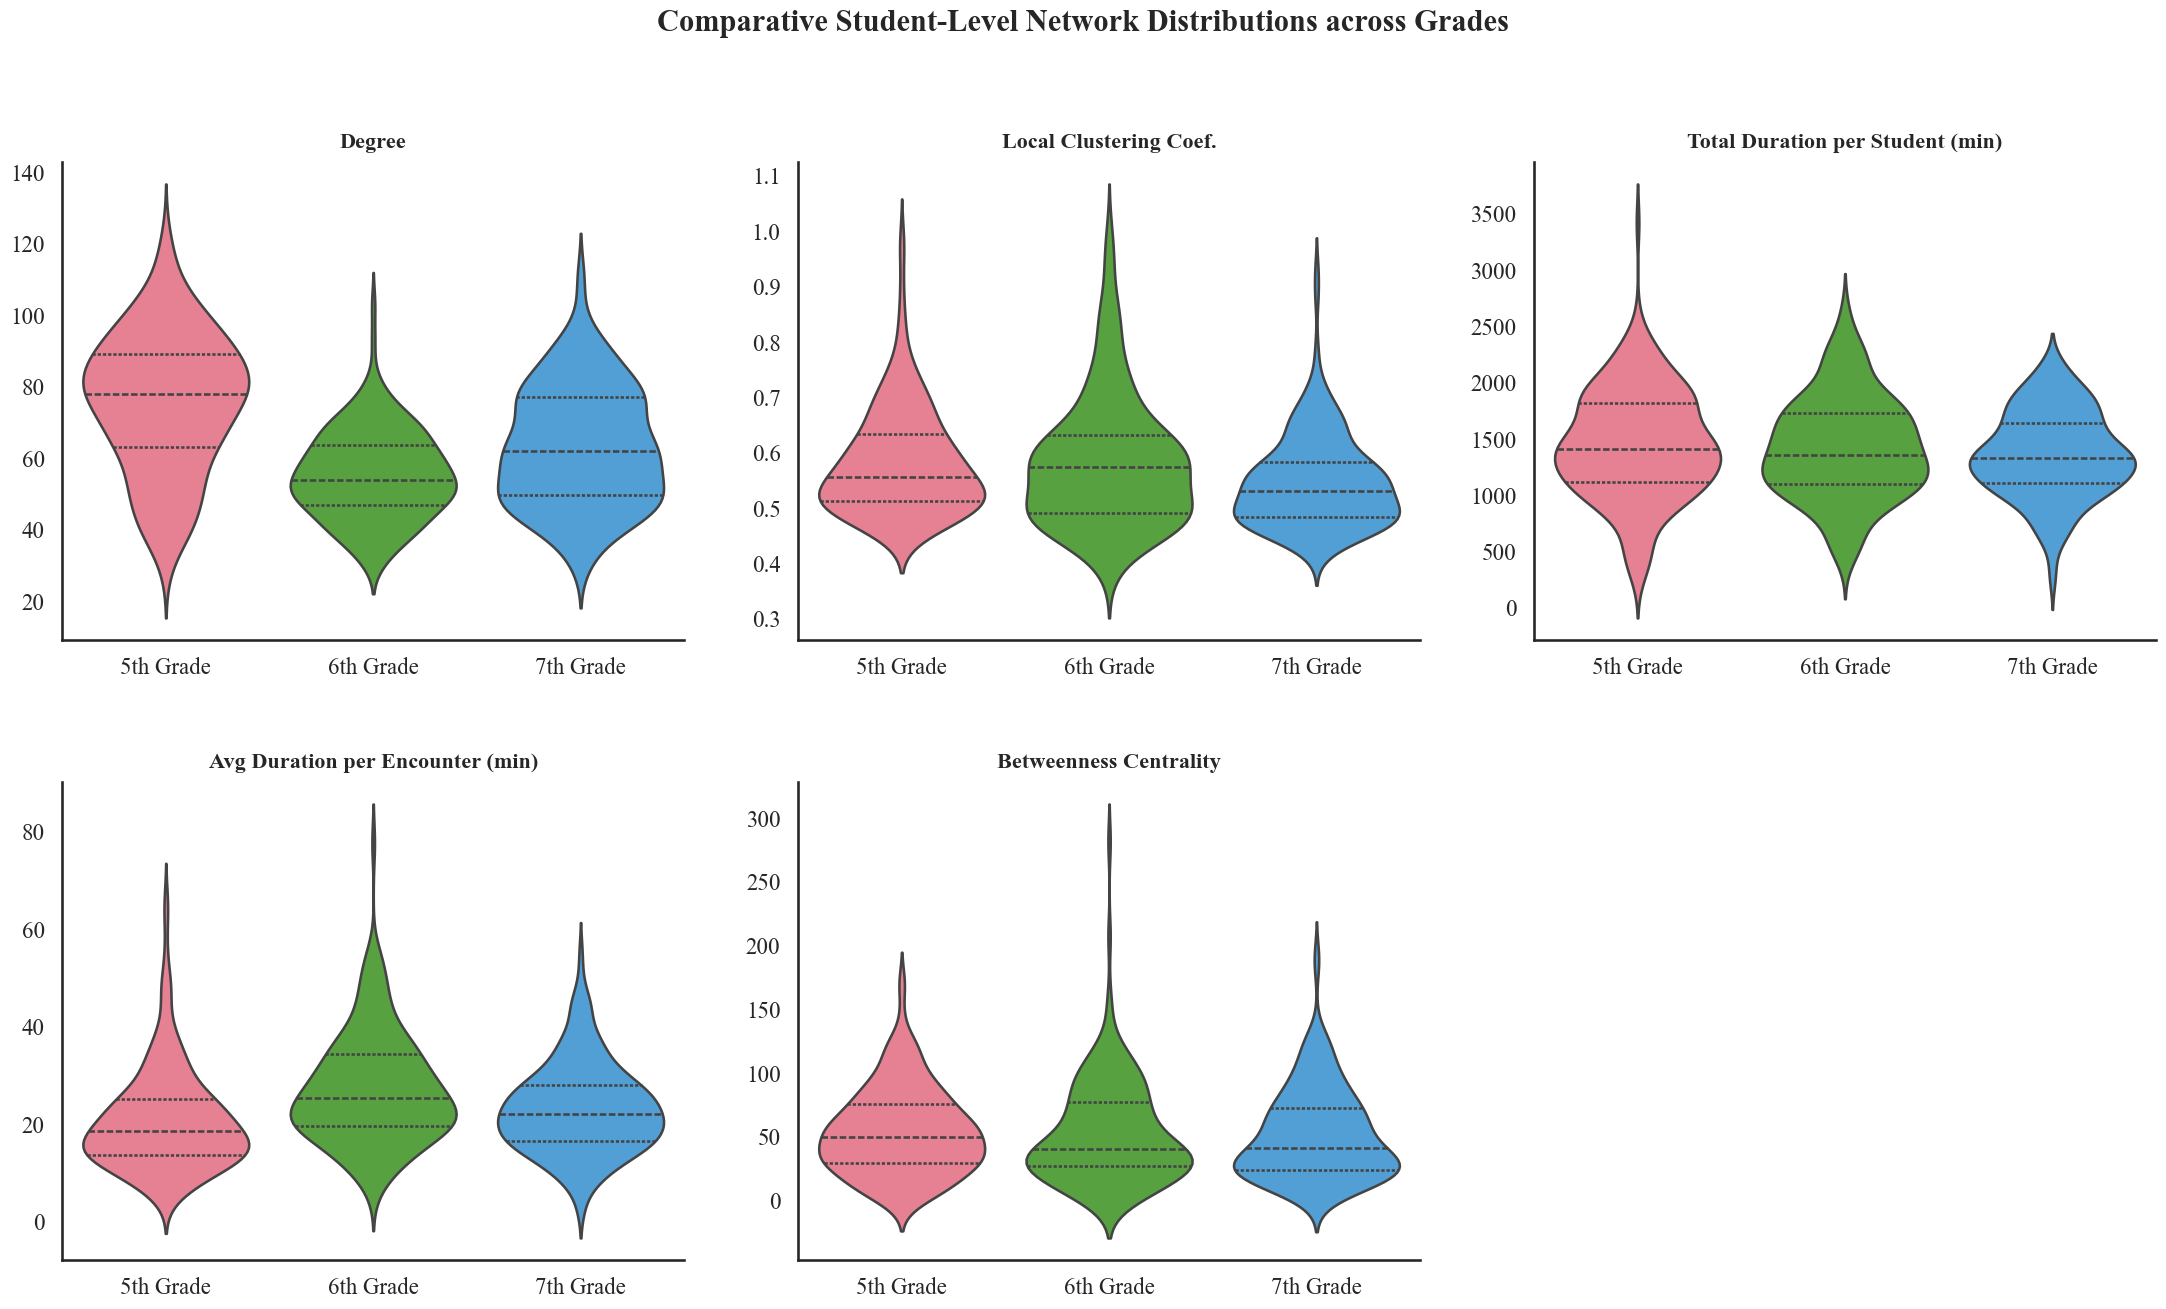

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Extract per-node metrics from each grade's graph ---
def graph_to_metrics_df(g, grade_label):
    """Build a node-level metrics DataFrame from an igraph Graph object."""
    # Get raw node metrics
    degrees = np.array(g.degree())
    strengths = np.array(g.strength(weights='weight'))
    
    # Calculate average weight/degree per node (in minutes)
    weight_degree = (strengths / degrees) / 60 if len(degrees) > 0 else np.zeros_like(degrees)
    
    # Calculate betweenness centrality
    betweenness = g.betweenness()
    
    return pd.DataFrame({
        'tagid':           g.vs['id'],
        'class':           g.vs['class'],
        'name':            g.vs['name'],
        'degree':          degrees,
        'clustering_coef': g.transitivity_local_undirected(mode='nan', weights=None),
        'weights':         strengths / 60,  # Convert total weights to minutes
        'weight_degree':   weight_degree,
        'betweenness':     betweenness,
        'Grade':           grade_label
    })

all_metrics = pd.concat([
    graph_to_metrics_df(g5_baseline_all, '5th Grade'),
    graph_to_metrics_df(g6_baseline_all, '6th Grade'),
    graph_to_metrics_df(g7_baseline_all, '7th Grade')
], ignore_index=True)

# Ensure numeric types
numeric_cols = ['degree', 'clustering_coef', 'weights', 'weight_degree', 'betweenness']
all_metrics[numeric_cols] = all_metrics[numeric_cols].apply(pd.to_numeric, errors='coerce')

# --- 2. Shared aesthetics ---
METRICS = {
    'degree':          'Degree',
    'clustering_coef': 'Local Clustering Coef.',
    'weights':         'Total Duration per Student (min)',
    'weight_degree':   'Avg Duration per Encounter (min)',
    'betweenness':     'Betweenness Centrality'
}
palette = sns.color_palette("husl", 3)
sns.set_theme(style="white", context="talk") # Clean white style without grids
plt.rcParams["font.family"] = "Times New Roman"

# --- 3. Plotting in a 2x3 Grid ---
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Comparative Student-Level Network Distributions across Grades',
             fontsize=22, fontweight='bold', y=0.97)

# Flatten axes for iteration (leaving the 6th panel empty)
axes = axes.flatten()

for idx, (col, label) in enumerate(METRICS.items()):
    ax = axes[idx]
    sns.violinplot(data=all_metrics, x='Grade', y=col, ax=ax,
                   hue='Grade', palette=palette, legend=False, inner='quartile')
    ax.set_title(label, fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Remove the empty 6th subplot axis
fig.delaxes(axes[5])

plt.tight_layout(rect=[0, 0.03, 1, 0.94], h_pad=3.0, w_pad=2.0)
plt.savefig('figures/node_metrics_violinplot.png', dpi=300)
plt.show()


### Raw Network Metrics by Grade: Individual Panels

While the Z-score plot highlights *relative* differences, this panel shows the **absolute values** of each metric side-by-side across grade levels. Each subplot corresponds to one of the six graph-level metrics from `df_network_metrics_all`, with bars annotated with their exact values. This makes it easy to read off precise figures (e.g. the actual number of edges or average duration) while still comparing across grades visually.


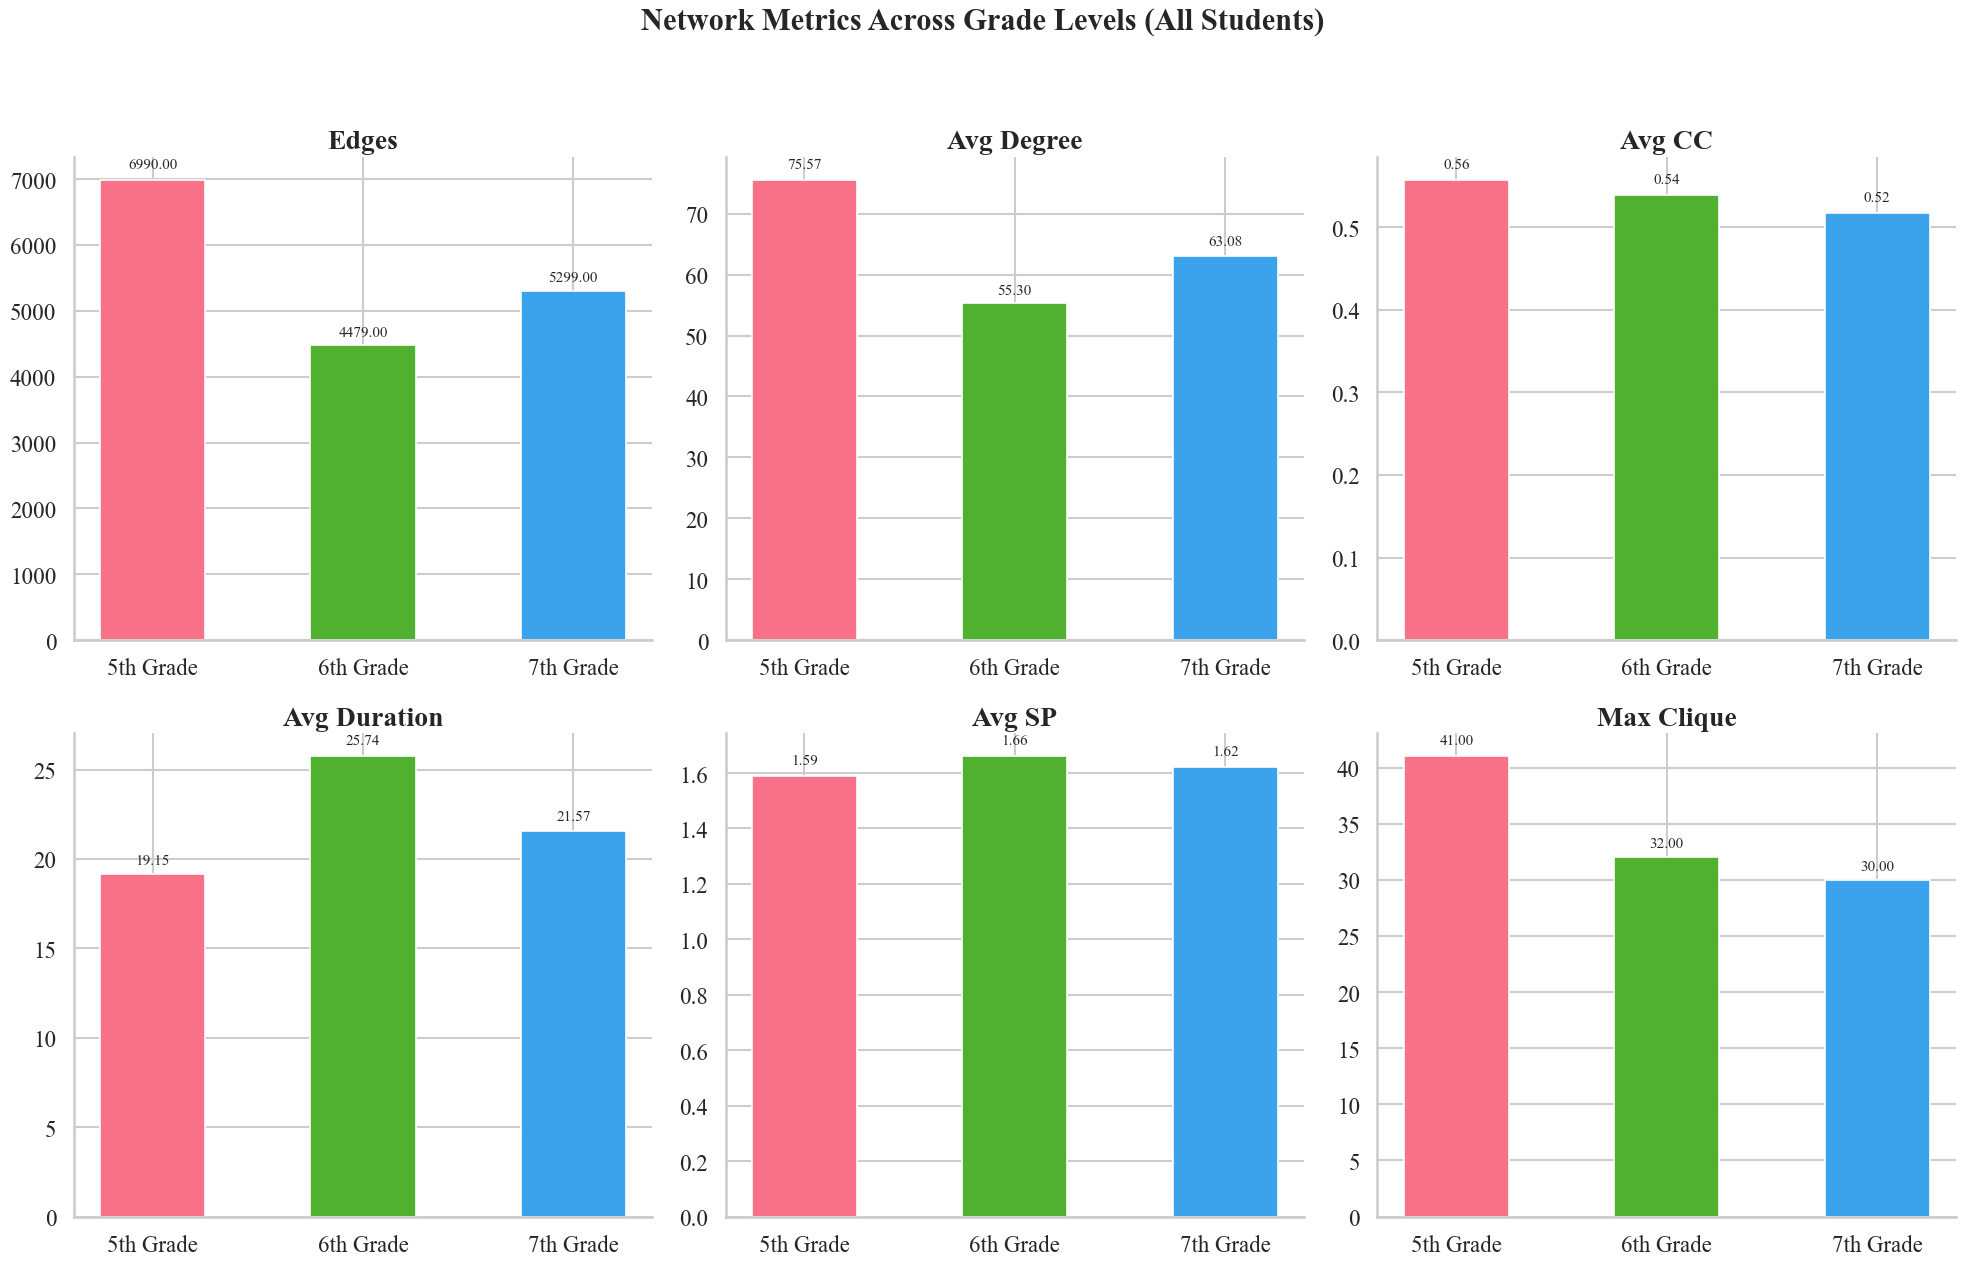

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

col_rename = {
    'Total Contacts (Edges)':     'Edges',      
    'Avg Degree':                 'Avg Degree',
    'Avg Clustering Coefficient': 'Avg CC',
    'Avg Contact Duration (min)': 'Avg Duration', 
    'Avg Shortest Path':          'Avg SP',
    'Max Clique Size':            'Max Clique'
}
# Rename and reindex to order: 5th Grade, 6th Grade, 7th Grade
df_plot = df_network_metrics_all.rename(columns=col_rename)
df_plot = df_plot.reindex(['5th Grade', '6th Grade', '7th Grade'])

palette = sns.color_palette("husl", 3)
grades  = df_plot.index.tolist()
metrics = list(col_rename.values())

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "Times New Roman"

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle('Network Metrics Across Grade Levels (All Students)',
             fontsize=22, fontweight='bold')
axes = axes.flatten()

for i, (col, ax) in enumerate(zip(metrics, axes)):
    bars = ax.bar(grades, df_plot[col], color=palette, width=0.5, edgecolor='white', linewidth=1.2)
    ax.set_title(col, fontsize=20, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Annotate bar values
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('figures/network_metrics_all_grid.png', dpi=300)
plt.show()


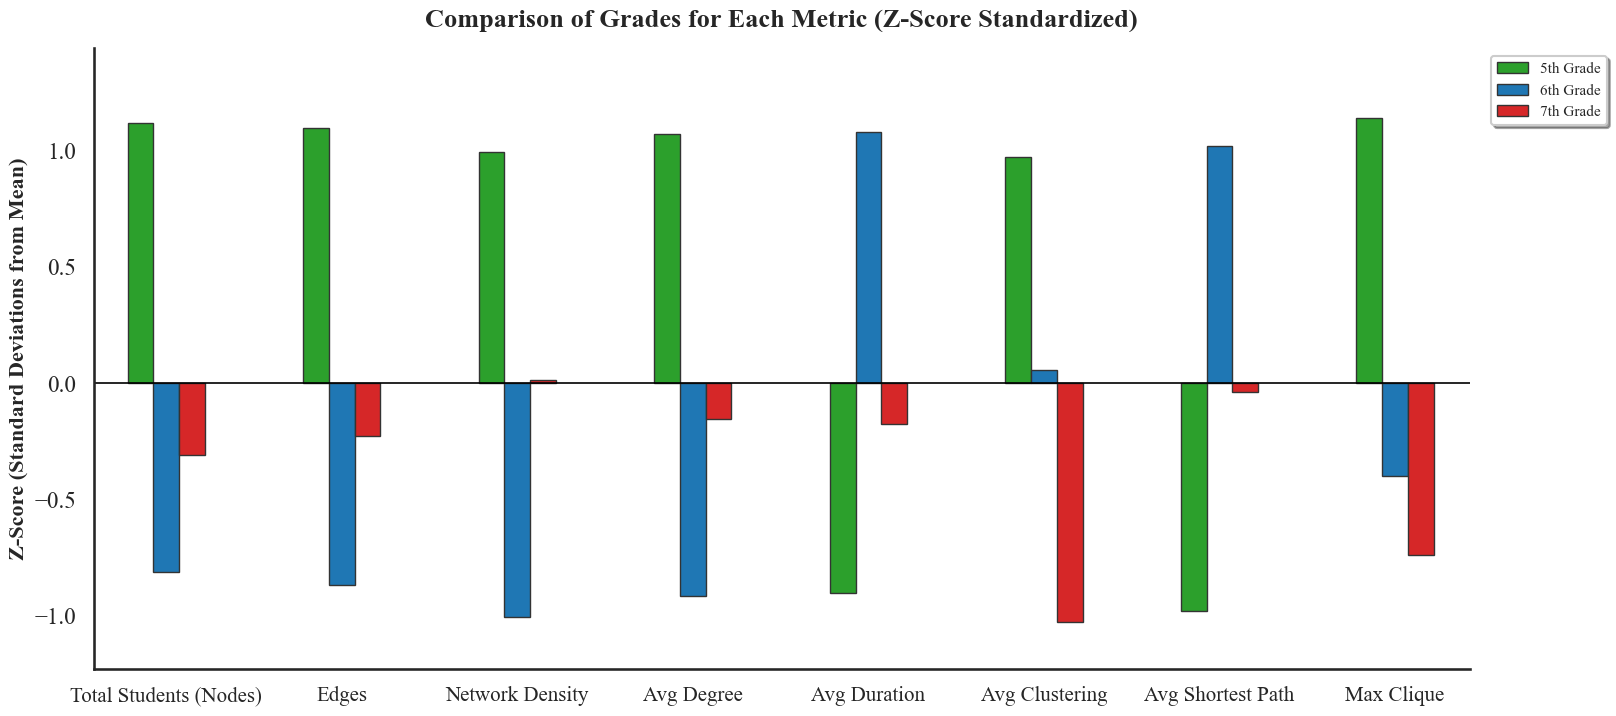

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

col_rename = {
    'Total Contacts (Edges)':     'Edges',      
    'Avg Degree':                 'Avg Degree',
    'Avg Clustering Coefficient': 'Avg Clustering', # Shortened for spacing
    'Avg Contact Duration (min)': 'Avg Duration', 
    'Avg Shortest Path':          'Avg Shortest Path',
    'Max Clique Size':            'Max Clique'
}

# Rename columns and explicitly drop 'Weight/Degree' from the plot data
df_plot = df_network_metrics_all.rename(columns=col_rename)
df_plot = df_plot.drop(columns=['Weight/Degree'], errors='ignore')

# Z-score normalize across the grades
df_zscore = (df_plot - df_plot.mean()) / df_plot.std()

# Reorder the grades so 5th is left, 6th is middle, and 7th is right
df_zscore = df_zscore.reindex(['5th Grade', '6th Grade', '7th Grade'])

# Using 'white' style to completely remove the background gridlines
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "Times New Roman"

# Figure size with slightly more width to accommodate the legend on the right
fig, ax = plt.subplots(figsize=(16.5, 7.5))

# Spreads the groups out
bar_width = 0.22
index = np.arange(len(df_zscore.columns)) * 1.5 
grades = df_zscore.index.tolist()
colors = ['#2ca02c', '#1f77b4', '#d62728'] # Green, Blue, Red

# Plot bars with thin dark borders for high-contrast visibility
for i, (grade, color) in enumerate(zip(grades, colors)):
    ax.bar(index + i * bar_width, df_zscore.loc[grade],
           width=bar_width, label=grade, color=color, edgecolor='#333333', linewidth=1.0)

# Add baseline at Z=0
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

# Labels and titles
ax.set_title('Comparison of Grades for Each Metric (Z-Score Standardized)',
             fontsize=19, fontweight='bold', pad=15)
ax.set_ylabel('Z-Score (Standard Deviations from Mean)', fontsize=16, fontweight='bold')

# Configure X ticks centered under the middle bar of each group
ax.set_xticks(index + bar_width)
# Shifted labels slightly to the right using ha='center'
ax.set_xticklabels(df_zscore.columns, fontsize=15, rotation=0, ha='center')

# Give a little breathing room on the limits
ax.set_xlim(index[0] - 0.4, index[-1] + 3 * bar_width + 0.2)
ax.set_ylim(df_zscore.min().min() - 0.2, df_zscore.max().max() + 0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Place the legend cleanly outside the plot to the right
ax.legend(prop={'size': 11}, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('figures/network_metrics_zscore_comparison.png', dpi=300)
plt.show()

### Comparative Network Metrics: Z-Score Normalized View

Since the six graph-level metrics in `df_network_metrics_all` operate on very different scales (e.g. number of edges vs. clustering coefficient), we apply **Z-score normalization** before plotting. Each bar represents how many standard deviations a grade's value sits above or below the cross-grade mean for that metric. Bars above zero indicate above-average performance; bars below indicate below-average. This allows all metrics to be compared side-by-side on a common axis.


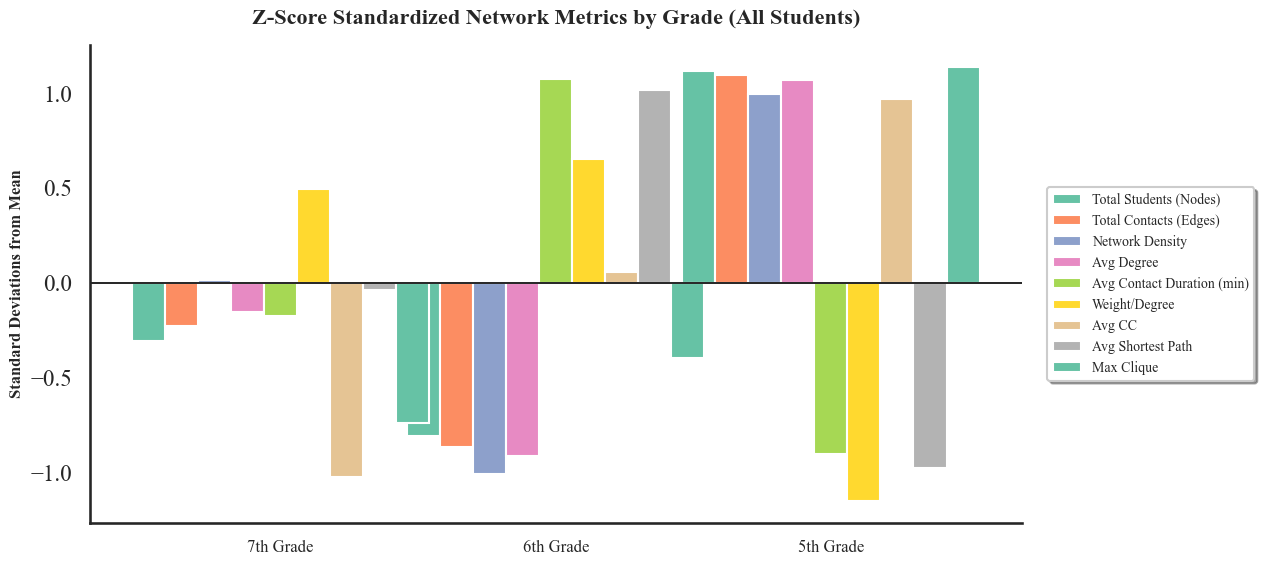

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Z-score normalize so all metrics are on the same scale
df_zscore_all = (df_network_metrics_all - df_network_metrics_all.mean()) / df_network_metrics_all.std()

# Shorten column names for the legend
col_rename = {
    'Number of Edges':            'Edges',
    'Avg Degree':                 'Avg Degree',
    'Avg Clustering Coefficient': 'Avg CC',
    'Avg Duration (min)':         'Avg Duration',
    'Avg Shortest Path':          'Avg Shortest Path',
    'Max Clique Size':            'Max Clique'
}
df_zscore_all = df_zscore_all.rename(columns=col_rename)

# --- Plot ---
grades    = df_zscore_all.index.tolist()
metrics   = df_zscore_all.columns.tolist()
x         = np.arange(len(grades))
bar_width = 0.12
colors    = sns.color_palette('Set2', n_colors=len(metrics))

fig, ax = plt.subplots(figsize=(13, 6))

for i, (col, color) in enumerate(zip(metrics, colors)):
    offset = (i - len(metrics) / 2) * bar_width + bar_width / 2
    ax.bar(x + offset, df_zscore_all[col], width=bar_width, label=col, color=color)

ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Z-Score Standardized Network Metrics by Grade (All Students)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Standard Deviations from Mean', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(grades, fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(prop={'size': 10}, loc='center left', bbox_to_anchor=(1.02, 0.5),
          frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('figures/network_metrics_zscore_all.png', dpi=300)
plt.show()


### Comparative Graph-Level Metrics: Z-Score Normalized View

This visualization provides a standardized comparison of key network properties across the three grade levels. Because the raw metrics (such as the total number of edges versus the average clustering coefficient) operate on fundamentally different scales, we apply **Z-score normalization** to bring them onto a single comparable axis.

Each grouping on the X-axis represents a core network metric, while the bars indicate how many standard deviations a specific grade sits above or below the inter-grade average. Bars extending above the **zero-line** denote above-average performance for that metric, while bars below indicate below-average performance. This comparative approach allows us to immediately identify which grades exhibit unique structural strengths, such as higher connectivity (Avg Degree) or greater network density (Avg CC), relative to the entire cohort.


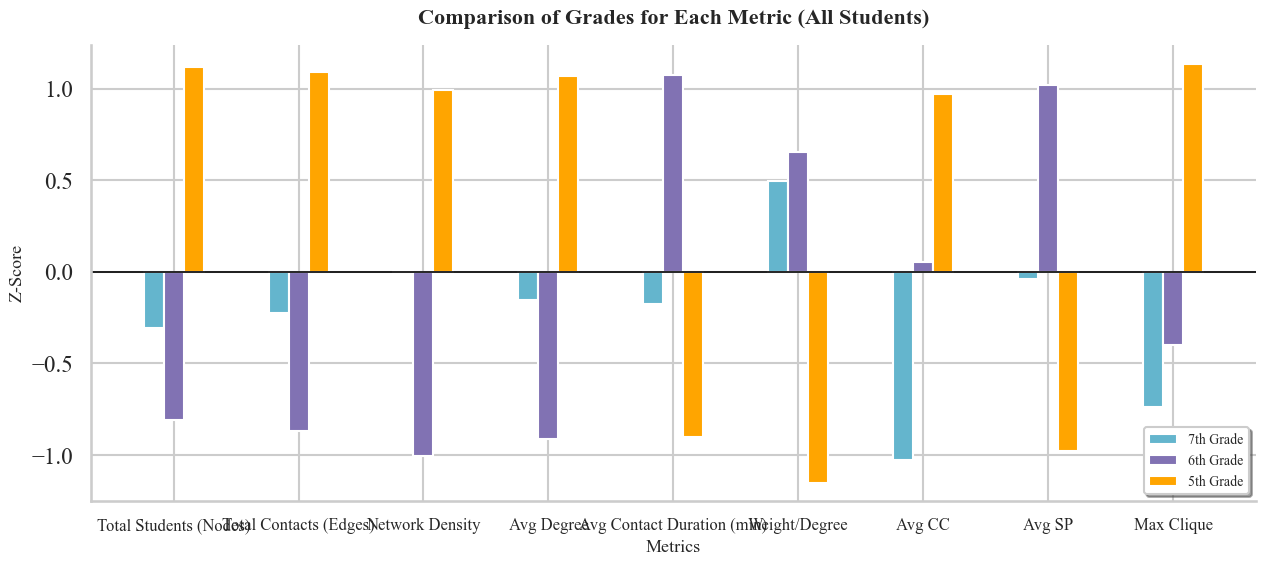

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Shorten column names
col_rename = {
    'Number of Edges':            'Edges',
    'Avg Degree':                 'Avg Degree',
    'Avg Clustering Coefficient': 'Avg CC',
    'Avg Duration (min)':         'Avg Duration',
    'Avg Shortest Path':          'Avg SP',
    'Max Clique Size':            'Max Clique'
}
df_plot = df_network_metrics_all.rename(columns=col_rename)

# Z-score normalize
df_zscore = (df_plot - df_plot.mean()) / df_plot.std()

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(13, 6))

bar_width = 0.16
index  = np.arange(len(df_zscore.columns))   # one group per metric
grades = df_zscore.index.tolist()
colors = ['c', 'm', 'orange']

for i, (grade, color) in enumerate(zip(grades, colors)):
    ax.bar(index + i * bar_width, df_zscore.loc[grade],
           width=bar_width, label=grade, color=color)

ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Comparison of Grades for Each Metric (All Students)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Metrics', fontsize=13)
ax.set_ylabel('Z-Score', fontsize=13)
ax.set_xticks(index + bar_width)
ax.set_xticklabels(df_zscore.columns, fontsize=12)
ax.set_ylim(min(df_zscore.min().min() - 0.1, 0),
            max(df_zscore.max().max() + 0.1, 0))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(prop={'size': 10}, loc='lower right', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('figures/network_metrics_zscore_by_metric_all.png', dpi=300)
plt.show()


### Node-Level Metrics: Weight and Degree Correlation by Grade

This visualization displays the relationship between **Total Contact Duration (Weights)** and the **Number of Unique Contacts (Degree)** for every individual student across the three grade levels. By plotting these metrics on a dual-axis line chart, we can assess the correlation between interaction volume (time) and interaction diversity (degree).

The **left Y-axis (red)** represents the cumulative time spent in contact, while the **right Y-axis (blue)** represents the count of distinct individuals encountered. The synchronized fluctuations between the lines indicate that internal network connectivity is generally consistent: students who engage with a larger variety of peers also tend to accumulate higher total contact time. This chart is generated directly from the `all_metrics` dataset, providing a granular view of individual social behavior within each grade's baseline network.


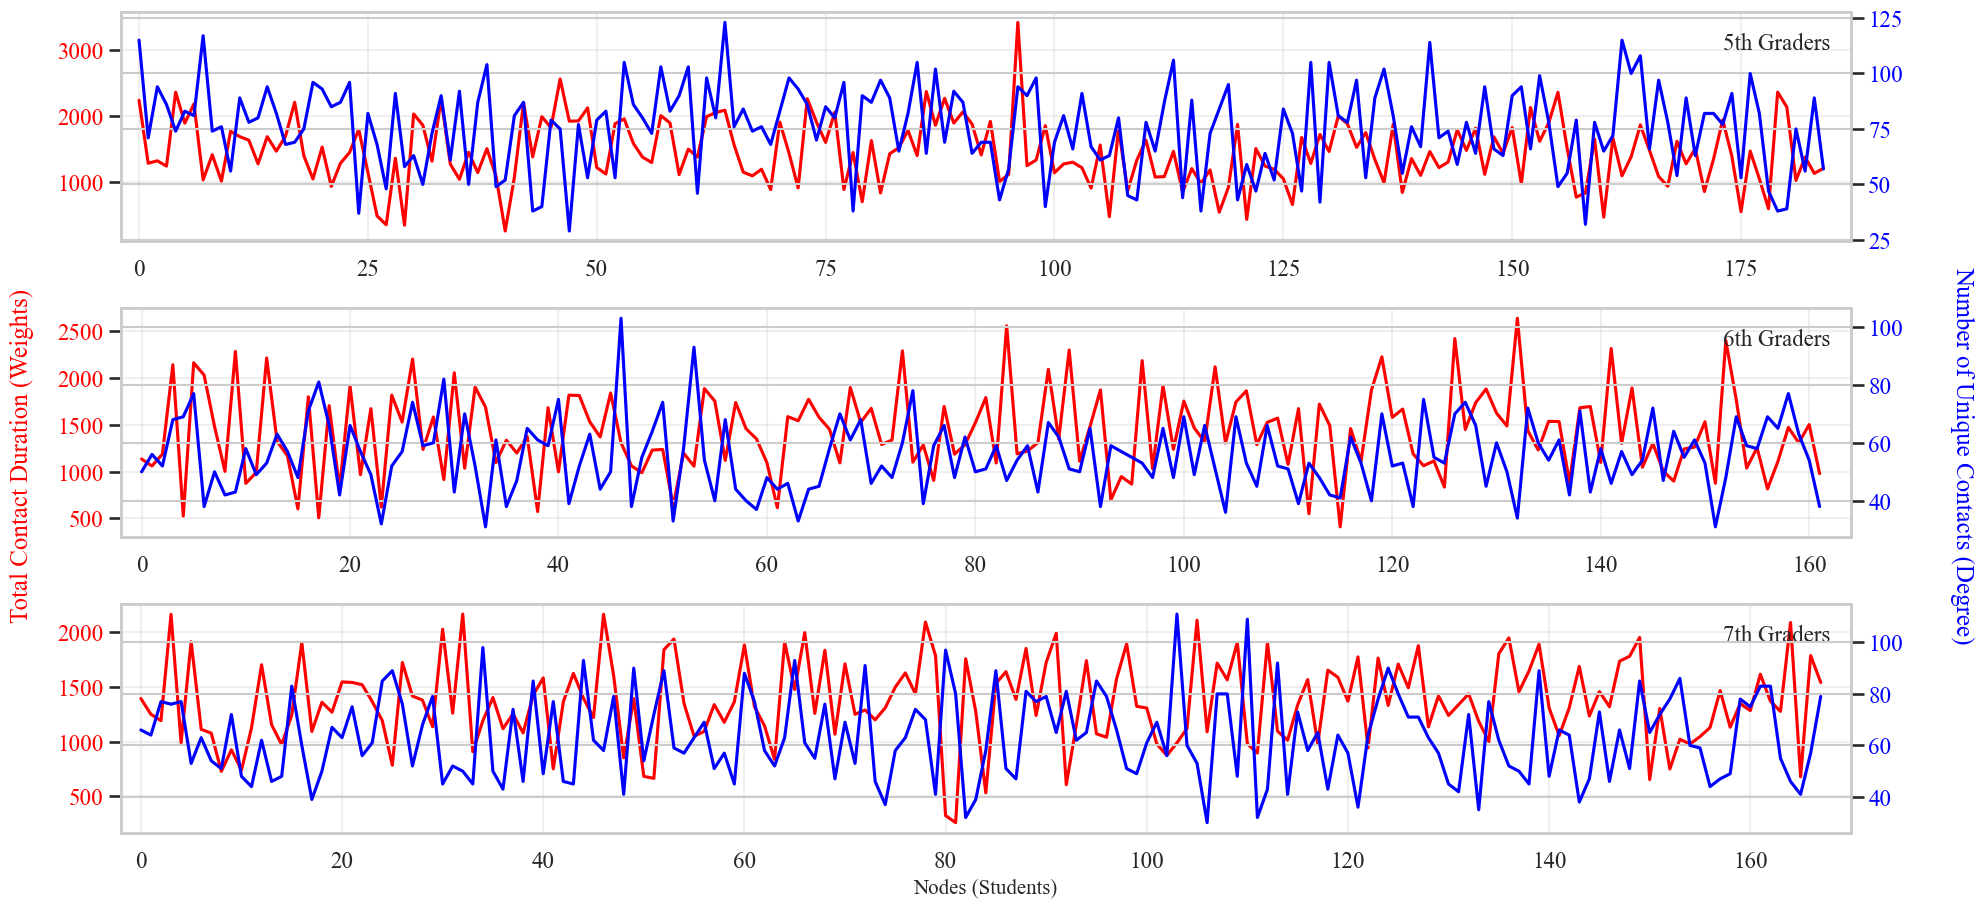

In [66]:
import matplotlib.pyplot as plt

# 1. Setup the figure with 3 stacked subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

# 2. Define the grades we want to plot (matching the labels in all_metrics)
grades = ['5th Grade', '6th Grade', '7th Grade']
colors = {'weights': 'red', 'degree': 'blue'}

for i, grade in enumerate(grades):
    # Filter data for the specific grade
    df_grade = all_metrics[all_metrics['Grade'] == grade]
    
    # Plot 'weights' on the primary (left) Y-axis
    axs[i].plot(df_grade['weights'].values, label=f'{grade}rs', color=colors['weights'])
    axs[i].set_xlim(-2, len(df_grade) + 2)
    axs[i].tick_params(axis='y', labelcolor=colors['weights'])
    axs[i].grid(True, alpha=0.3)
    axs[i].legend(loc='upper right', frameon=False, handlelength=0)
    
    # Create the twin (right) Y-axis for 'degree'
    ax_twin = axs[i].twinx()
    ax_twin.plot(df_grade['degree'].values, color=colors['degree'])
    ax_twin.tick_params(axis='y', labelcolor=colors['degree'])

# 3. Add styling and global labels
axs[2].set_xlabel('Nodes (Students)', fontsize=15)
fig.text(0.01, 0.5, 'Total Contact Duration (Weights)', va='center', rotation='vertical', fontsize=18, color=colors['weights'])
fig.text(0.98, 0.5, 'Number of Unique Contacts (Degree)', va='center', rotation=-90, fontsize=18, color=colors['degree'])

plt.tight_layout(rect=[0.02, 0.03, 0.97, 0.97])
plt.savefig('figures/weight_degree_correlation_by_grade.png', dpi=300)
plt.show()


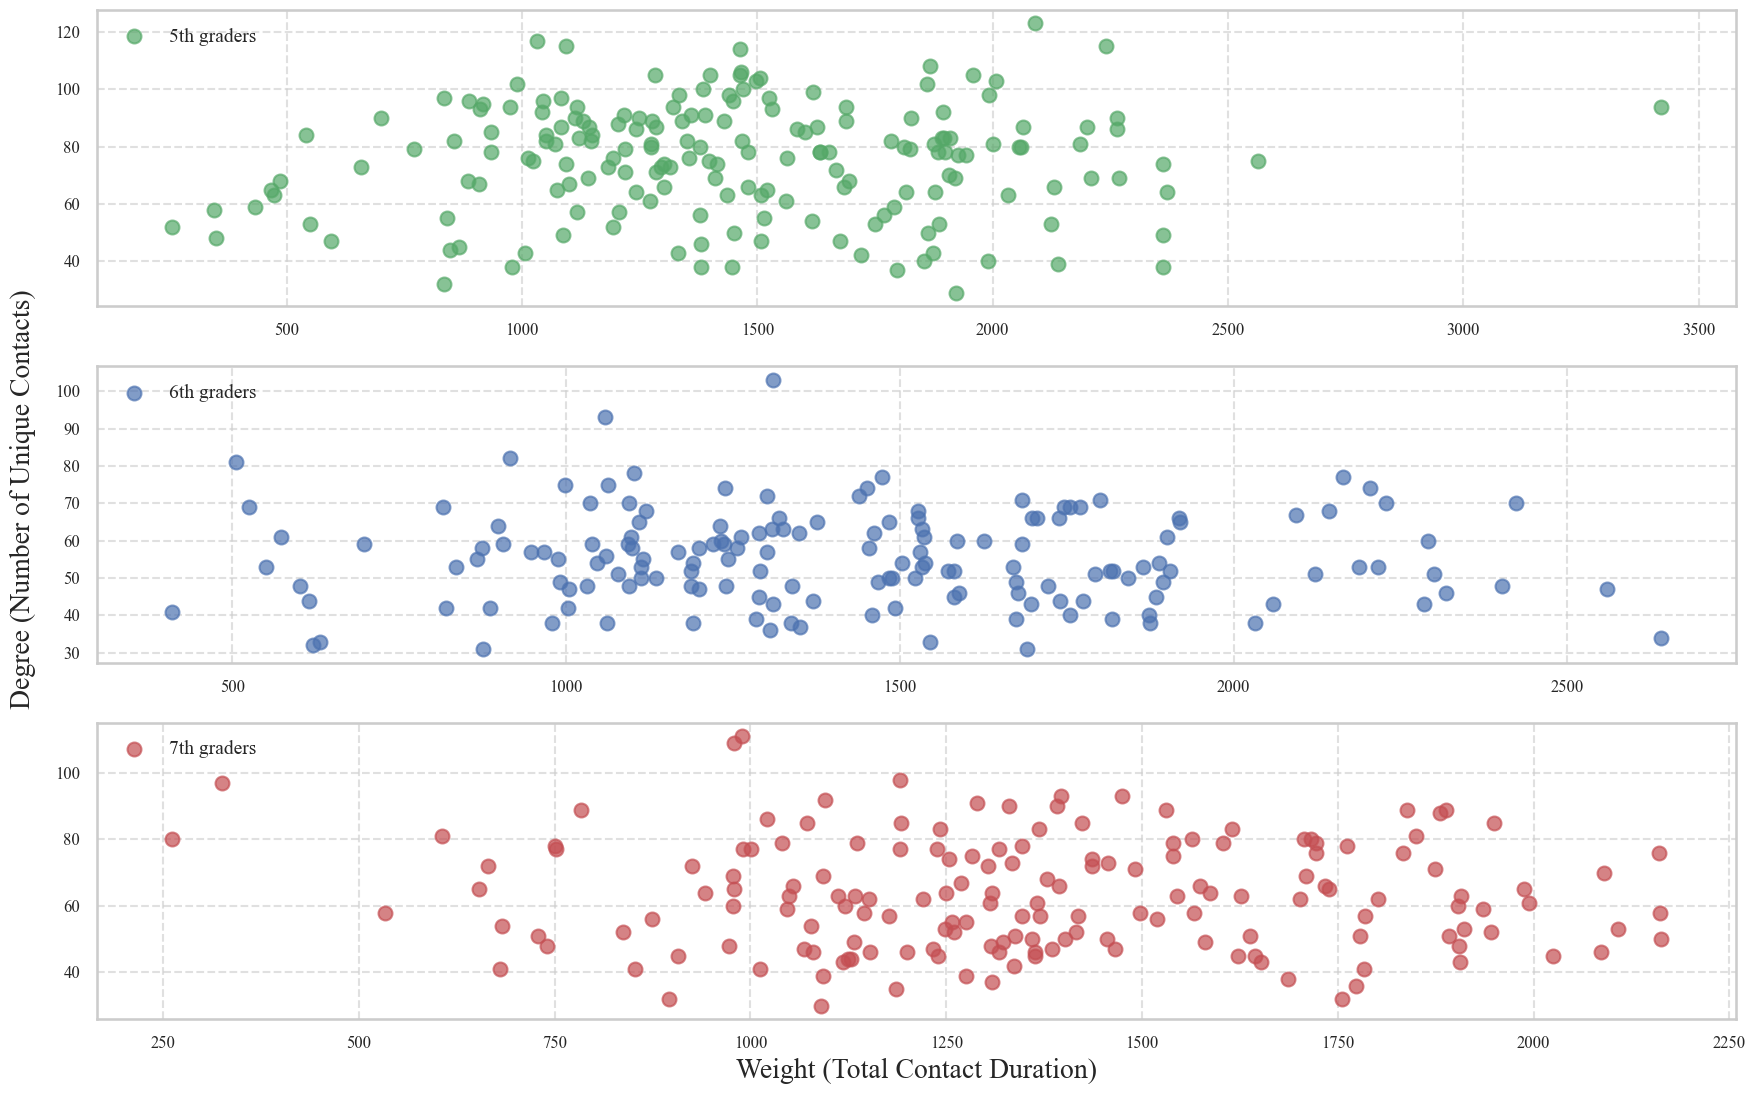

In [67]:
import matplotlib.pyplot as plt

# 1. Setup the figure with 3 subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 12))

# 2. Configuration for grades and colors
grades_map = {
    '5th Grade': {'label': '5th graders', 'color': 'g'},
    '6th Grade': {'label': '6th graders', 'color': 'b'},
    '7th Grade': {'label': '7th graders', 'color': 'r'}
}

# 3. Iterate through grades and plot
for i, grade_key in enumerate(grades_map.keys()):
    # Filter all_metrics for specific grade
    df_grade = all_metrics[all_metrics['Grade'] == grade_key]
    cfg = grades_map[grade_key]
    
    # Scatter plot: X = weights, Y = degree
    axs[i].scatter(df_grade['weights'], df_grade['degree'], 
                   label=cfg['label'], color=cfg['color'], s=100, alpha=0.7)
    
    # Styling
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].legend(loc='upper left', frameon=False, fontsize=14)
    axs[i].tick_params(axis='both', which='major', labelsize=12)

# 4. Global labels and layout
axs[2].set_xlabel('Weight (Total Contact Duration)', fontsize=20)
fig.text(0.02, 0.54, 'Degree (Number of Unique Contacts)', 
         va='center', rotation='vertical', fontsize=20)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
plt.savefig('figures/weight_degree_scatter_by_grade.png', dpi=300)
plt.show()


### Joint Distribution Analysis: Social Intensity and Diversity

This **Joint Plot** provides a comprehensive multi-dimensional view of how social interaction manifests across the three grade levels. By combining a central scatter plot with marginal distribution curves, we can simultaneously observe the **correlation** between individual metrics and the **concentration** of behaviors within each cohort.

#### **Data Interpretation:**

1.  **Correlation Intensity (Central Plot):**  
    The clear diagonal clustering of points across all grades confirms a strong positive correlation between **Degree** and **Weights**. This tells a story of "Social Scalability": as students interaction with more unique peers (higher diversity), they don't necessarily reduce the quality of time spent; rather, their total cumulative contact time increases proportionally.

2.  **Breadth of Interaction (Top Marginal Plot - Weights):**  
    The top distribution curve illustrates the "social endurance" of each grade. A shift to the right in these curves indicates a cohort that prioritizes longer-duration contacts. By observing the overlap, we can identify which grade tends to stay in proximity for longer periods versus those whose interactions are more frequent but brief.

3.  **Social Reach (Right Marginal Plot - Degree):**  
    The vertical distribution shows the range of social reach. Narrow, tall peaks suggest a highly uniform social experience within that grade (most students have a similar number of contacts). In contrast, broad or multi-modal peaks reveal social stratification—a network composed of both highly connected "hubs" and more isolated individuals.

4.  **Grade Clustering:**  
    The visual separation or overlap between the colors (`husl` palette) allows us to see if different grades occupy different "social zones." If one grade's cluster is positioned higher and further right, it indicates a significantly more socio-active environment compared to the others, potentially reflecting different developmental stages or classroom physical layouts.


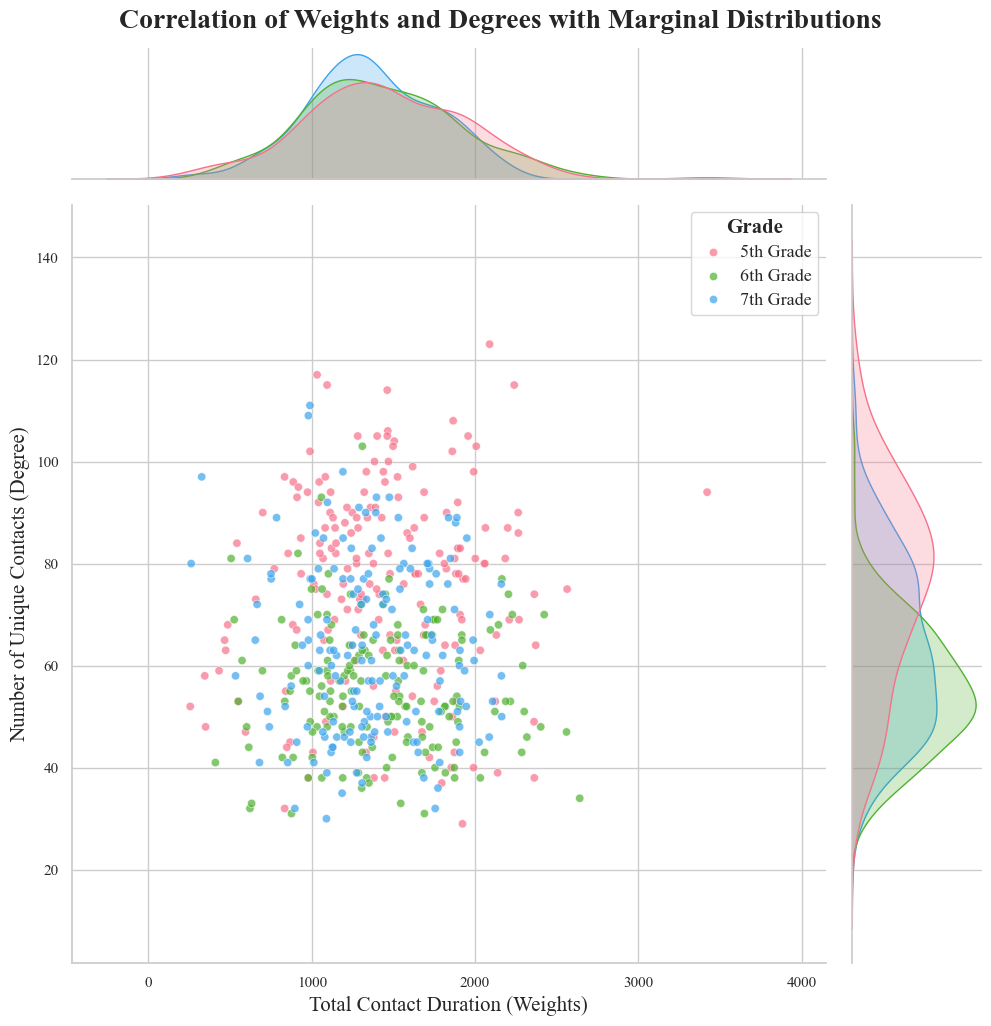

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the theme and font
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Times New Roman"

# 2. Create the joint plot
# x='weights' and y='degree' from our consolidated all_metrics table
g = sns.jointplot(
    data=all_metrics, 
    x='weights', 
    y='degree', 
    hue='Grade', 
    kind='scatter', 
    palette='husl', 
    height=10, 
    alpha=0.7,
    marginal_kws={'fill': True, 'common_norm': False}
)

# 3. Titles and Axis Labels
g.fig.suptitle('Correlation of Weights and Degrees with Marginal Distributions', 
               fontsize=20, fontweight='bold', y=1.02)
g.set_axis_labels('Total Contact Duration (Weights)', 'Number of Unique Contacts (Degree)', 
                   fontsize=15)

# 4. Refine Legend
plt.setp(g.ax_joint.get_legend().get_texts(), fontsize=13) 
plt.setp(g.ax_joint.get_legend().get_title(), fontsize=15, fontweight='bold')

plt.savefig('figures/joint_plot_weights_degree.png', dpi=300, bbox_inches='tight')
plt.show()


### Comparative Social Connectivity: Weight vs. Degree across Grade Levels

This series of side-by-side scatter plots provides a direct comparison of social behavior patterns across the three grade levels. By isolating each grade into its own panel while maintaining a shared Y-axis (**Degree**), we can visually assess the "social footprint" of each cohort.

#### **Key Analytical Insights:**

*   **Cluster Density & Dispersion:** These plots reveal how social roles are distributed within each grade. A tight, concentrated cluster suggests a high degree of social uniformity among students, whereas a more dispersed cloud (common in higher grades) indicates social stratification—the coexistence of highly active social "hubs" and more peripheral individuals.
*   **Social Scaling:** The positive diagonal slope across all three panels confirms a consistent structural property of the student networks: **Contact Duration (Weights)** scales predictably with **Contact Diversity (Degree)**. This indicates that as students expand their social circle, they tend to increase their cumulative interaction time rather than spreading a fixed amount of time more thinly.
*   **Cross-Grade Comparison:** By aligning the plots horizontally, it becomes easy to identify shifts in social capacity. We can observe whether the maximum degree reached by 7th graders exceeds that of 5th graders, potentially reflecting changes in social maturity, spatial movement, or longer-duration interactions as students age.

This visualization is built upon the consolidated `all_metrics` dataset, ensuring that the individual points and trends observed here are mathematically identical to those analyzed in our earlier statistical representations.


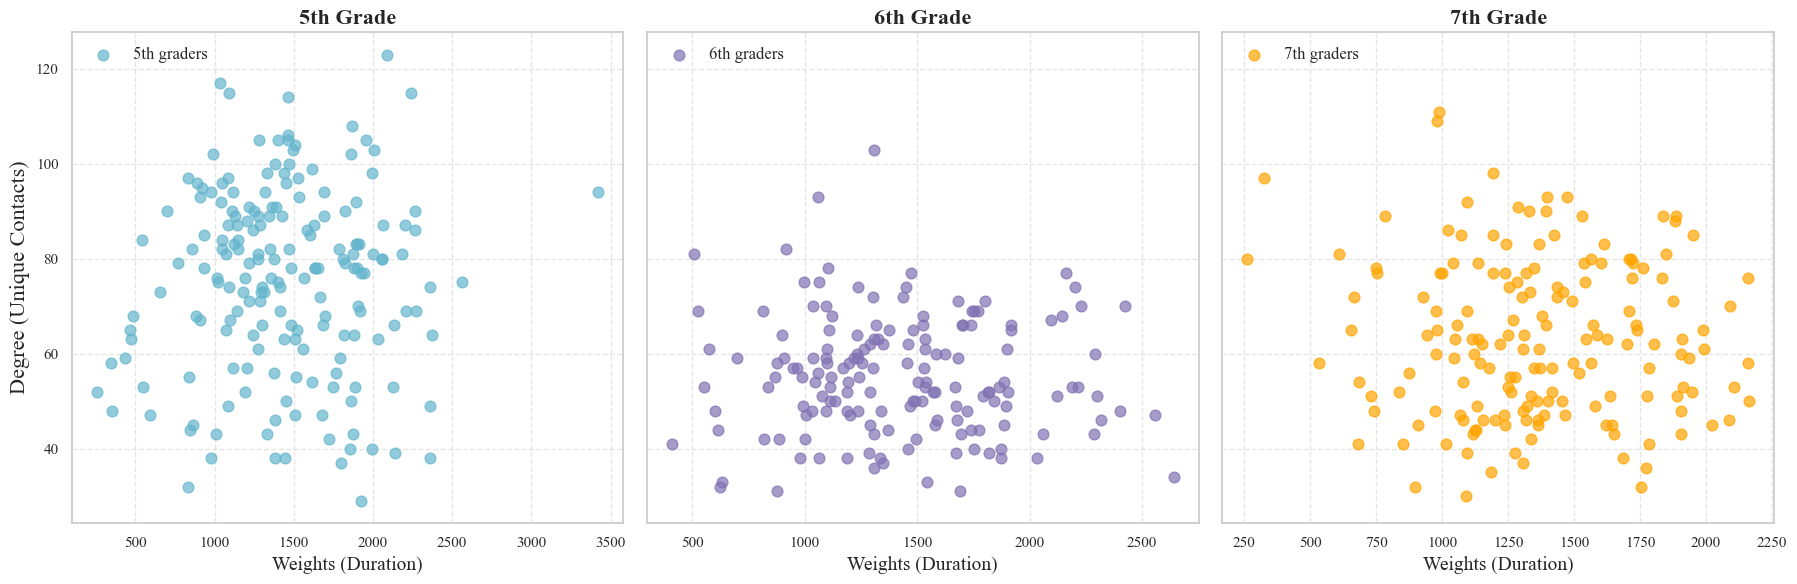

In [69]:
import matplotlib.pyplot as plt

# 1. Setup the figure with 3 side-by-side subplots
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# 2. Configuration for grades and colors
grades_config = [
    {'name': '5th Grade', 'label': '5th graders', 'color': 'c'},
    {'name': '6th Grade', 'label': '6th graders', 'color': 'm'},
    {'name': '7th Grade', 'label': '7th graders', 'color': 'orange'}
]

# 3. Iterate and plot each grade in its own panel
for i, cfg in enumerate(grades_config):
    # Filter data for the specific grade
    df_grade = all_metrics[all_metrics['Grade'] == cfg['name']]
    
    # Scatter plot: X = weights, Y = degree
    axs[i].scatter(df_grade['weights'], df_grade['degree'], 
                   label=cfg['label'], color=cfg['color'], s=60, alpha=0.7)
    
    # Chart styling
    axs[i].set_title(cfg['name'], fontsize=16, fontweight='bold')
    axs[i].grid(True, linestyle='--', alpha=0.5)
    axs[i].legend(loc='upper left', frameon=False, fontsize=12)
    axs[i].set_xlabel('Weights (Duration)', fontsize=14)

# 4. Global labels and layout adjustment
axs[0].set_ylabel('Degree (Unique Contacts)', fontsize=16)
plt.tight_layout()

plt.savefig('figures/weight_degree_horizontal_comparison.png', dpi=300)
plt.show()


### **Social Strategy Analysis: Diversity vs. Interaction Intensity**

This analysis evaluates the "Social Strategy" of students by comparing their **Social Diversity (Degree)** against their **Interaction Intensity (Average Duration per Contact)**. By calculating the average time spent per unique contact, we can distinguish between different networking styles across grade levels.

#### **Analytical Insights:**

1.  **The Diversity-Intensity Trade-off:**  
    The linear regression lines (fitted via `sns.lmplot`) illustrate how average interaction quality scales with quantity. 
    *   **Negative Slope:** Indicates a "Social Butterfly" pattern—as students interact with more unique peers, the average time they can dedicate to each individual decreases.
    *   **Flat/Positive Slope:** Indicates a "High Capacity" pattern—students are able to maintain (or even increase) their interaction intensity even as their social circle expands.

2.  **Cohort Behavioral Trends:**  
    The vertical height and slope of each grade's regression line reveal their specific social dynamics. For example, a grade with a higher starting point but a steeper decline suggests that students start with very intense relationships but quickly sacrifice that intensity to reach a broader audience.

3.  **Statistical Consistency:**  
    The semi-transparent "shadow" around each line represents the confidence interval. A narrow shadow suggests a highly consistent social strategy within that grade, while a wider shadow indicates a greater variety of individual behaviors and social roles (from social coordinators to concentrated socializers).

This visualization shifts the focus from raw total duration to **quality-of-time**, providing a deeper understanding of how social energy is budgeted within each network.


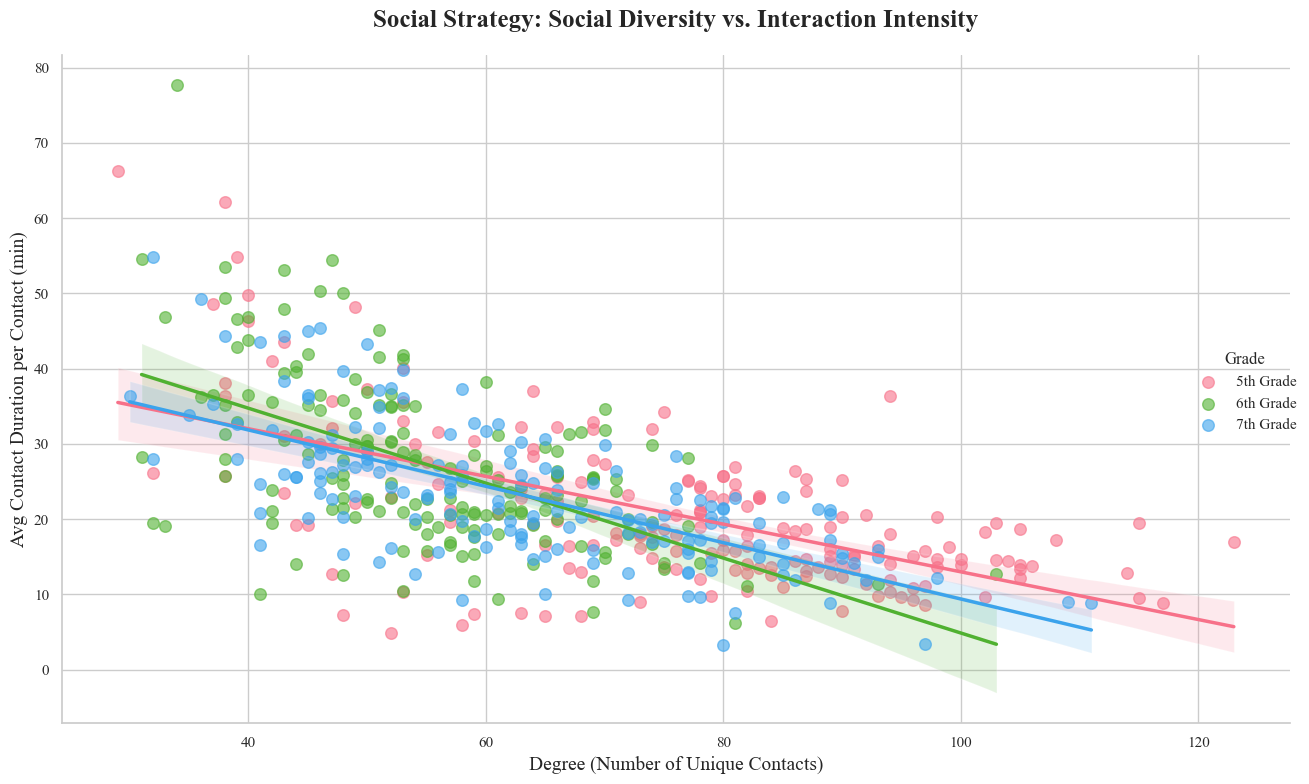

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Average Contact Duration per student
all_metrics['avg_contact_duration'] = all_metrics['weights'] / all_metrics['degree']
all_metrics['avg_contact_duration'] = all_metrics['avg_contact_duration'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Shared aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Times New Roman"

# 3. Create the Linear Regression Plot (Fixed alpha parameter)
g = sns.lmplot(
    data=all_metrics,
    x='degree',
    y='avg_contact_duration',
    hue='Grade',
    aspect=1.5,
    height=8,
    scatter_kws={'s': 70, 'alpha': 0.6}, # Alpha moved here
    line_kws={'linewidth': 2.5},
    palette='husl'
)

# 4. Customizing Labels and Title
plt.xlabel('Degree (Number of Unique Contacts)', fontsize=14)
plt.ylabel('Avg Contact Duration per Contact (min)', fontsize=14)
plt.title('Social Strategy: Social Diversity vs. Interaction Intensity', 
          fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('figures/social_strategy_regression_plot.png', dpi=300)
plt.show()


In [71]:
import numpy as np
import pandas as pd
import powerlaw

# 1. Configuration (using the dataframes for all students)
grades_data = {
    '5th Grade': student_contacts5,
    '6th Grade': student_contacts6,
    '7th Grade': student_contacts7,
}

print("==================================================")
print("ANALYZING DURATIONS >= 4 SECONDS FOR ALL STUDENTS")
print("==================================================")

for label, df in grades_data.items():
    # Filter to durations >= 4 seconds
    filtered_df = df[df['duration'] >= 4].copy()
    durations = filtered_df['duration'].values
    
    # 1. Calculate Mean, SD, and Coefficient of Variation (CV)
    mean_val = durations.mean()
    std_val = durations.std()
    cv_val = std_val / mean_val
    
    print(f"\n--- {label} ---")
    print(f"Total contacts (>= 4s): {len(durations)}")
    print(f"Mean duration: {mean_val:.2f} seconds")
    print(f"Standard deviation: {std_val:.2f} seconds")
    print(f"Coefficient of Variation (CV): {cv_val:.3f} ({cv_val * 100:.1f}%)")
    
    # 2. Fit the Power-Law Distribution
    # fit.alpha is the scaling parameter (beta)
    # fit.xmin is the optimal cutoff threshold
    fit = powerlaw.Fit(durations, discrete=True)
    print(f"Power-law Exponent (beta): {fit.alpha:.3f}")
    print(f"Optimal x_min: {fit.xmin:.1f} seconds")
    print(f"Kolmogorov-Smirnov distance (D): {fit.D:.4f}")
    
    # 3. Compare Distributions using Vuong Likelihood Ratio Test
    # R is the loglikelihood ratio. Positive R = first distribution is better; Negative R = second is better.
    # p-value is the significance of the ratio.
    R_ln, p_ln = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)
    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
    
    print(f"Vuong Test (Power-law vs Lognormal):   R = {R_ln:.4f}, p-value = {p_ln:.4f}")
    print(f"Vuong Test (Power-law vs Exponential): R = {R_exp:.4f}, p-value = {p_exp:.4f}")


ANALYZING DURATIONS >= 4 SECONDS FOR ALL STUDENTS

--- 5th Grade ---
Total contacts (>= 4s): 105251
Mean duration: 76.11 seconds
Standard deviation: 245.26 seconds
Coefficient of Variation (CV): 3.222 (322.2%)
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 1912/1912 [00:02<00:00, 739.22it/s]
/Users/tanyaniazi/Desktop/TUBITAK-RELATED/.venv/lib/python3.13/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Power-law Exponent (beta): 1.916
Optimal x_min: 33.0 seconds
Kolmogorov-Smirnov distance (D): 0.0168
Vuong Test (Power-law vs Lognormal):   R = -11.4961, p-value = 0.0000
Vuong Test (Power-law vs Exponential): R = 61.5112, p-value = 0.0000

--- 6th Grade ---
Total contacts (>= 4s): 73513
Mean duration: 93.90 seconds
Standard deviation: 272.83 seconds
Coefficient of Variation (CV): 2.905 (290.5%)
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 1819/1819 [00:01<00:00, 992.14it/s] 
/Users/tanyaniazi/Desktop/TUBITAK-RELATED/.venv/lib/python3.13/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Power-law Exponent (beta): 1.804
Optimal x_min: 27.0 seconds
Kolmogorov-Smirnov distance (D): 0.0236
Vuong Test (Power-law vs Lognormal):   R = -16.8094, p-value = 0.0000
Vuong Test (Power-law vs Exponential): R = 63.2353, p-value = 0.0000

--- 7th Grade ---
Total contacts (>= 4s): 78864
Mean duration: 86.66 seconds
Standard deviation: 252.57 seconds
Coefficient of Variation (CV): 2.915 (291.5%)
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 1812/1812 [00:02<00:00, 884.86it/s]


Power-law Exponent (beta): 1.806
Optimal x_min: 32.0 seconds
Kolmogorov-Smirnov distance (D): 0.0319
Vuong Test (Power-law vs Lognormal):   R = -20.5426, p-value = 0.0000
Vuong Test (Power-law vs Exponential): R = 52.5534, p-value = 0.0000


/Users/tanyaniazi/Desktop/TUBITAK-RELATED/.venv/lib/python3.13/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


In [72]:
import numpy as np
import powerlaw
import warnings
warnings.filterwarnings('ignore') # Suppress edge warning messages during fits

def calculate_ks_p_value(durations, num_simulations=100):
    """
    Computes the Clauset et al. (2009) bootstrap p-value for the power-law fit.
    
    A p-value > 0.1 indicates the power-law is a plausible hypothesis for the tail.
    A p-value < 0.1 rejects the power-law hypothesis.
    """
    # 1. Fit empirical data to get optimal parameters
    print("Fitting empirical data...")
    fit_emp = powerlaw.Fit(durations, discrete=True)
    D_emp = fit_emp.D
    xmin = fit_emp.xmin
    alpha = fit_emp.alpha
    
    print(f"Empirical Optimal xmin: {xmin:.1f} seconds")
    print(f"Empirical scaling exponent (beta): {alpha:.4f}")
    print(f"Empirical KS distance (D): {D_emp:.4f}")
    
    # Split empirical data into body (below xmin) and tail (above/equal to xmin)
    durations_below = durations[durations < xmin]
    durations_above = durations[durations >= xmin]
    
    n_total = len(durations)
    n_above = len(durations_above)
    prob_above = n_above / n_total
    
    successes = 0
    print(f"\nRunning {num_simulations} bootstrap simulations...")
    
    for i in range(num_simulations):
        # Determine how many simulated samples belong to the tail vs. body
        n_sim_above = np.random.binomial(n_total, prob_above)
        n_sim_below = n_total - n_sim_above
        
        # Resample the body from empirical observations below xmin
        if n_sim_below > 0 and len(durations_below) > 0:
            body_samples = np.random.choice(durations_below, size=n_sim_below, replace=True)
        else:
            body_samples = np.array([])
            
        # Draw tail samples from the theoretical power law model
        if n_sim_above > 0:
            tail_generator = powerlaw.Power_Law(xmin=xmin, parameters=[alpha], discrete=True)
            tail_samples = tail_generator.generate_random(n_sim_above)
        else:
            tail_samples = np.array([])
            
        # Combine body and simulated tail
        sim_data = np.concatenate([body_samples, tail_samples])
        
        # Fit power law to simulated data (finding its own optimal parameters)
        try:
            fit_sim = powerlaw.Fit(sim_data, discrete=True, verbose=False)
            if fit_sim.D >= D_emp:
                successes += 1
        except Exception:
            pass
            
        # Print progress update
        if (i + 1) % 10 == 0:
            print(f" Completed {i + 1}/{num_simulations} simulations...")
            
    p_val = successes / num_simulations
    print(f"\n--- Results ---")
    print(f"Bootstrap KS p-value: {p_val:.4f}")
    return p_val


In [73]:
# # To test 7th Grade:
# filtered_df = student_contacts7[student_contacts7['duration'] >= 4].copy()
# durations = filtered_df['duration'].values

# calculate_ks_p_value(durations, num_simulations=50)


⚠️ Power-law Bootstrap Simulation (Time-Intensive)
The cell below runs 1,000 bootstrap simulations for all three grades. To execute it, uncomment all lines of code in the cell below (select all code in the cell and press Cmd + / on Mac or Ctrl + / on Windows).

In [74]:
# from utils import calculate_ks_p_value_parallel

# # 1. Define the datasets for each grade
# grades_contacts = {
#     '5th Grade': student_contacts5,
#     '6th Grade': student_contacts6,
#     '7th Grade': student_contacts7,
# }

# # Dictionary to store the final p-values
# bootstrap_results = {}

# # 2. Loop through each grade and calculate the bootstrap KS p-value
# for label, df in grades_contacts.items():
#     print("=" * 65)
#     print(f"RUNNING PARALLEL BOOTSTRAP FOR {label.upper()} (1000 SIMULATIONS)")
#     print("=" * 65)
    
#     # Filter to durations >= 4 seconds
#     filtered_df = df[df['duration'] >= 4].copy()
#     durations = filtered_df['duration'].values
    
#     # Run the parallel bootstrap
#     p_val = calculate_ks_p_value_parallel(durations, num_simulations=1000)
#     bootstrap_results[label] = p_val
#     print("\n")

# # 3. Print the final summary table
# print("=" * 65)
# print("FINAL SUMMARY: BOOTSTRAP KS P-VALUES")
# print("=" * 65)
# for label, p_val in bootstrap_results.items():
#     print(f"{label}: p-value = {p_val:.4f} " + ("(PL tail accepted)" if p_val >= 0.1 else "(PL tail rejected)"))


### Summary of Contact Duration Distribution Fitting

The contact duration data across all three grades exhibits highly heterogeneous, heavy-tailed profiles, as evidenced by the high Coefficients of Variation ($CV \approx 3.0$) and the strong rejection of the exponential model ($p < 0.001$). Although the power-law scaling exponent ($\beta \approx 1.8$ to $1.9$) describes the tail decay above $x_{\text{min}} \approx 30$ seconds, the bootstrap KS test rejects a pure power-law model ($p = 0.0000$ for all grades). Instead, Vuong's likelihood ratio test significantly favors the **lognormal distribution** ($R < 0, p < 0.001$), which serves as a statistically superior fit for the entire range of contact durations.

#### Table 2: Statistical properties and distribution fitting results of student contact durations (durations $\ge 4$ seconds).

| Metric | 5th Grade | 6th Grade | 7th Grade |
| :--- | :---: | :---: | :---: |
| **Empirical Statistics** | | | |
| Total Contacts ($N$) | 105,251 | 73,513 | 78,864 |
| Mean Duration (s) | 76.11 | 93.90 | 86.66 |
| Std. Dev. (s) | 245.26 | 272.83 | 252.57 |
| Coeff. of Variation ($CV$) | 3.222 | 2.905 | 2.915 |
| **Power-law Fit Parameters** | | | |
| Optimal threshold $x_{\text{min}}$ (s) | 33.0 | 27.0 | 32.0 |
| Scaling Exponent ($\beta$) | 1.916 | 1.804 | 1.806 |
| KS Distance ($D$) | 0.0168 | 0.0236 | 0.0319 |
| Bootstrap KS $p$-value (1000 runs) | **0.0000** | **0.0000** | **0.0000** |
| **Model Comparison (Vuong's Test)** | | | |
| vs. Exponential ($R$) | $61.511$ ($p < 0.001$) | $63.235$ ($p < 0.001$) | $52.553$ ($p < 0.001$) |
| vs. Lognormal ($R$) | $-11.496$ ($p < 0.001$) | $-16.809$ ($p < 0.001$) | $-20.543$ ($p < 0.001$) |

*Note: A positive $R$ value indicates the data is better described by the power-law model, whereas a negative $R$ value indicates the alternative model (Lognormal or Exponential) is a superior fit.*


### **Degree Distribution: Comparative Density Analysis**

This visualization uses **Kernel Density Estimation (KDE)** to show the probability distribution of student degrees across the three grade levels. Unlike a simple histogram, the KDE provides a smooth curve that allows for easy comparison of where "most" students sit in terms of social connectivity.

#### **Analytical Insights & Key Stats:**

*   **Peak Position (Mode):** The peak of each curve represents the most frequent number of unique contacts for that grade. A horizontal shift in the peaks indicates a change in the "baseline" social activity. For example, a shift to the right in 5th Grade suggests that younger students generally maintain a higher volume of unique interactions compared to their older peers.
*   **Curve Width (Standard Deviation):** 
    *   **Narrow Peaks:** Indicate high social uniformity—most students interact with a very similar number of people. 
    *   **Broad Peaks:** Suggest higher social variance—the cohort is divided between highly integrated individuals and those with much smaller circles.
*   **Statistical Breakdown:** 
    *   **Mean:** The average number of unique contacts per person.
    *   **Std (Standard Deviation):** The amount of variation or "spread" in the social connectivity within the grade.

By layering these distributions, we can immediately identify which grade occupies the most dense social environment and which shows the highest internal diversity in social behavior.


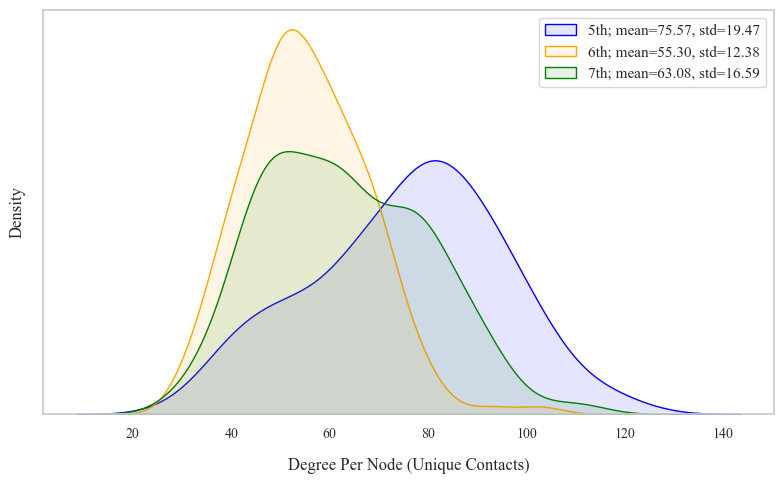

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the figure and global font
plt.figure(figsize=(8, 5))
plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="whitegrid")

# 2. Define colors and grade keys
grades_info = [
    {'key': '5th Grade', 'label': '5th', 'color': 'blue'},
    {'key': '6th Grade', 'label': '6th', 'color': 'orange'},
    {'key': '7th Grade', 'label': '7th', 'color': 'green'}
]

# 3. Plot each grade's distribution
for info in grades_info:
    # Filter the degree data for the specific grade
    deg_data = all_metrics[all_metrics['Grade'] == info['key']]['degree']
    
    # Calculate stats for the legend
    mean_val = deg_data.mean()
    std_val = deg_data.std()
    legend_text = f"{info['label']}; mean={mean_val:.2f}, std={std_val:.2f}"
    
    # Draw the KDE plot
    sns.kdeplot(deg_data, label=legend_text, color=info['color'], fill=True, alpha=0.1)

# 4. Styling and Labels (using Times New Roman)
plt.xlabel('Degree Per Node (Unique Contacts)', labelpad=12, fontsize=12, fontname='Times New Roman')
plt.ylabel('Density', labelpad=12, fontsize=12, fontname='Times New Roman')
# plt.title('Degree Distribution Analysis by Grade', fontsize=16, fontweight='bold', fontname='Times New Roman', y=1.05)

plt.grid(False)
plt.legend(prop={'family': 'Times New Roman', 'size': 11}, frameon=True)

# Set Times New Roman for ticks
plt.xticks(fontname='Times New Roman', fontsize=10)
plt.yticks([]) 

plt.tight_layout()
plt.savefig('figures/degree_distribution_kde.png', dpi=300, bbox_inches='tight')
plt.show()



7th Grade  (n=168, mean degree=63.1)
  Log-likelihood  Poisson:         -863.0
  Log-likelihood  Log-normal:      -707.4

6th Grade  (n=162, mean degree=55.3)
  Log-likelihood  Poisson:         -692.9
  Log-likelihood  Log-normal:      -634.2

5th Grade  (n=185, mean degree=75.6)
  Log-likelihood  Poisson:         -1051.4
  Log-likelihood  Log-normal:      -823.9


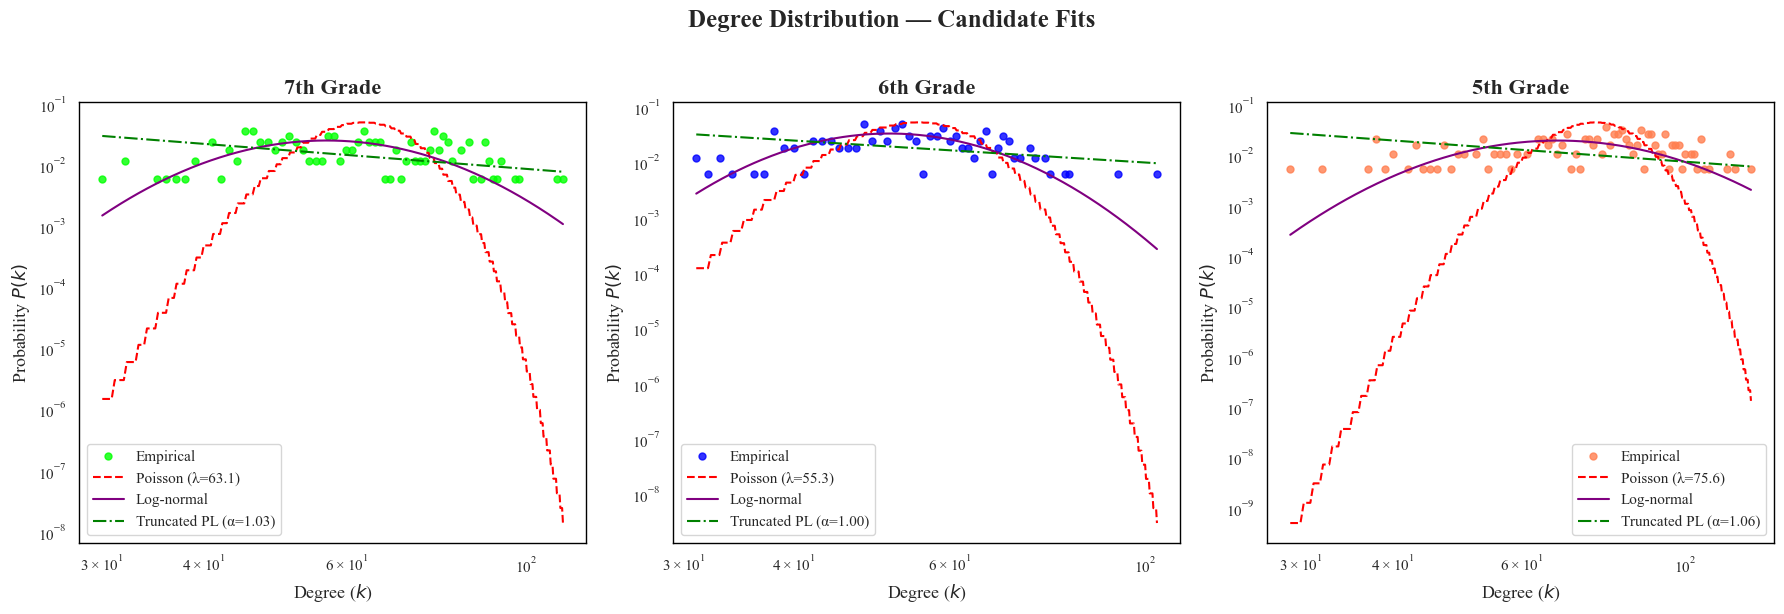

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "Times New Roman"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

grades_config = [
    {'g': g7_baseline_all, 'label': '7th Grade', 'color': 'lime', 'ax': axes[0]},
    {'g': g6_baseline_all, 'label': '6th Grade', 'color': 'blue',  'ax': axes[1]},
    {'g': g5_baseline_all, 'label': '5th Grade', 'color': 'coral', 'ax': axes[2]},
]

def power_law_cutoff(k, alpha, k_c):
    """Truncated power-law (power-law with exponential cutoff)."""
    return k**(-alpha) * np.exp(-k / k_c)

for cfg in grades_config:
    ax   = cfg['ax']
    g    = cfg['g']
    
    degrees = np.array(g.degree())
    degrees = degrees[degrees > 0]          # remove isolates just in case
    n       = len(degrees)

    # ── Empirical P(k) ───────────────────────────────────────────────────────
    counts  = pd.Series(degrees).value_counts().sort_index()
    k_vals  = counts.index.values.astype(float)
    p_vals  = counts.values / n

    ax.loglog(k_vals, p_vals, 'o', color=cfg['color'],
              markersize=5, alpha=0.8, label='Empirical')

    k_fit = np.linspace(k_vals.min(), k_vals.max(), 300)

    # ── 1. Poisson fit ───────────────────────────────────────────────────────
    lam = degrees.mean()
    p_poisson = stats.poisson.pmf(k_fit.astype(int), lam)
    ax.plot(k_fit, p_poisson, '--', color='red',    lw=1.5, label=f'Poisson (λ={lam:.1f})')

    # ── 2. Log-normal fit ────────────────────────────────────────────────────
    mu_ln  = np.log(degrees).mean()
    sig_ln = np.log(degrees).std()
    p_lognorm = stats.lognorm.pdf(k_fit, s=sig_ln, scale=np.exp(mu_ln))
    ax.plot(k_fit, p_lognorm, '-',  color='purple', lw=1.5, label=f'Log-normal')

    # ── 3. Truncated power-law fit ───────────────────────────────────────────
    try:
        popt, _ = curve_fit(power_law_cutoff, k_vals, p_vals,
                            p0=[1.5, k_vals.max()/2], maxfev=5000)
        p_trunc = power_law_cutoff(k_fit, *popt)
        ax.plot(k_fit, p_trunc, '-.',color='green',  lw=1.5,
                label=f'Truncated PL (α={popt[0]:.2f})')
    except Exception:
        pass   # skip if fit doesn't converge

    # ── Styling ──────────────────────────────────────────────────────────────
    ax.set_title(cfg['label'], fontsize=16, fontweight='bold')
    ax.set_xlabel('Degree ($k$)', fontsize=13)
    ax.set_ylabel('Probability $P(k)$', fontsize=13)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('black'); spine.set_linewidth(1)
    ax.legend(fontsize=9, prop={'family': 'Times New Roman'})
    ax.grid(False)

    # ── Print log-likelihoods ────────────────────────────────────────────────
    ll_pois   = np.sum(stats.poisson.logpmf(degrees.astype(int), lam))
    ll_lognorm= np.sum(stats.lognorm.logpdf(degrees, s=sig_ln, scale=np.exp(mu_ln)))
    print(f"\n{cfg['label']}  (n={n}, mean degree={lam:.1f})")
    print(f"  Log-likelihood  Poisson:         {ll_pois:.1f}")
    print(f"  Log-likelihood  Log-normal:      {ll_lognorm:.1f}")

fig.suptitle('Degree Distribution — Candidate Fits', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/degree_distribution_fits.png', dpi=300, bbox_inches='tight')
plt.show()


### **Temporal Dynamics: Encounter Duration Distribution (Log-Log)**

This visualization explores the temporal structure of student interactions by plotting the **Encounter Duration** against its **Normalized Frequency** on a **Log-Log scale**. By analyzing the raw proximity logs from `student_contacts`, we can observe the fundamental "burstiness" of human social behavior.

#### **Key Analytical Insights:**

1.  **Heavy-Tailed social Interactions:**  
    The linear trend on this log-log plot confirms that encounter durations follow a **Power-Law distribution**. This tells a story of "extreme imbalance": the vast majority of student encounters are very brief (seconds to a few minutes), while a small but significant number of encounters last for exceptionally long periods.

2.  **The "Scale-Free" Nature of Time:**  
    Because the data follows a straight line on logarithmic axes, the social dynamics are considered scale-free. This suggests that the same social "logic" governs both a 5-minute chat and a 50-minute study session; the probability of an interaction lasting twice as long decreases by a constant factor.

3.  **Grade-Level Behavioral Signatures:**  
    Comparing the markers for 5th, 6th, and 7th grades allows us to see if older students have "stickier" interactions. If the 7th-grade cluster (X) sits higher than the 5th-grade cluster (v) at higher durations, it indicates that older cohorts possess a higher capacity for sustained, deep-focus social interactions.

4.  **Social Fragmentation vs. Cohesion:**  
    The point where the lines might "drop off" or curve downward at the far right reveals the maximum social endurance of each grade. A grade that maintains a straight line for longer exhibits higher social cohesion and more stable, long-term proximity events compared to a grade that fragments into many short bursts.


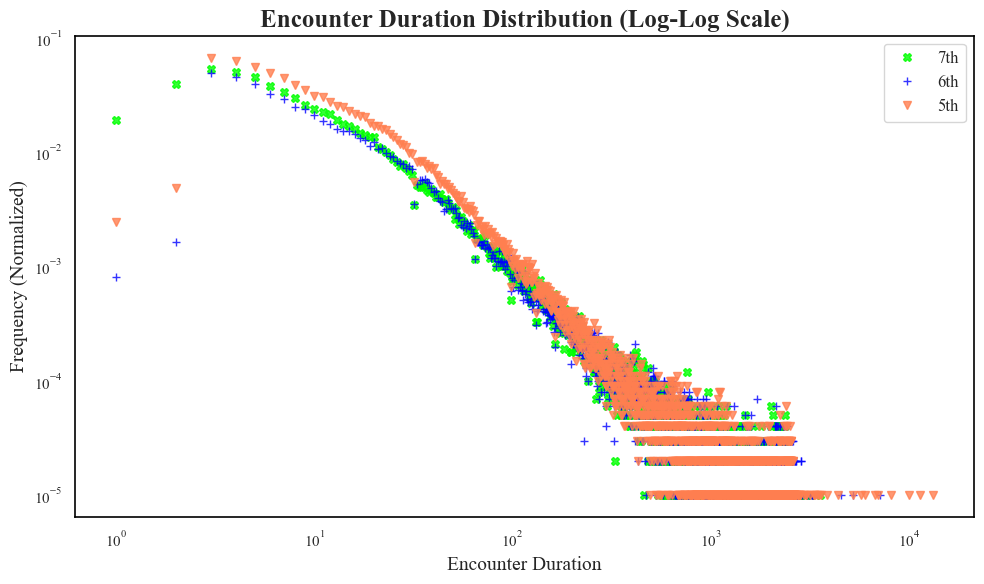

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup figure and font
plt.figure(figsize=(10, 6))
plt.rcParams["font.family"] = "Times New Roman"

# 2. Configuration for grades (Matching your style: Lime/X, Blue/+, Coral/v)
grades_config = [
    {'df': student_contacts7, 'label': '7th', 'color': 'lime', 'marker': 'X'},
    {'df': student_contacts6, 'label': '6th', 'color': 'blue', 'marker': '+'},
    {'df': student_contacts5, 'label': '5th', 'color': 'coral', 'marker': 'v'}
]

# 3. Calculate and Plot
for cfg in grades_config:
    # Efficiently calculate frequencies (counts) of each duration
    # value_counts() is O(N), much faster than the .count() list method
    counts = cfg['df']['duration'].value_counts().sort_index()
    
    # Extract x (duration) and y (frequency normalized by 100,000)
    x = counts.index
    y = counts.values / 100000
    
    # Log-Log plot
    plt.loglog(x, y, marker=cfg['marker'], linestyle='None', 
               color=cfg['color'], markersize=6, label=cfg['label'], alpha=0.8)

# 4. Styling (Formatting to match your specific layout)
plt.xlabel('Encounter Duration', fontsize=14, fontname='Times New Roman')
plt.ylabel('Frequency (Normalized)', fontsize=14, fontname='Times New Roman')
plt.title('Encounter Duration Distribution (Log-Log Scale)', fontsize=18, fontname='Times New Roman', fontweight='bold')

# Black border/spines
plt.gca().set_facecolor('white')
for spine in plt.gca().spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.legend(prop={'family': 'Times New Roman', 'size': 12})
plt.grid(False)
plt.tight_layout()

plt.savefig('figures/encounter_duration_powerlaw.png', dpi=300)
plt.show()


### Visualization of Stationary Sensor Interactions (5th, 6th, and 7th Grade)

This cell generates a consolidated 3x1 subplot visualization showing the temporal evolution of contact events for **stationary sensors** (e.g., Cafeteria, Main Door) across all grades.

* **Analysis Window**: Standardized school hours from 09:00 to 15:00 (TR Local Time).
* **Granularity**: Data is binned into **3-minute intervals**.
* **Methodology**: Uses high-performance vectorized mapping to identify stationary sensor contacts via the `tag_min` and `tag_max` columns.
* **Aesthetics**: Implements academic-style formatting using **Times New Roman** and standard black borders, with a unified time axis for direct inter-grade comparison.


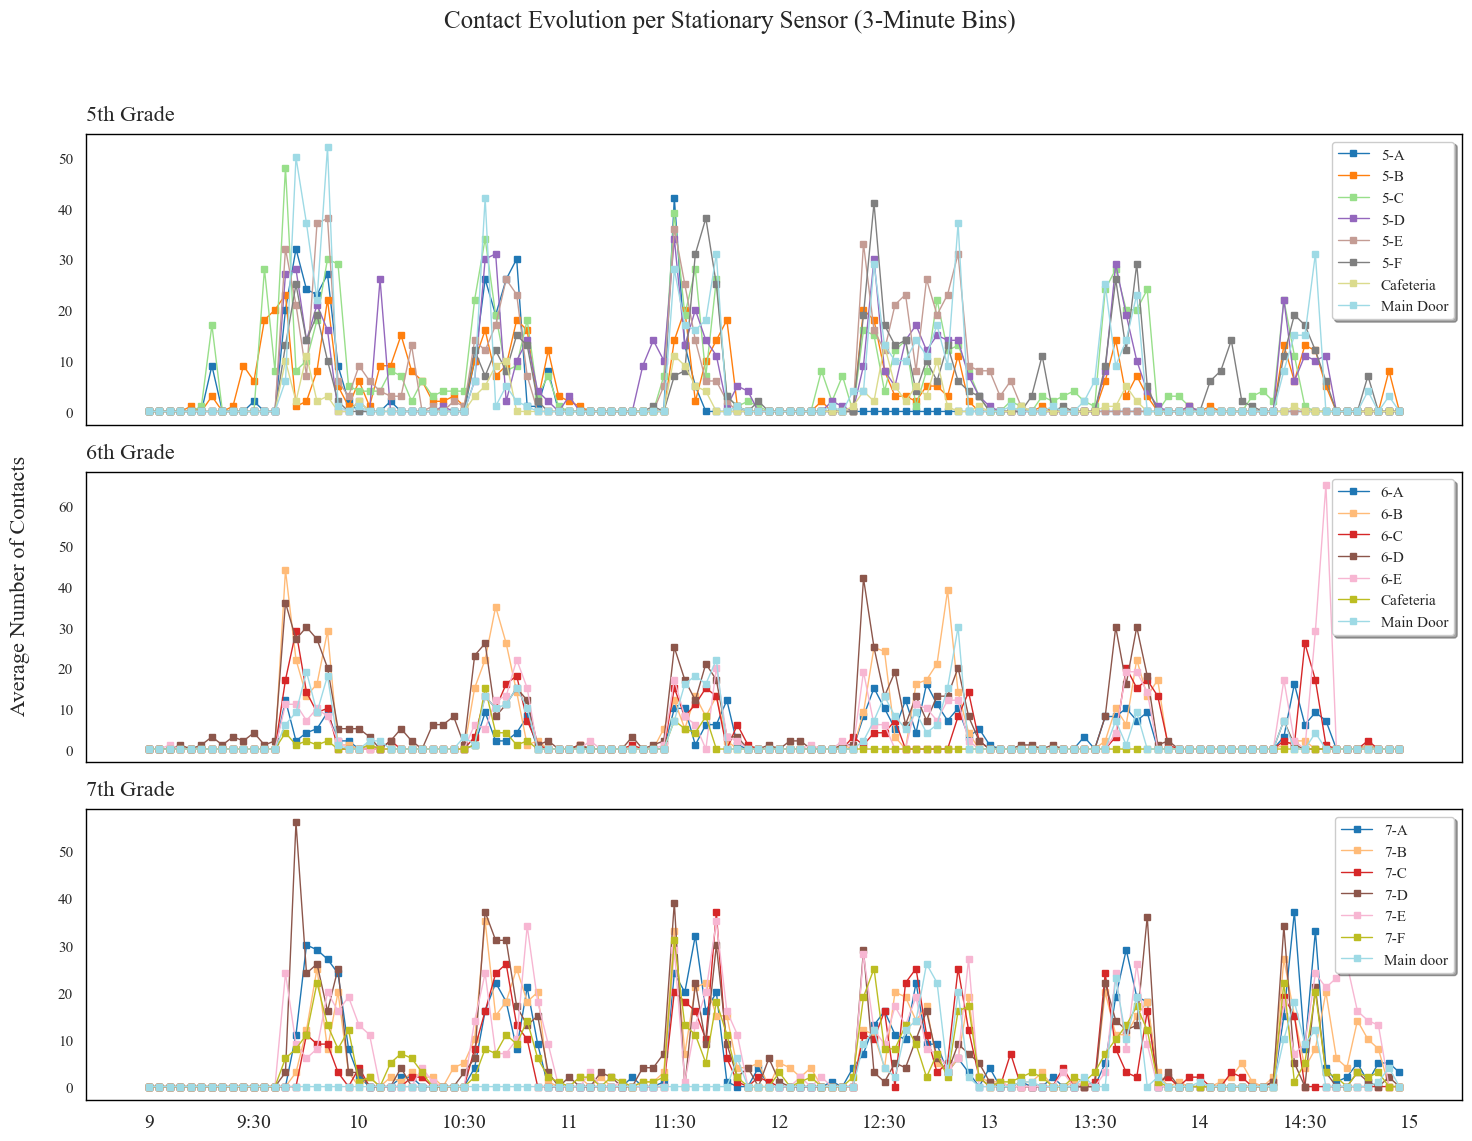

In [78]:
from utils import plot_stationary_contacts

# Create the figure and subplots
fig, axs = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

configs = [
    {'df': df5, 'class': df_class5, 'title': '5th Grade', 'date': "2023-03-22"},
    {'df': df6, 'class': df_class6, 'title': '6th Grade', 'date': "2023-03-20"},
    {'df': df7, 'class': df_class7, 'title': '7th Grade', 'date': "2023-03-15"}
]

for conf, ax in zip(configs, axs):
    t_start = georgian_to_unix(f"{conf['date']} 09:00:00")
    t_end   = georgian_to_unix(f"{conf['date']} 15:00:00")
    # Pass the axis 'ax'
    plot_stationary_contacts(conf['df'], conf['class'], t_start, t_end, conf['title'], ax=ax)

# --- Change the font size of the x-axis ticks (on the bottom subplot) ---
for label in axs[-1].get_xticklabels():
    label.set_fontsize(14)  # You can adjust this number to change the size
    label.set_fontname('Times New Roman')

# Setup overall labels
fig.text(0.02, 0.5, 'Average Number of Contacts', va='center', rotation='vertical', 
         fontsize=16, fontname='Times New Roman')
plt.suptitle('Contact Evolution per Stationary Sensor (3-Minute Bins)', 
             fontsize=18, fontname='Times New Roman', y=0.98)

plt.tight_layout(rect=[0.04, 0.03, 1, 0.95])

# IMPORTANT: Save using the fig object to ensure the whole thing is captured
fig.savefig('figures/stationary_contacts_unified.png', dpi=300, bbox_inches='tight')

plt.show()


### Comparative Average Degree (Connectivity) per Person

This cell compares the **Global Average Degree** across all three grades on a single timeline. The average degree represents the mean number of unique contacts a student has during each 3-minute interval.

* **Objective**: Identify social interaction density and peak contact periods (recess, lunch, etc.) across different grade levels simultaneously.
* **Efficiency**: Utilizes the optimized [get_avg_degree](cci:1://file:///Users/tanyaniazi/Desktop/codes/utils.py:177:0-190:76) utility, which leverages pandas grouping for high-speed calculation of total contacts vs. unique participant counts per bin.
* **Aesthetics**: Differentiates grades by color (7th: Red, 6th: Blue, 5th: Yellow) with a clean, publication-ready design (Times New Roman, no grid lines).


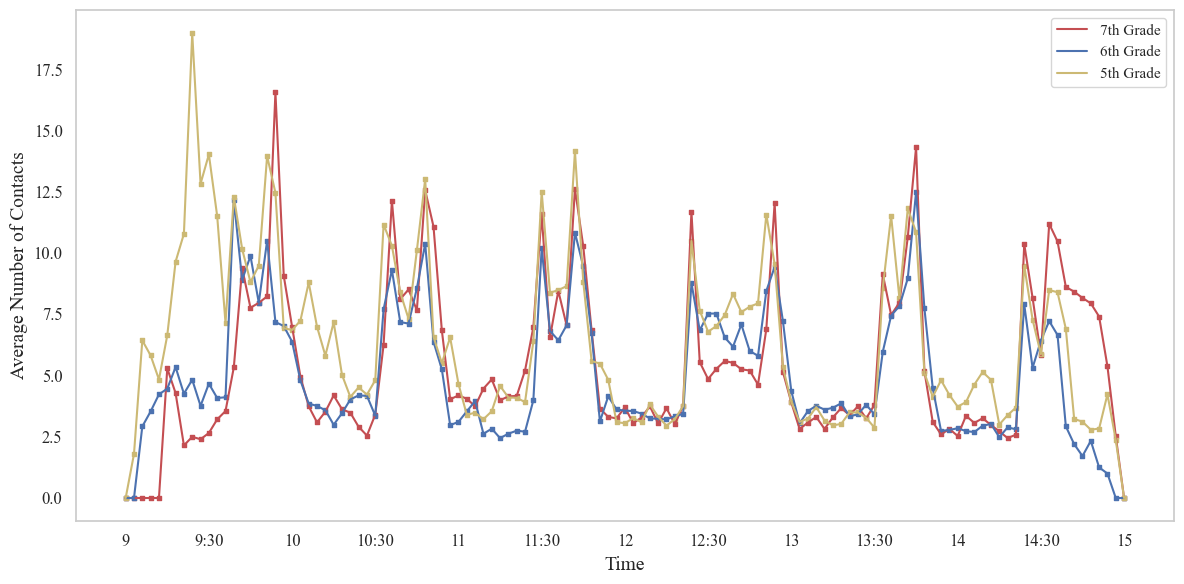

In [79]:
import matplotlib.pyplot as plt
from utils import get_avg_degree

# 1. Define configurations for all grades
grade_configs = [
    {'df': df7, 'name': '7th Grade', 'color': 'r', 'date': "2023-03-15"},
    {'df': df6, 'name': '6th Grade', 'color': 'b', 'date': "2023-03-20"},
    {'df': df5, 'name': '5th Grade', 'color': 'y', 'date': "2023-03-22"}
]

plt.figure(figsize=(12, 6))

for conf in grade_configs:
    # Use our optimized timezone-aware helper for the window
    t_start = georgian_to_unix(f"{conf['date']} 09:00:00")
    t_end   = georgian_to_unix(f"{conf['date']} 15:00:00")
    
    # Calculate average degree instantly using the new utils function
    y_values = get_avg_degree(conf['df'], t_start, t_end)
    x_values = range(len(y_values))
    
    # Plotting
    plt.plot(x_values, y_values, label=conf['name'], color=conf['color'], linewidth=1.5)
    plt.scatter(x_values, y_values, color=conf['color'], marker='s', s=8)

# 2. Optimized Styling (Times New Roman & Clean Borders)
# plt.title('Average Degree per Person Every 3 Minutes', fontsize=18, fontname='Times New Roman', pad=20)
plt.xlabel('Time', fontsize=14, fontname='Times New Roman')
plt.ylabel('Average Number of Contacts', fontsize=14, fontname='Times New Roman')

# 3. Time Ticks (9:00 to 15:00)
tick_pos = range(0, 121, 10)
tick_labels = ['9', '9:30', '10', '10:30', '11', '11:30', '12', '12:30', '13', '13:30', '14', '14:30', '15']
plt.xticks(tick_pos, tick_labels, fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)

# 4. Final Polish
plt.legend(fontsize=11, prop={'family': 'Times New Roman'}, frameon=True)
plt.grid(False) # Clean research look as requested
plt.tight_layout()

# Save locally
plt.savefig('figures/average_degree_altogether.png', dpi=300, bbox_inches='tight')
plt.show()


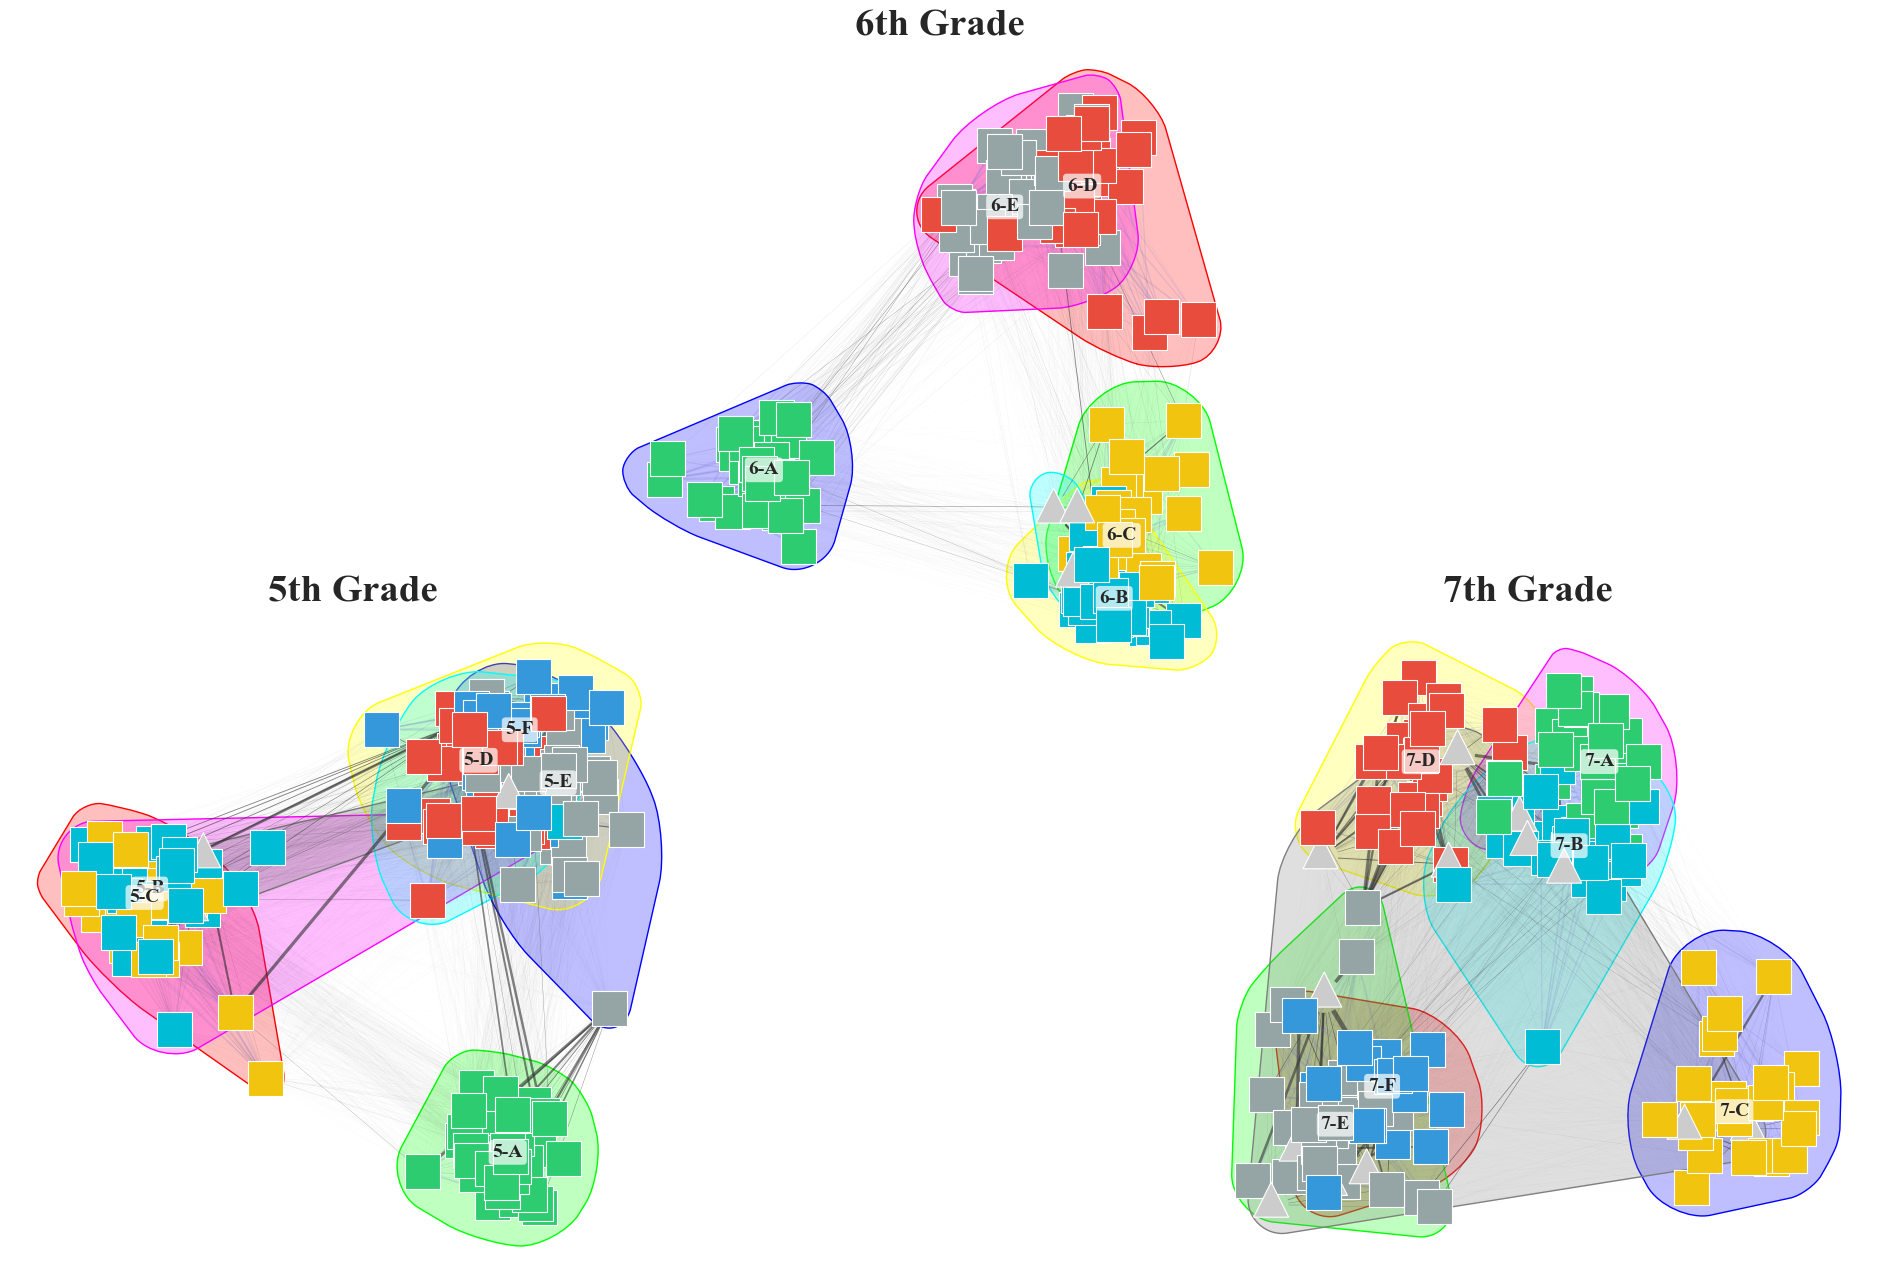

In [80]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from utils import build_visual_style

# 1. GRAPHS CONFIGURATION (Using baseline all-students networks, including unspecified classes)
GRAPHS_CONFIG = [
    {'g_orig': g5_baseline_all, 'ax_name': '5th_grade', 'label': '5th Grade'},
    {'g_orig': g6_baseline_all, 'ax_name': '6th_grade', 'label': '6th Grade'},
    {'g_orig': g7_baseline_all, 'ax_name': '7th_grade', 'label': '7th Grade'},
]

# 2. COLOR MAP
CLASS_COLORS = {
    '5-A': '#2ecc71', '5-B': '#00bcd4', '5-C': '#f1c40f', '5-D': '#e74c3c', '5-E': '#95a5a6', '5-F': '#3498db',
    '6-A': '#2ecc71', '6-B': '#00bcd4', '6-C': '#f1c40f', '6-D': '#e74c3c', '6-E': '#95a5a6', '6-F': '#3498db',
    '7-A': '#2ecc71', '7-B': '#00bcd4', '7-C': '#f1c40f', '7-D': '#e74c3c', '7-E': '#95a5a6', '7-F': '#3498db',
    'unknown': '#cccccc',
}

# -----------------------------------------------------------------------------
# 3. CREATE FIGURE & GRIDSPEC LAYOUT (Spaced columns 0:2, 2:4, 4:6)
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(2, 6)

ax5 = fig.add_subplot(gs[1, 0:2])  # Bottom-Left
ax6 = fig.add_subplot(gs[0, 2:4])  # Top-Center
ax7 = fig.add_subplot(gs[1, 4:6])  # Bottom-Right

axes_map = {
    '5th_grade': ax5,
    '6th_grade': ax6,
    '7th_grade': ax7
}

# -----------------------------------------------------------------------------
# 4. DRAWING LOOP (MDS Layout version with cell 216 settings)
# -----------------------------------------------------------------------------
for config in GRAPHS_CONFIG:
    g = config['g_orig'].copy()
    ax = axes_map[config['ax_name']]
    
    # CLEANUP: Remove non-students with unknown classes (keeps students with unknown classes)
    to_remove = [v.index for v in g.vs if v['class'] == 'unknown' and v['name'] != 'Student']
    g.delete_vertices(to_remove)
    
    # CENTER: Extract Giant Component
    if g.vcount() > 0:
        g = g.connected_components().giant()
    
    if g.vcount() == 0:
        ax.axis('off')
        continue
    
    # SETUP STYLE via utils.py
    visual_style = build_visual_style(g, CLASS_COLORS)
    
    # ── OVERRIDE LAYOUT TO CLASSICAL MDS ─────────────────────────────────────
    layout = g.layout('mds')
    visual_style['layout'] = layout
    
    # ── NODE SHAPES: Squares (known class) vs Triangles (unknown class) ──────
    visual_style['vertex_shape'] = [
        'triangle' if c == 'unknown' else 'square' for c in g.vs['class']
    ]
    
    # ── OVERRIDE SIZES FOR HIGH-RESOLUTION CANVAS (vertex_size=35) ───────────
    visual_style['vertex_size'] = 35            # Set larger node size
    visual_style['vertex_frame_width'] = 0.8    # Thicker white border around nodes
    visual_style['edge_width'] = [w * 2.5 for w in visual_style['edge_width']]  # Thicker edges
    
    clustering = ig.VertexClustering.FromAttribute(g, 'class')

    # DRAWING
    ig.plot(clustering, target=ax, mark_groups=True, **visual_style)

    # ANNOTATION: Labels at cluster centers (using MDS coordinates)
    all_classes = np.array(g.vs['class'])
    unique_classes = sorted(set(all_classes))
    
    for cls in unique_classes:
        if cls == 'unknown': continue
        indices = [i for i, c in enumerate(all_classes) if c == cls]
        coords = np.array([layout[i] for i in indices])
        center_x, center_y = np.median(coords, axis=0)
        
        ax.text(center_x, center_y, cls, 
                fontsize=14, fontname='Times New Roman', fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    # Title for each individual subplot (Grade label) - pad=0 to prevent overlap
    ax.set_title(config['label'], fontsize=28, fontweight='bold', fontfamily='Times New Roman', pad=0)
    
    # Turn off axes borders
    ax.axis('off')

# Adjust layout spacing to leave space horizontally and vertically
fig.subplots_adjust(hspace=-0.15, wspace=-0.25)

filename = "figures/all_grades_network_unified_mds.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


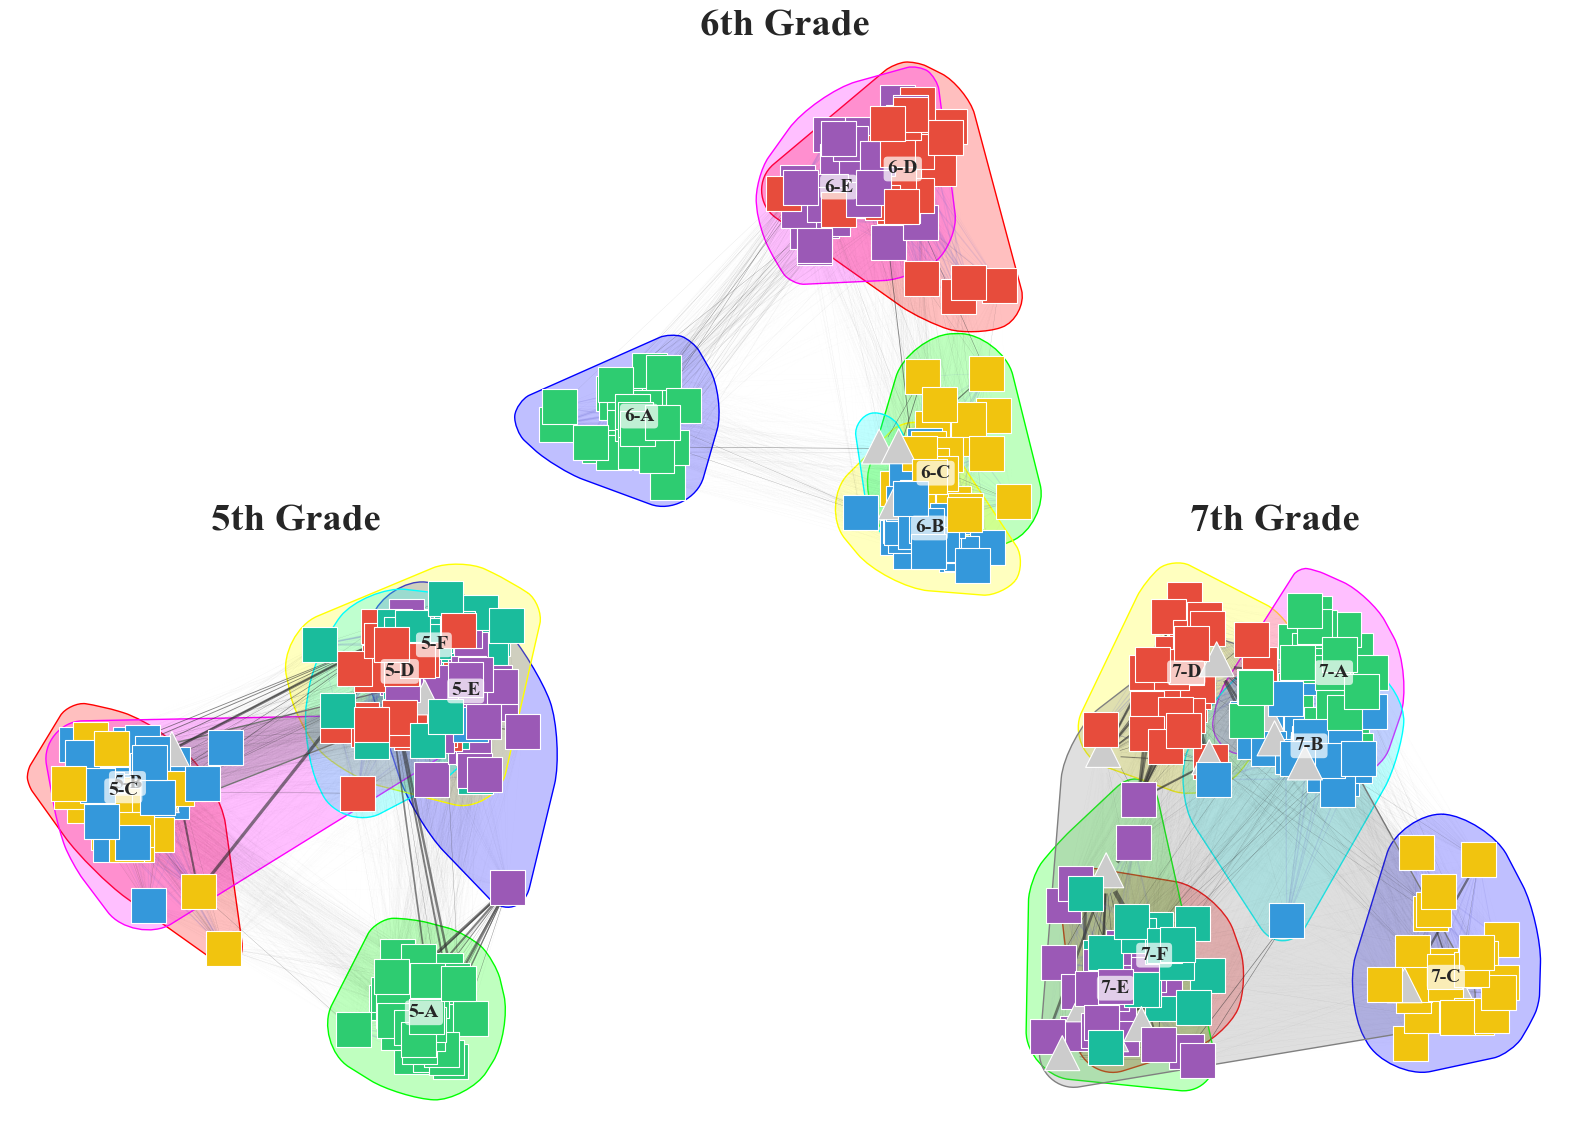

In [81]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from utils import build_visual_style

# 1. GRAPHS CONFIGURATION (Using baseline all-students networks, including unspecified classes)
GRAPHS_CONFIG = [
    {'g_orig': g5_baseline_all, 'ax_name': '5th_grade', 'label': '5th Grade'},
    {'g_orig': g6_baseline_all, 'ax_name': '6th_grade', 'label': '6th Grade'},
    {'g_orig': g7_baseline_all, 'ax_name': '7th_grade', 'label': '7th Grade'},
]

# -----------------------------------------------------------------------------
# 2. CREATE FIGURE & GRIDSPEC LAYOUT (Spaced columns 0:2, 2:4, 4:6)
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 6)

ax5 = fig.add_subplot(gs[1, 0:2])  # Bottom-Left
ax6 = fig.add_subplot(gs[0, 2:4])  # Top-Center
ax7 = fig.add_subplot(gs[1, 4:6])  # Bottom-Right

axes_map = {
    '5th_grade': ax5,
    '6th_grade': ax6,
    '7th_grade': ax7
}

# Beautiful vibrant colors (excluding grays)
PALETTE = ['#2ecc71', '#3498db', '#f1c40f', '#e74c3c', '#9b59b6', '#1abc9c', '#e67e22', '#e84393', '#00cec9']

# -----------------------------------------------------------------------------
# 3. DRAWING LOOP (MDS Layout with Dynamic Color Mapping)
# -----------------------------------------------------------------------------
for config in GRAPHS_CONFIG:
    g = config['g_orig'].copy()
    ax = axes_map[config['ax_name']]
    
    # CLEANUP: Remove non-students with unknown classes (keeps students with unknown classes)
    to_remove = [v.index for v in g.vs if v['class'] == 'unknown' and v['name'] != 'Student']
    g.delete_vertices(to_remove)
    
    # CENTER: Extract Giant Component
    if g.vcount() > 0:
        g = g.connected_components().giant()
    
    if g.vcount() == 0:
        ax.axis('off')
        continue
    
    # SETUP STYLE via utils.py (a dummy dictionary is passed since we override colors next)
    visual_style = build_visual_style(g, {})
    
    # ── DYNAMIC COLOR MAP OVERRIDE (Only 'unknown' is gray) ──────────────────
    unique_known_classes = sorted(list(set([v['class'] for v in g.vs if v['class'] != 'unknown'])))
    dynamic_color_map = {cls: PALETTE[i % len(PALETTE)] for i, cls in enumerate(unique_known_classes)}
    dynamic_color_map['unknown'] = '#cccccc'  # Gray is strictly reserved for unknown classes
    
    # Set the vertex colors directly
    visual_style['vertex_color'] = [dynamic_color_map.get(c, '#cccccc') for c in g.vs['class']]
    
    # ── OVERRIDE LAYOUT TO CLASSICAL MDS ─────────────────────────────────────
    layout = g.layout('mds')
    visual_style['layout'] = layout
    
    # ── NODE SHAPES: Squares (known class) vs Triangles (unknown class) ──────
    visual_style['vertex_shape'] = [
        'triangle' if c == 'unknown' else 'square' for c in g.vs['class']
    ]
    
    # ── OVERRIDE SIZES FOR HIGH-RESOLUTION CANVAS (vertex_size=35) ───────────
    visual_style['vertex_size'] = 35            
    visual_style['vertex_frame_width'] = 0.8    
    visual_style['edge_width'] = [w * 2.5 for w in visual_style['edge_width']]  
    
    clustering = ig.VertexClustering.FromAttribute(g, 'class')

    # DRAWING
    ig.plot(clustering, target=ax, mark_groups=True, **visual_style)

    # ANNOTATION: Labels at cluster centers (using MDS coordinates)
    all_classes = np.array(g.vs['class'])
    unique_classes = sorted(set(all_classes))
    
    for cls in unique_classes:
        if cls == 'unknown': continue
        indices = [i for i, c in enumerate(all_classes) if c == cls]
        coords = np.array([layout[i] for i in indices])
        center_x, center_y = np.median(coords, axis=0)
        
        ax.text(center_x, center_y, cls, 
                fontsize=14, fontname='Times New Roman', fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    # Title for each individual subplot (Grade label) - pad=0 to prevent overlap
    ax.set_title(config['label'], fontsize=28, fontweight='bold', fontfamily='Times New Roman', pad=0)
    
    # Turn off axes borders
    ax.axis('off')

# Adjust layout spacing to leave space horizontally and vertically
fig.subplots_adjust(hspace=-0.15, wspace=-0.25)

filename = "figures/all_grades_network_unified_mds.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


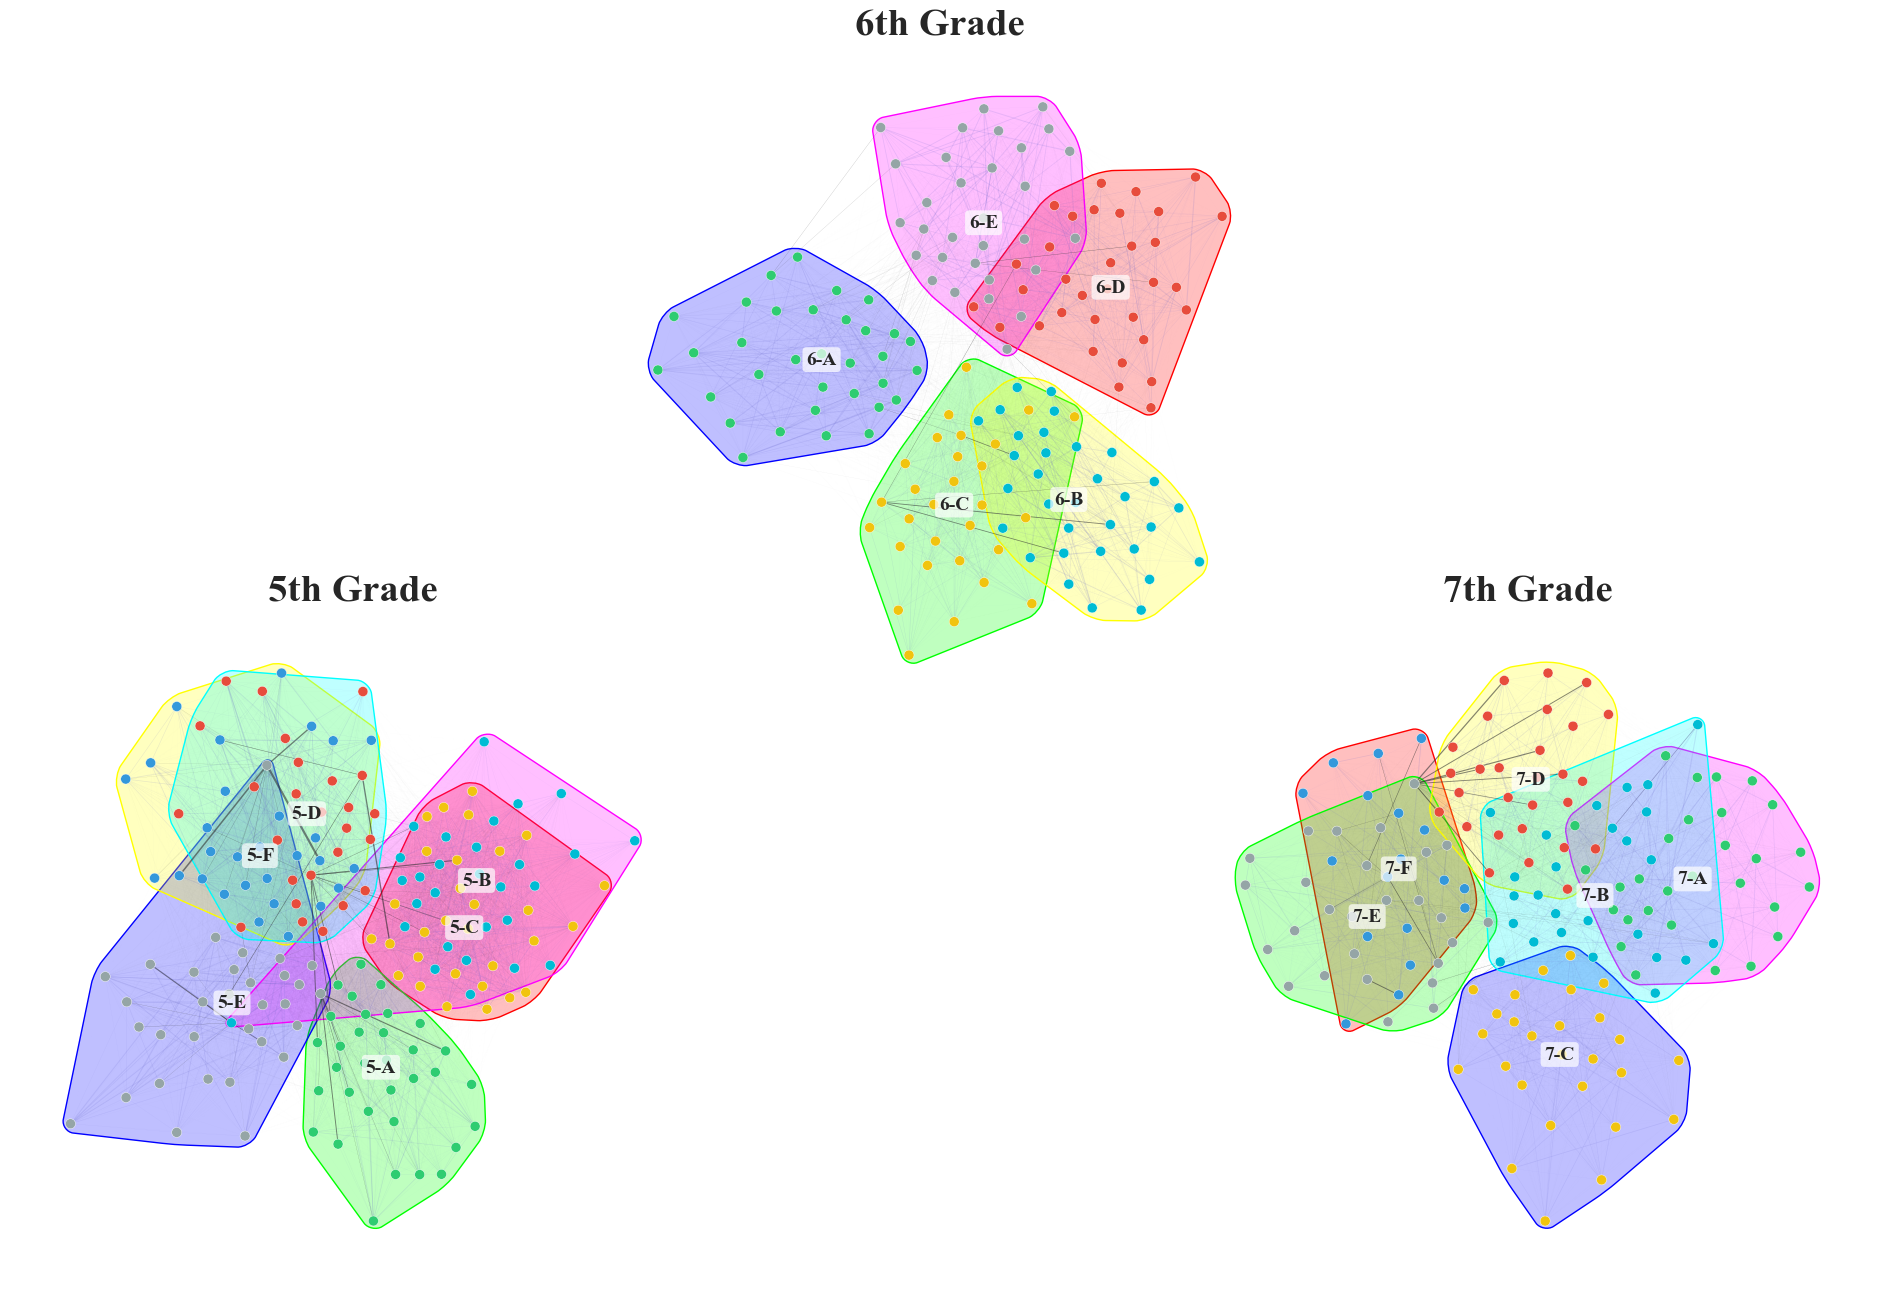

In [82]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from utils import build_visual_style

# 1. GRAPHS CONFIGURATION (with labels for individual grade titles)
GRAPHS_CONFIG = [
    {'g_orig': known_net5, 'ax_name': '5th_grade', 'label': '5th Grade'},
    {'g_orig': known_net6, 'ax_name': '6th_grade', 'label': '6th Grade'},
    {'g_orig': known_net7, 'ax_name': '7th_grade', 'label': '7th Grade'},
]

# 2. COLOR MAP
CLASS_COLORS = {
    '5-A': '#2ecc71', '5-B': '#00bcd4', '5-C': '#f1c40f', '5-D': '#e74c3c', '5-E': '#95a5a6', '5-F': '#3498db',
    '6-A': '#2ecc71', '6-B': '#00bcd4', '6-C': '#f1c40f', '6-D': '#e74c3c', '6-E': '#95a5a6', '6-F': '#3498db',
    '7-A': '#2ecc71', '7-B': '#00bcd4', '7-C': '#f1c40f', '7-D': '#e74c3c', '7-E': '#95a5a6', '7-F': '#3498db',
    'unknown': '#cccccc',
}

# -----------------------------------------------------------------------------
# 3. CREATE FIGURE & GRIDSPEC LAYOUT
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(2, 6)

# Position subplots: 6th grade on top (center), 5th and 7th at the bottom (sides)
ax5 = fig.add_subplot(gs[1, 0:2])  # Bottom-Left
ax6 = fig.add_subplot(gs[0, 2:4])  # Top-Center
ax7 = fig.add_subplot(gs[1, 4:6])  # Bottom-Right

axes_map = {
    '5th_grade': ax5,
    '6th_grade': ax6,
    '7th_grade': ax7
}

# -----------------------------------------------------------------------------
# 4. DRAWING LOOP
# -----------------------------------------------------------------------------
for config in GRAPHS_CONFIG:
    g = config['g_orig'].copy()
    ax = axes_map[config['ax_name']]
    
    # CLEANUP: Remove non-students with unknown classes
    to_remove = [v.index for v in g.vs if v['class'] == 'unknown' and v['name'] != 'Student']
    g.delete_vertices(to_remove)
    
    # CENTER: Extract Giant Component
    if g.vcount() > 0:
        g = g.connected_components().giant()
    
    if g.vcount() == 0:
        ax.axis('off')
        continue
    
    # SETUP STYLE via utils.py
    visual_style = build_visual_style(g, CLASS_COLORS)
    clustering = ig.VertexClustering.FromAttribute(g, 'class')
    layout = visual_style['layout']

    # DRAWING
    ig.plot(clustering, target=ax, mark_groups=True, **visual_style)

    # ANNOTATION: Labels at cluster centers
    all_classes = np.array(g.vs['class'])
    unique_classes = sorted(set(all_classes))
    
    for cls in unique_classes:
        if cls == 'unknown': continue
        indices = [i for i, c in enumerate(all_classes) if c == cls]
        coords = np.array([layout[i] for i in indices])
        center_x, center_y = np.median(coords, axis=0)
        
        ax.text(center_x, center_y, cls, 
                fontsize=14, fontname='Times New Roman', fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    # Title for each individual subplot (Grade label)
    ax.set_title(config['label'], fontsize=28, fontweight='bold', fontfamily='Times New Roman', pad=10)
    
    # Turn off axes borders
    ax.axis('off')

# Adjust layout spacing to bring the subplots closer together
fig.subplots_adjust(hspace=-0.15, wspace=-0.25)

filename = "figures/all_grades_network_unified.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


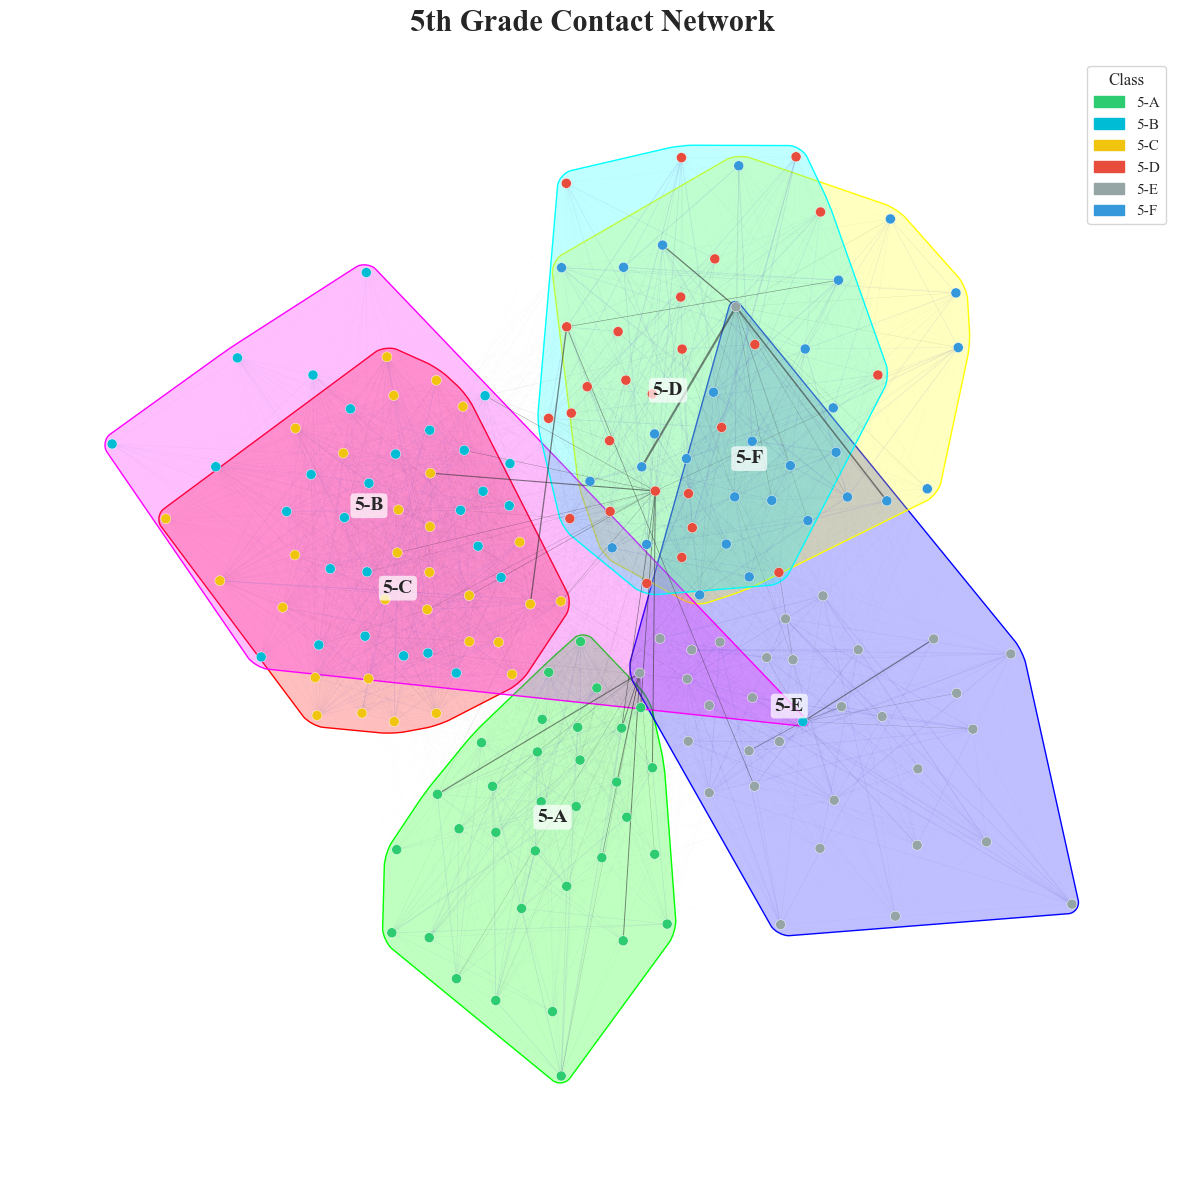

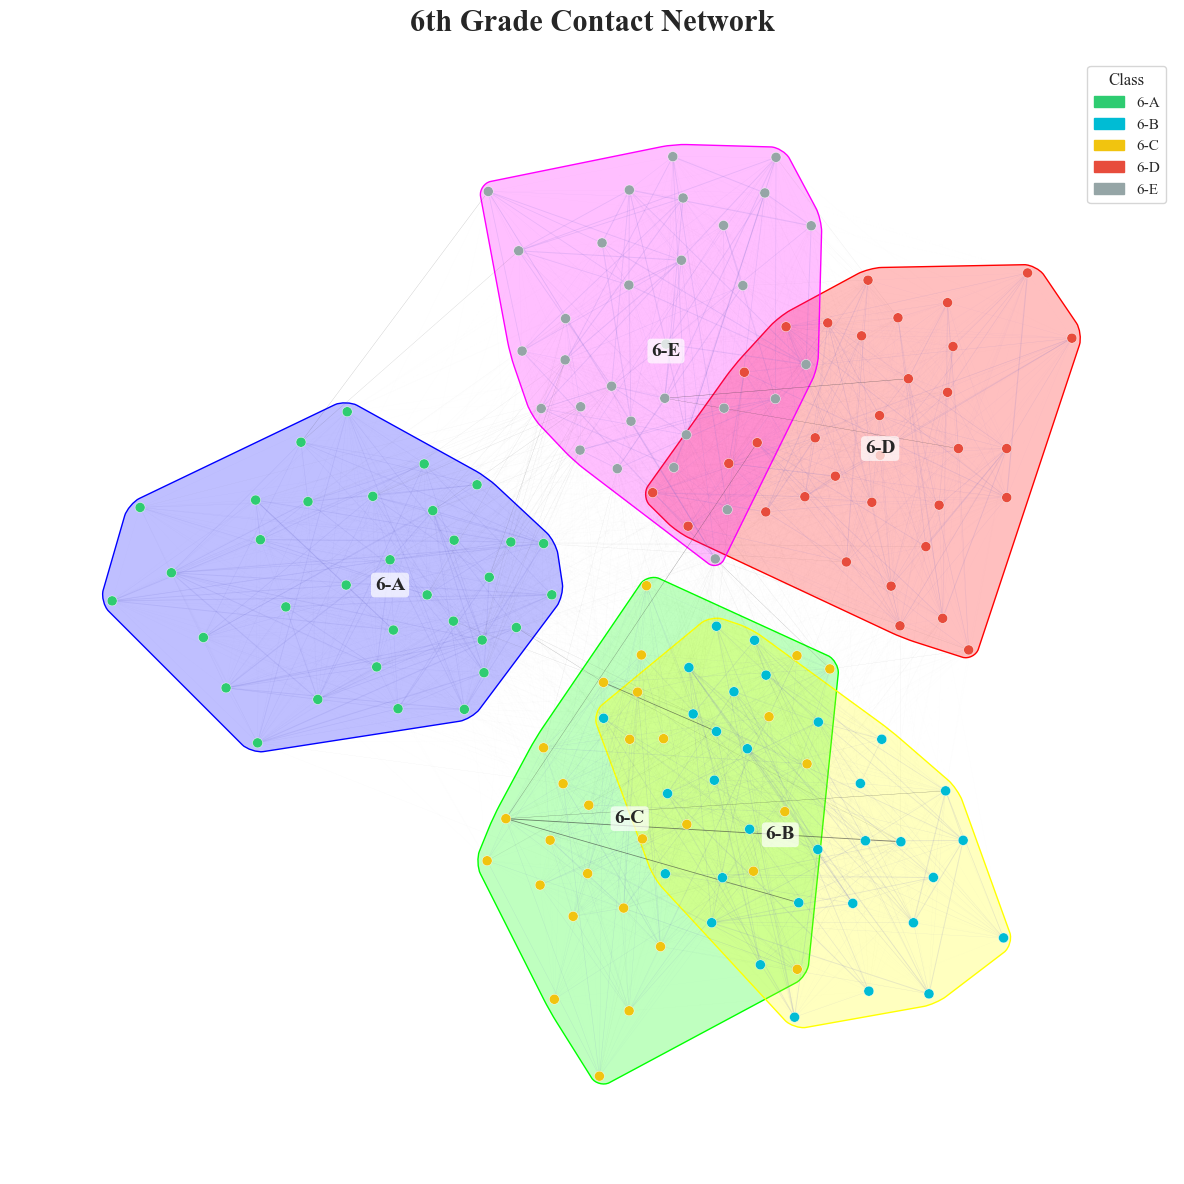

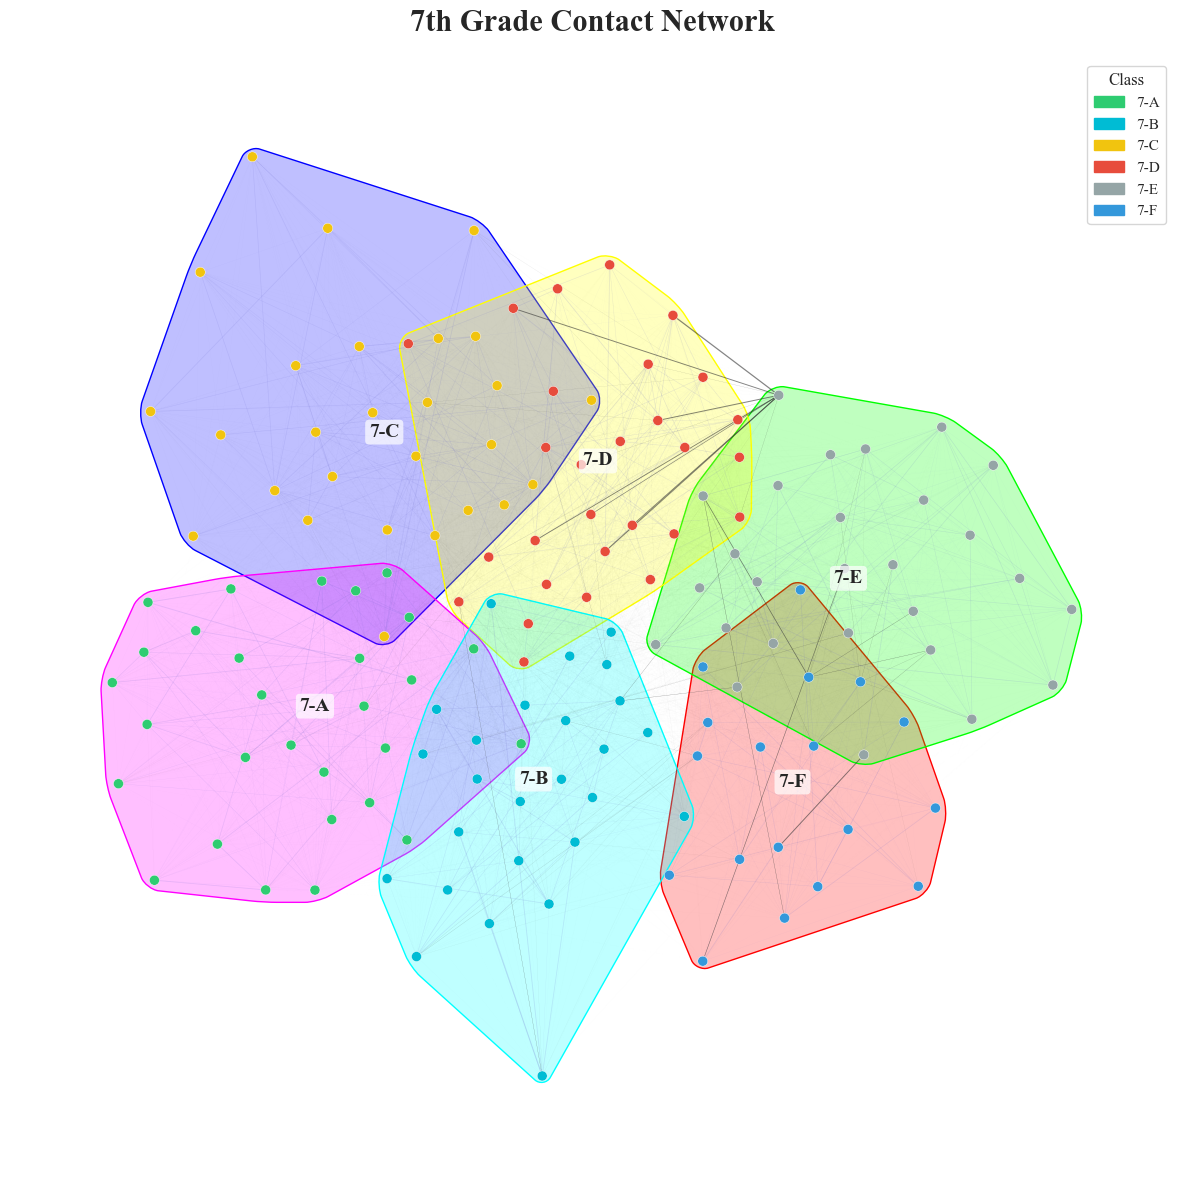

In [83]:
# 1. IMPORTS
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
from utils import build_visual_style, make_legend_patches

# 2. DEFINE YOUR DATA (Make sure known_net5, 6, and 7 are already created)
GRAPHS = [
    (known_net5, '5th Grade'),
    (known_net6, '6th Grade'),
    (known_net7, '7th Grade'),
]

# 3. DEFINE COLOR MAP
CLASS_COLORS = {
    '5-A': '#2ecc71', '5-B': '#00bcd4', '5-C': '#f1c40f', '5-D': '#e74c3c', '5-E': '#95a5a6', '5-F': '#3498db',
    '6-A': '#2ecc71', '6-B': '#00bcd4', '6-C': '#f1c40f', '6-D': '#e74c3c', '6-E': '#95a5a6', '6-F': '#3498db',
    '7-A': '#2ecc71', '7-B': '#00bcd4', '7-C': '#f1c40f', '7-D': '#e74c3c', '7-E': '#95a5a6', '7-F': '#3498db',
    'unknown': '#cccccc',
}

# -----------------------------------------------------------------------------
# 4. PLOTTING LOOP
# -----------------------------------------------------------------------------

for g_orig, title in GRAPHS:
    # Work on a copy to keep original net intact
    g = g_orig.copy()
    
    # CLEANUP: Remove non-students with unknown classes
    to_remove = [v.index for v in g.vs if v['class'] == 'unknown' and v['name'] != 'Student']
    g.delete_vertices(to_remove)
    
    # CENTER: Extract Giant Component
    if g.vcount() > 0:
        g = g.connected_components().giant()
    
    if g.vcount() == 0: continue
    
    # SETUP STYLE via utils.py
    visual_style = build_visual_style(g, CLASS_COLORS)
    clustering = ig.VertexClustering.FromAttribute(g, 'class')
    layout = visual_style['layout']

    # DRAWING
    fig, ax = plt.subplots(figsize=(12, 12))
    ig.plot(clustering, target=ax, mark_groups=True, **visual_style)

    # ANNOTATION: Labels at cluster centers
    all_classes = np.array(g.vs['class'])
    unique_classes = sorted(set(all_classes))
    
    for cls in unique_classes:
        if cls == 'unknown': continue
        indices = [i for i, c in enumerate(all_classes) if c == cls]
        coords = np.array([layout[i] for i in indices])
        center_x, center_y = np.median(coords, axis=0)
        
        ax.text(center_x, center_y, cls, 
                fontsize=14, fontname='Times New Roman', fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    # FINAL POLISH
    ax.legend(handles=make_legend_patches(g, CLASS_COLORS), 
              title='Class', loc='upper right', prop={'family': 'Times New Roman'})
    ax.set_title(f"{title} Contact Network", fontsize=22, fontweight='bold', fontfamily='Times New Roman', pad=20)
    ax.axis('off')

    plt.tight_layout()
    filename = f"figures/network_{title.lower().replace(' ', '_')}.png"
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
